# 🎓 Transformer Crypto — v5 (Reproductible + Multi-Run)

**PFE : Prédiction Multi-Horizon des Marchés Crypto avec Transformer + ATA**

Master IAA — Université Ibn Zohr Faculté Polydisciplinaire de Ouarzazate

---

### Changements v5 vs v4 :

| Problème v4 | Solution v5 |
|------------|-------------|
| Résultats non reproductibles (variance 4%+) | Seeds fixés + mode déterministe |
| 1 seul run par expérience | 5 runs × 4 attentions = comparaison statistique |
| Modèle trop gros (120K params / 7K samples) | Modèle réduit (d_model=32, 4 couches) |

> Ce notebook produit un tableau de résultats **scientifiquement valide** avec moyenne ± écart-type.

## 1. Configuration + GPU

In [43]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════
# FIXER TOUS LES SEEDS — Reproductibilité
# ══════════════════════════════════════════════════
# Sans ça, chaque run donne des résultats différents
# et on ne peut rien conclure scientifiquement.

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"✅ GPU : {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")
else:
    DEVICE = "cpu"
    print("⚠️  CPU uniquement")

print(f"   PyTorch : {torch.__version__}")
print(f"   🔒 Seeds fixés — résultats reproductibles")

✅ GPU : Tesla T4 (15.6 GB)
   PyTorch : 2.10.0+cu128
   🔒 Seeds fixés — résultats reproductibles


## 2. Paramètres

> Les changements vs v2 sont marqués avec `# ← CHANGÉ`

In [44]:
# ══════════════════════════════════════════════════
# PARAMÈTRES v5 — Reproductible + Multi-Run
# ══════════════════════════════════════════════════

# ── Données ──
SYMBOL = "BTCUSDT"
INTERVAL = "1h"
START_DATE = "2020-01-01"
USE_KAGGLE_CSV = True
KAGGLE_CSV_PATH = "/kaggle/input/datasets/atlasinfos/btcusdt-1h-15/BTCUSDT_1h (15).csv"

# ── Données On-Chain ──
# ── Données On-Chain + Sentiment ──
# 3 modes pour comparer l'impact de la FRÉQUENCE :
#   "none"   = pas de données on-chain (baseline 54 features)
#   "daily"  = Fear & Greed + Hashrate journaliers forward-fillés (+6 features)
#   "hourly" = Proxys horaires dérivés de l'OHLCV (+11 features)
#              Simule ce que donneraient des APIs payantes horaires
ONCHAIN_MODE = "hourly"      # ← CHANGE ICI : "none", "daily", "hourly"
USE_ONCHAIN = (ONCHAIN_MODE == "daily")  # Collecte externe seulement si daily

# ── Labélisation ──
# 4 modes de labélisation pour comparer :
#   "threshold"  = seuil simple ±0.3% (baseline actuelle)
#   "triple"     = Triple Barrier Method (Lopez de Prado, 2018)
#   "zigzag"     = ZigZag Indicator (pivots du marché)
#   "expert"     = Expert Advisor multi-indicateurs (style MQL5)
# TREND INDICATOR MODES (nouveau — recommandé par Mr. Jaafari) :
#   "adx"        = ADX (Average Directional Index, Wilder 1978)
#   "supertrend" = Supertrend (ATR-based)
#   "ichimoku"   = Ichimoku Cloud (Hosoda 1969)
#   "sar"        = Parabolic SAR (Wilder 1978)
#   "consensus"  = Vote des 4 indicateurs de trend
LABEL_MODE = "adx"           # ← CHANGE ICI pour comparer

# Paramètres Trend Indicators
ADX_PERIOD = 14              # adx : période de calcul
ADX_THRESHOLD = 25           # adx : seuil de force du trend
ST_PERIOD = 10               # supertrend : période ATR
ST_MULTIPLIER = 3.0          # supertrend : multiplicateur
ICH_TENKAN = 9               # ichimoku : période Tenkan-sen
ICH_KIJUN = 26               # ichimoku : période Kijun-sen
ICH_SENKOU = 52              # ichimoku : période Senkou B
SAR_AF_START = 0.02          # sar : acceleration factor initial
SAR_AF_MAX = 0.20            # sar : acceleration factor maximum
CONSENSUS_MIN = 3            # consensus : votes minimum

# Paramètres par mode
HORIZON = 12                 # Commun : horizon de prédiction (12 bougies)

# ══════════════════════════════════════════════════
# MULTI-HORIZON MODE — Vrai multi-horizon H+1..H+12
# ══════════════════════════════════════════════════
# Si True  : le modèle sort 12 prédictions en UNE passe (une par horizon h=1..12)
# Si False : mode single-horizon classique
MULTI_HORIZON = True
N_HORIZONS = HORIZON      # Nombre d'horizons à prédire (1 à HORIZON)

# ══════════════════════════════════════════════════
# MODULE ATA — Adaptive Temporal Attention
# ══════════════════════════════════════════════════
# Si True  : active le module ATA (contribution originale du PFE)
#            Ajoute un embedding d'horizon appris qui conditionne
#            dynamiquement les queries du self-attention
# Si False : Transformer sans ATA (baseline pour ablation study)
USE_ATA = True

# ══════════════════════════════════════════════════
# FONCTION DE PERTE MULTI-HORIZON
# ══════════════════════════════════════════════════
# "uniform"    : toutes les horizons pondérées également (1/H)
# "decay"      : poids décroissant avec l'horizon (H+1 plus important)
# "increasing" : poids croissant (H+12 plus important, pour focus long-terme)
LOSS_WEIGHTING = "uniform"  # uniform | decay | increasing

# ══════════════════════════════════════════════════
# TEST STATISTIQUE DIEBOLD-MARIANO
# ══════════════════════════════════════════════════
# Si True : calcule le test DM entre les 4 mécanismes d'attention
#           pour prouver la significativité statistique des différences
RUN_DM_TEST = True

THRESHOLD = 0.3              # threshold : seuil ±%
TB_K = 1.5                   # triple : multiplicateur de volatilité
TB_VOL_WINDOW = 20           # triple : fenêtre de calcul de σ
ZZ_THRESHOLD = 1.5           # zigzag : seuil minimum de mouvement (%)
ZZ_TRANSITION = 3            # zigzag : bougies de transition → NEUTRE
EA_CONSENSUS = 3             # expert : votes minimum pour un signal

# ── Transformer v5 (réduit pour 7K samples) ──
LOOKBACK = 30           # Tester aussi : 24, 48, 72

# ═══ PATCHING (PatchTST-style) ═══
USE_PATCHING = False        # True = PatchTST (regroupe les bougies), False = standard
PATCH_SIZE = 4             # Nombre de bougies par patch (4 = 4h de contexte par token)
PATCH_STRIDE = 4           # Stride entre patches (= PATCH_SIZE pour non-overlap)
# Séquence effective : LOOKBACK / PATCH_SIZE = nombre de tokens
# Ex: LOOKBACK=48, PATCH_SIZE=4 → 12 tokens au lieu de 48                # ← 30 au lieu de 60 (moins de params dans le modèle)
D_MODEL = 32                 # ← 32 au lieu de 48 (réduit pour éviter overfitting)
N_HEADS = 4                  # 32 / 4 = 8 dims par tête
N_LAYERS = 4                 # ← 4 au lieu de 6 (réduit)
DROPOUT = 0.3                # ← 0.3 au lieu de 0.25 (plus fort)
DIM_FF_MULT = 2

# ── Entraînement ──
BATCH_SIZE = 128
LEARNING_RATE = 0.0005
USE_MULTI_TF = True        # Multi-timeframes (15min + H1 + H4)
USE_ENSEMBLE = False         # Ensemble de modèles (vote pondéré)

USE_GA_FEATURES = False   # AG sélection features (True = activer)
USE_GA_LABELS = False     # AG optimisation labélisation (True = activer)

USE_OPTUNA = False        # False = params Cell 4 directs (test rapide) | True = optimisation Optuna (run final)

N_EPOCHS = 100
PATIENCE = 15                # ← 15 (STRICT — ne pas augmenter !)
WEIGHT_DECAY = 1e-3
NOISE_STD = 0.01
LABEL_SMOOTHING = 0.1

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

# ── Multi-Run ──
N_RUNS = 5                   # ← NOUVEAU : 5 runs par configuration
SEEDS = [42, 123, 456, 789, 2026]  # ← Seeds différents pour chaque run
ATTENTION_TYPES = ["standard", "rope", "reformer", "performer"]  # Les 4 à comparer

# ── Mode ──
# "single" = 1 run avec le premier seed (rapide, pour debug)
# "multi"  = 5 runs × 4 attentions = 20 entraînements (complet, pour résultats finaux)
RUN_MODE = "multi"           # ← CHANGE ICI : "single" pour tester, "multi" pour les résultats

# Pour le run single, quel attention utiliser
USE_CROSS_VARIATE = False   # Module inversion iTransformer dans Reformer (True=actif, False=reformer pur)
ATTENTION_TYPE = "standard"

print("✅ Paramètres v5 (Reproductible)")
print(f"   Modèle RÉDUIT : d_model={D_MODEL}, layers={N_LAYERS} (v4: 48, 6)")
print(f"   Lookback      : {LOOKBACK} (v4: 60)")
print(f"   Patience      : {PATIENCE} (strict)")
print(f"   Mode          : {RUN_MODE}")
if RUN_MODE == "multi":
    print(f"   → {N_RUNS} runs × {len(ATTENTION_TYPES)} attentions = {N_RUNS * len(ATTENTION_TYPES)} entraînements")
    print(f"   Seeds : {SEEDS}")
else:
    print(f"   → 1 run avec {ATTENTION_TYPE}, seed={SEEDS[0]}")

✅ Paramètres v5 (Reproductible)
   Modèle RÉDUIT : d_model=32, layers=4 (v4: 48, 6)
   Lookback      : 30 (v4: 60)
   Patience      : 15 (strict)
   Mode          : multi
   → 5 runs × 4 attentions = 20 entraînements
   Seeds : [42, 123, 456, 789, 2026]


## 3. Collecte des Données

> Active Internet : Settings → Internet → On

In [3]:
!pip install ccxt -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.1/154.1 kB 3.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 74.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 kB 16.1 MB/s eta 0:00:00


In [45]:
import ccxt
import requests
import time
from datetime import datetime, timezone

def fetch_all_klines(symbol, interval, start_date, pause=0.3):
    sym = symbol
    for quote in ["USDT", "BUSD", "USDC", "BTC", "ETH"]:
        if symbol.endswith(quote) and "/" not in symbol:
            sym = symbol[:-len(quote)] + "/" + quote
            break

    exchange = None
    for exch_id in ["binance", "kucoin", "kraken", "okx", "bybit"]:
        try:
            exchange = getattr(ccxt, exch_id)({"enableRateLimit": True})
            exchange.load_markets()
            if sym in exchange.markets:
                print(f"   🔗 Connecté à {exch_id.upper()}")
                break
            else:
                exchange = None
        except:
            exchange = None

    if exchange is None:
        raise Exception(f"Aucun exchange disponible pour {sym}")

    start_ms = int(datetime.strptime(start_date, "%Y-%m-%d").timestamp() * 1000)
    all_ohlcv = []
    current = start_ms

    while True:
        try:
            ohlcv = exchange.fetch_ohlcv(sym, interval, since=current, limit=1000)
            if not ohlcv:
                break
            all_ohlcv.extend(ohlcv)
            current = ohlcv[-1][0] + 1
            print(f"\r   {len(all_ohlcv):>6} bougies...", end="")
            time.sleep(pause)
        except Exception as e:
            print(f"\n   ⚠️ {e} — retry...")
            time.sleep(5)

    df = pd.DataFrame(all_ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("timestamp").sort_index()
    df = df[~df.index.duplicated(keep="last")]
    # Retirer la dernière bougie (potentiellement incomplète)
    df = df.iloc[:-1]
    return df

# ── Charger ──
if USE_KAGGLE_CSV and KAGGLE_CSV_PATH:
    print(f"📂 Chargement CSV : {KAGGLE_CSV_PATH}")
    df_raw = pd.read_csv(KAGGLE_CSV_PATH, index_col=0, parse_dates=True)
    df_raw.columns = df_raw.columns.str.lower().str.strip()
    df_raw = df_raw.sort_index().dropna()
else:
    print(f"📡 Téléchargement {SYMBOL} [{INTERVAL}] depuis {START_DATE}...")
    try:
        df_raw = fetch_all_klines(SYMBOL, INTERVAL, START_DATE)
        df_raw.to_csv(f"/kaggle/working/{SYMBOL}_{INTERVAL}.csv")
        print(f"\n   💾 Sauvé → /kaggle/working/{SYMBOL}_{INTERVAL}.csv")
    except Exception as e:
        print(f"\n   ❌ Erreur : {e}")
        print("   🔄 Données simulées...")
        np.random.seed(42)
        n = 8000
        dates = pd.date_range("2023-01-01", periods=n, freq="1h")
        price = 40000.0
        data = []
        for i in range(n):
            ch = np.random.randn()*0.005 + np.sin(i/200)*0.001
            o=price; c=o*(1+ch)
            h=max(o,c)*(1+abs(np.random.randn())*0.003)
            l=min(o,c)*(1-abs(np.random.randn())*0.003)
            v=np.random.lognormal(10,0.5)
            data.append([o,h,l,c,v]); price=c
        df_raw = pd.DataFrame(data, columns=["open","high","low","close","volume"], index=dates)

if len(df_raw) == 0:
    print(f"\n❌ ERREUR : 0 bougies récupérées !")
    print(f"   {SYMBOL} n'existe probablement pas avant cette date.")
    print(f"   BTCUSDT Binance disponible depuis 2017-08-17")
    print(f"   → Changez START_DATE dans Cell 4 (ex: '2017-09-01')")
    raise ValueError(f"Aucune donnée pour {SYMBOL} depuis {START_DATE}")
else:
    print(f"\n✅ {len(df_raw):,} bougies | {df_raw.index[0]} → {df_raw.index[-1]}")
df_raw.tail(3)

📂 Chargement CSV : /kaggle/input/datasets/atlasinfos/btcusdt-1h-15/BTCUSDT_1h (15).csv

✅ 56,303 bougies | 2020-01-01 00:00:00+00:00 → 2026-06-03 22:00:00+00:00


,open,high,low,close,volume
timestamp,,,,,
2026-06-03 20:00:00+00:00,65462.7,65600.4,64756.3,65009.3,202.403795
2026-06-03 21:00:00+00:00,65003.9,65853.0,64956.2,65765.8,160.481960
2026-06-03 22:00:00+00:00,65765.8,65853.0,64782.3,64917.0,177.752966


### 3.2 Collecte On-Chain + Sentiment (sources fiables uniquement)

| Source | Données | Fréquence | Statut |
|--------|---------|-----------|--------|
| **alternative.me** | Fear & Greed Index (0-100) | Journalier | ✅ Fiable |
| **blockchain.com** | Hashrate BTC (TH/s) | Journalier | ✅ Fiable |
| ~~Binance Futures~~ | ~~Funding Rate~~ | ~~8h~~ | ❌ Bloqué par Kaggle → bruit |
| ~~CoinGecko~~ | ~~Market Cap~~ | ~~Journalier~~ | ❌ API key requise → redondant |

> **Leçon apprise** : ajouter les 4 sources (65 features) a DÉGRADÉ l'accuracy . Garder seulement les 2 sources fiables (54 + 6 = 60 features) devrait maintenir ou améliorer les performances.

In [49]:
if USE_ONCHAIN:
    # ══════════════════════════════════════════════════
    # COLLECTE ON-CHAIN + SENTIMENT (sources fiables uniquement)
    # ══════════════════════════════════════════════════
    # On garde SEULEMENT les 2 sources qui fonctionnent vraiment :
    #   1. Fear & Greed Index (alternative.me) → 100% fiable, sans clé
    #   2. Hashrate BTC (blockchain.com) → 100% fiable, sans clé
    #
    # SUPPRIMÉ :
    #   ❌ Funding Rate → bloqué par Kaggle, données synthétiques = bruit pur
    #   ❌ CoinGecko Market Cap → dérivé du prix = 100% redondant
    #
    # Leçon : mieux vaut 2 VRAIES features que 10 features bruitées !
    
    import requests
    import time
    
    # ── 1. FEAR & GREED INDEX (alternative.me) ──
    # Indice 0-100 : psychologie collective du marché
    # 0-25 = Extreme Fear → signal contrarian d'achat
    # 75-100 = Extreme Greed → signal contrarian de vente
    
    def fetch_fear_greed(days=2000):
        """Télécharge l'historique complet du Fear & Greed Index."""
        print("   📡 Fear & Greed Index (alternative.me)...")
        try:
            url = f"https://api.alternative.me/fng/?limit={days}&format=json"
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            data = resp.json()["data"]
            
            df = pd.DataFrame(data)
            df["timestamp"] = pd.to_datetime(df["timestamp"].astype(int), unit="s", utc=True)
            df["fear_greed"] = df["value"].astype(float)
            df["fear_greed_class"] = df["value_classification"]
            df = df[["timestamp", "fear_greed", "fear_greed_class"]].sort_values("timestamp")
            df = df.set_index("timestamp")
            
            print(f"      ✅ {len(df)} jours | {df.index[0].date()} → {df.index[-1].date()}")
            return df
        except Exception as e:
            print(f"      ❌ Erreur: {e}")
            return None
    
    
    # ── 2. HASHRATE BTC (blockchain.com) ──
    # Puissance de calcul du réseau en TH/s
    # Hashrate en hausse → mineurs confiants → haussier long terme
    # Hashrate en chute → mineurs capitulent → baissier
    
    def fetch_hashrate():
        """Télécharge l'historique du hashrate BTC."""
        print("   📡 Hashrate BTC (blockchain.com)...")
        try:
            url = "https://api.blockchain.info/charts/hash-rate?timespan=6years&format=json&rollingAverage=24hours"
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            data = resp.json()["values"]
            
            df = pd.DataFrame(data)
            df["timestamp"] = pd.to_datetime(df["x"], unit="s", utc=True)
            df["hashrate"] = df["y"].astype(float)
            df = df[["timestamp", "hashrate"]].sort_values("timestamp")
            df = df.set_index("timestamp")
            
            print(f"      ✅ {len(df)} jours | {df.index[0].date()} → {df.index[-1].date()}")
            return df
        except Exception as e:
            print(f"      ❌ Erreur: {e}")
            return None
    
    
    # ══════════════════════════════════════════════════
    # COLLECTER
    # ══════════════════════════════════════════════════
    
    print(f"🔗 Collecte On-Chain + Sentiment (sources fiables uniquement)\n")
    
    df_fg = fetch_fear_greed()
    df_hash = fetch_hashrate()
    
    print(f"\n📊 Résumé :")
    for name, df in [("Fear & Greed", df_fg), ("Hashrate", df_hash)]:
        if df is not None:
            print(f"   ✅ {name:15s} : {len(df):>5} entrées")
        else:
            print(f"   ❌ {name:15s} : échec")
else:
    if ONCHAIN_MODE == "hourly":
        print("⏭️ Mode HOURLY : pas de collecte externe nécessaire")
        print("   → Les proxys horaires seront dérivés de l'OHLCV dans le Feature Engineering")
    else:
        print("⏭️ Mode NONE : pas de données on-chain (baseline 54 features)")
    df_fg, df_hash = None, None

⏭️ Mode HOURLY : pas de collecte externe nécessaire
   → Les proxys horaires seront dérivés de l'OHLCV dans le Feature Engineering


### 3.3 Fusion avec les données OHLCV

Seulement **2 sources fiables** fusionnées (Fear & Greed + Hashrate). Le Funding Rate et le Market Cap ont été supprimés car ils ajoutaient du **bruit** (données synthétiques et redondantes) qui dégradait les performances.

Méthode : `merge_asof(direction='backward')` → chaque bougie H1 hérite de la dernière valeur **connue** (pas de look-ahead bias).

In [47]:
if USE_ONCHAIN:
    # ══════════════════════════════════════════════════
    # FUSION ON-CHAIN AVEC OHLCV (Fear & Greed + Hashrate uniquement)
    # ══════════════════════════════════════════════════
    # merge_asof direction='backward' → chaque bougie H1 hérite
    # de la DERNIÈRE valeur CONNUE → pas de look-ahead bias
    
    print("🔗 Fusion des données on-chain avec OHLCV...\n")
    
    df_raw = df_raw.sort_index()
    if df_raw.index.tz is None:
        df_raw.index = df_raw.index.tz_localize("UTC")
    
    n_before = len(df_raw.columns)
    
    # ── 1. Fear & Greed Index ──
    if df_fg is not None and len(df_fg) > 0:
        fg = df_fg[["fear_greed"]].copy().sort_index()
        if fg.index.tz is None:
            fg.index = fg.index.tz_localize("UTC")
        df_raw = pd.merge_asof(df_raw, fg, left_index=True, right_index=True, direction="backward")
        df_raw["fear_greed"] = df_raw["fear_greed"].ffill().fillna(50)
        print(f"   ✅ Fear & Greed : fusionné ({df_raw['fear_greed'].notna().sum():,} valeurs)")
    else:
        df_raw["fear_greed"] = 50.0
        print("   ⚠️ Fear & Greed : simulé (neutre = 50)")
    
    # ── 2. Hashrate ──
    if df_hash is not None and len(df_hash) > 0:
        hr = df_hash[["hashrate"]].copy().sort_index()
        if hr.index.tz is None:
            hr.index = hr.index.tz_localize("UTC")
        df_raw = pd.merge_asof(df_raw, hr, left_index=True, right_index=True, direction="backward")
        df_raw["hashrate"] = df_raw["hashrate"].ffill()
        print(f"   ✅ Hashrate : fusionné ({df_raw['hashrate'].notna().sum():,} valeurs)")
    else:
        df_raw["hashrate"] = np.nan
        print("   ⚠️ Hashrate : non disponible")
    
    n_after = len(df_raw.columns)
    print(f"\n   Colonnes : {n_before} → {n_after} (+{n_after - n_before})")
    print(f"   Total bougies : {len(df_raw):,}")
    df_raw.tail(3)
else:
    if ONCHAIN_MODE == "hourly":
        print("⏭️ Mode HOURLY : fusion ignorée (proxys créés dans Feature Engineering)")
    else:
        print("⏭️ Mode NONE : pas de fusion")

⏭️ Mode HOURLY : fusion ignorée (proxys créés dans Feature Engineering)


### Aperçu

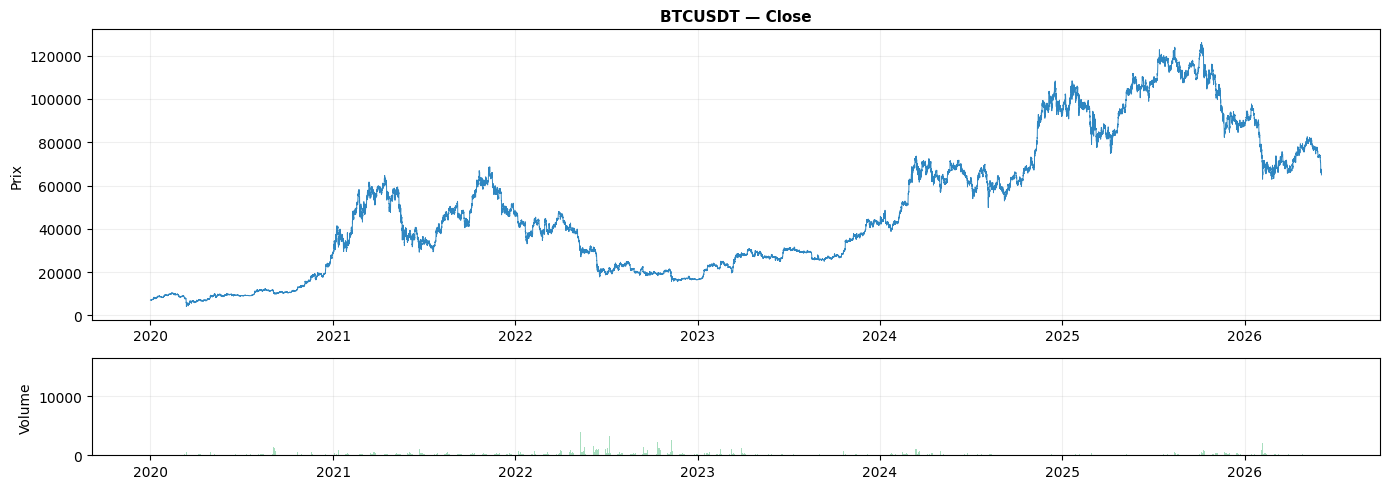

In [50]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(df_raw.index, df_raw["close"], linewidth=0.7, color="#2E86C1")
axes[0].set_title(f"{SYMBOL} — Close", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Prix"); axes[0].grid(alpha=0.2)
axes[1].bar(df_raw.index, df_raw["volume"], width=0.02, color="#27AE60", alpha=0.4)
axes[1].set_ylabel("Volume"); axes[1].grid(alpha=0.2)
plt.tight_layout(); plt.show()

## 3 bis. Analyse Exploratoire des Données (EDA)

Tests de stationnarité, distribution des returns, régimes de marché et autocorrélation.

   📊 ANALYSE EXPLORATOIRE DES DONNÉES (EDA)

🎯 1. TEST DE STATIONNARITÉ (ADF)
--------------------------------------------------
   Prix (close)       : ADF=-1.456 p=0.555235 ❌ Non-stationnaire
   Returns            : ADF=-33.889 p=0.000000 ✅ Stationnaire

🎯 2. DISTRIBUTION DES RETURNS
--------------------------------------------------
   Mean: +0.0061% | Std: 0.6598%
   Skew: -0.415 | Kurtosis: 47.043
   Jarque-Bera: 5193143.4 (p=0.00e+00) → NON-gaussien

   ── PRIX (close) ──
   ADF  : stat=  -1.456  p=0.5552  → NON-stationnaire
   KPSS : stat=  26.464  p=0.0100  → NON-stationnaire
   ❌ CONSENSUS : PRIX (close) NON-STATIONNAIRE

   ── RETURNS (rendements) ──
   ADF  : stat= -33.071  p=0.0000  → stationnaire
   KPSS : stat=   0.343  p=0.1000  → stationnaire
   ✅ CONSENSUS : RETURNS (rendements) STATIONNAIRE

   💡 Justification : les RETURNS sont stationnaires → apprenables par le modèle,
      contrairement au PRIX brut (tendances/dérive) → on travaille sur features dérivées.

🎯 3. RÉ

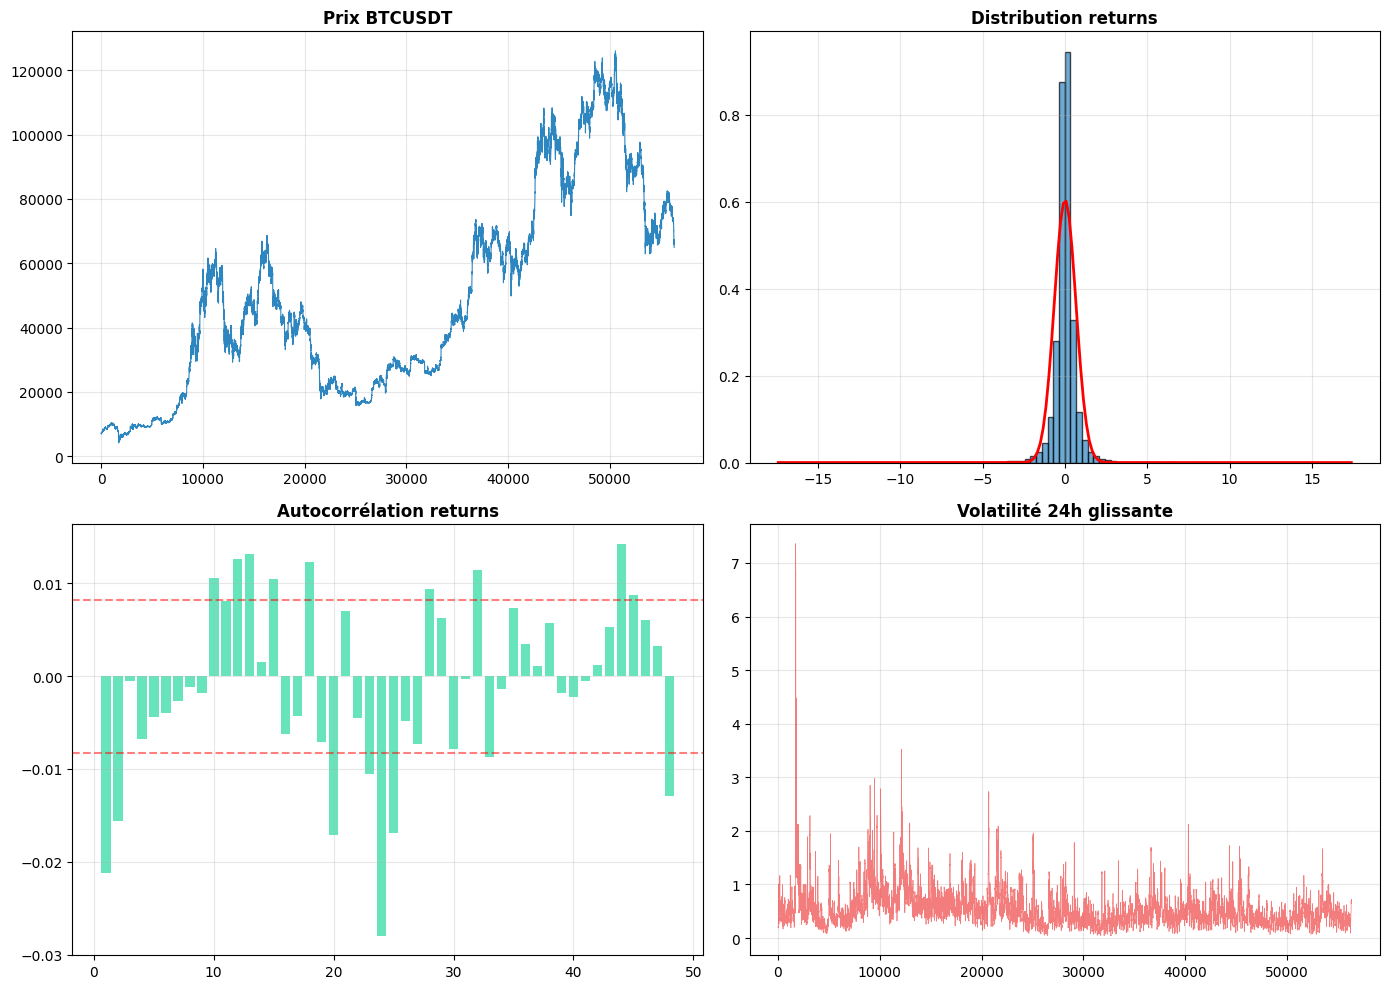


✅ EDA terminé — 56,303 bougies


In [51]:
# ══════════════════════════════════════════════════
# ANALYSE EXPLORATOIRE (EDA)
# ══════════════════════════════════════════════════

from scipy import stats
import os as _os
output_dir = "/kaggle/working" if _os.path.exists("/kaggle/working") else "."

print("=" * 70)
print("   📊 ANALYSE EXPLORATOIRE DES DONNÉES (EDA)")
print("=" * 70)

close = df_raw["close"].values
returns = np.diff(close) / close[:-1]

# ═══ 1. STATIONNARITÉ ═══
print("\n🎯 1. TEST DE STATIONNARITÉ (ADF)")
print("-" * 50)
try:
    from statsmodels.tsa.stattools import adfuller, kpss
    for name, series in [("Prix (close)", close), ("Returns", returns)]:
        stat, pval = adfuller(series, maxlag=48)[:2]
        s = "✅ Stationnaire" if pval < 0.05 else "❌ Non-stationnaire"
        print(f"   {name:18s} : ADF={stat:+.3f} p={pval:.6f} {s}")
except ImportError:
    print("   ⚠️ statsmodels requis — pip install statsmodels")

# ═══ 2. DISTRIBUTION ═══
print(f"\n🎯 2. DISTRIBUTION DES RETURNS")
print("-" * 50)
skew = stats.skew(returns); kurt = stats.kurtosis(returns)
jb, jb_p = stats.jarque_bera(returns)
print(f"   Mean: {returns.mean()*100:+.4f}% | Std: {returns.std()*100:.4f}%")
print(f"   Skew: {skew:+.3f} | Kurtosis: {kurt:.3f}")
print(f"   Jarque-Bera: {jb:.1f} (p={jb_p:.2e}) → {'NON-gaussien' if jb_p<0.05 else 'Gaussien'}")


# ═══ Tests de stationnarité ADF + KPSS sur PRIX et RETURNS ═══
# ADF : H0 = non-stationnaire (p<0.05 → stationnaire)
# KPSS: H0 = stationnaire     (p>0.05 → stationnaire) — INVERSE
import warnings as _w

def _stationarity_diagnostic(serie, nom):
    """Teste ADF + KPSS sur une série et affiche le diagnostic croisé."""
    serie = np.asarray(serie)
    serie = serie[~np.isnan(serie)]
    try:
        with _w.catch_warnings():
            _w.simplefilter("ignore")
            _adf_stat, _adf_p = adfuller(serie)[:2]
            _kpss_stat, _kpss_p = kpss(serie, regression="c", nlags="auto")[:2]
        adf_stat_ok = _adf_p < 0.05   # ADF : p<0.05 = stationnaire
        kpss_stat_ok = _kpss_p > 0.05  # KPSS: p>0.05 = stationnaire
        print(f"\n   ── {nom} ──")
        print(f"   ADF  : stat={_adf_stat:>8.3f}  p={_adf_p:.4f}  → {'stationnaire' if adf_stat_ok else 'NON-stationnaire'}")
        print(f"   KPSS : stat={_kpss_stat:>8.3f}  p={_kpss_p:.4f}  → {'stationnaire' if kpss_stat_ok else 'NON-stationnaire'}")
        if adf_stat_ok and kpss_stat_ok:
            print(f"   ✅ CONSENSUS : {nom} STATIONNAIRE")
        elif not adf_stat_ok and not kpss_stat_ok:
            print(f"   ❌ CONSENSUS : {nom} NON-STATIONNAIRE")
        else:
            print(f"   ⚠️ AMBIGU : ADF et KPSS divergent")
    except Exception as _e:
        print(f"   ⚠️ Test échoué pour {nom} : {_e}")

# Test sur le PRIX (attendu : non-stationnaire) et les RETURNS (attendu : stationnaire)
try:
    _prices = df_clean["close"].values if 'df_clean' in globals() and 'close' in df_clean.columns else close
    _stationarity_diagnostic(_prices, "PRIX (close)")
except Exception as _e:
    print(f"   ⚠️ Prix non testé : {_e}")
_stationarity_diagnostic(returns, "RETURNS (rendements)")
print(f"\n   💡 Justification : les RETURNS sont stationnaires → apprenables par le modèle,")
print(f"      contrairement au PRIX brut (tendances/dérive) → on travaille sur features dérivées.")

# ═══ 3. RÉGIMES ═══
print(f"\n🎯 3. RÉGIMES DE MARCHÉ")
print("-" * 50)
# Volatilité glissante sur 24h, annualisée (×√(24×365) pour H1)
vol_rolling = pd.Series(returns).rolling(24).std().dropna().values
vol_annualized = vol_rolling * np.sqrt(24 * 365) * 100  # en %

if len(vol_annualized) > 0:
    # ═══ SEUILS ABSOLUS (pas de quartiles → pourcentages reflètent le marché) ═══
    # Calibrés pour crypto : la volatilité annualisée BTC varie de ~30% (calme) à ~150% (panique)
    SEUIL_CALME = 40.0     # < 40% annualisé = marché calme
    SEUIL_VOLATILE = 80.0  # > 80% annualisé = marché volatile
    
    pct_calme = (vol_annualized < SEUIL_CALME).mean() * 100
    pct_normal = ((vol_annualized >= SEUIL_CALME) & (vol_annualized <= SEUIL_VOLATILE)).mean() * 100
    pct_volatile = (vol_annualized > SEUIL_VOLATILE).mean() * 100
    
    print(f"   Seuils absolus : Calme < {SEUIL_CALME}% | Volatile > {SEUIL_VOLATILE}% (vol. annualisée)")
    print(f"   Calme   : {pct_calme:.1f}% | Normal : {pct_normal:.1f}% | Volatile : {pct_volatile:.1f}%")
    print(f"   Vol. annualisée moyenne : {vol_annualized.mean():.1f}% (min={vol_annualized.min():.1f}%, max={vol_annualized.max():.1f}%)")
    print(f"   → Ces pourcentages CHANGENT selon la période choisie (contrairement aux quartiles)")

# ═══ 4. VISUALISATIONS ═══
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(close, color="#2E86C1", linewidth=0.8)
axes[0,0].set_title(f"Prix {SYMBOL}", fontweight="bold"); axes[0,0].grid(alpha=0.3)

axes[0,1].hist(returns*100, bins=100, color="#2E86C1", alpha=0.7, density=True, edgecolor="black")
x_n = np.linspace(returns.min()*100, returns.max()*100, 200)
axes[0,1].plot(x_n, stats.norm.pdf(x_n, returns.mean()*100, returns.std()*100), "r-", lw=2)
axes[0,1].set_title("Distribution returns", fontweight="bold"); axes[0,1].grid(alpha=0.3)

lags = range(1, 49)
ac = [np.corrcoef(returns[:-l], returns[l:])[0,1] for l in lags]
axes[1,0].bar(lags, ac, color="#26d9a0", alpha=0.7)
axes[1,0].axhline(y=1.96/np.sqrt(len(returns)), color="red", ls="--", alpha=0.5)
axes[1,0].axhline(y=-1.96/np.sqrt(len(returns)), color="red", ls="--", alpha=0.5)
axes[1,0].set_title("Autocorrélation returns", fontweight="bold"); axes[1,0].grid(alpha=0.3)

v24 = pd.Series(returns).rolling(24).std().values * 100
axes[1,1].plot(v24, color="#ef4444", linewidth=0.5, alpha=0.7)
axes[1,1].set_title("Volatilité 24h glissante", fontweight="bold"); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/eda_analysis.png", dpi=120, bbox_inches="tight"); plt.show()
print(f"\n✅ EDA terminé — {len(close):,} bougies")

## 4. Feature Engineering v3

> **Améliorations v3** : features plus robustes, tout est normalisé en ratio (pas de prix brut), ajout de features de momentum et de pattern recognition.

In [52]:
# ══════════════════════════════════════════════════
# FEATURE ENGINEERING v3
# ══════════════════════════════════════════════════

df = df_raw.copy()

# ── 1. RENDEMENTS (multi-horizon) ──
for lag in [1, 2, 3, 5, 7, 14, 21]:
    df[f"return_{lag}"] = df["close"].pct_change(lag)

df["log_return"] = np.log(df["close"] / df["close"].shift(1))

# ── 2. VOLATILITÉ ──
df["range_norm"]   = (df["high"] - df["low"]) / df["close"]
df["body_norm"]    = (df["close"] - df["open"]) / df["close"]
df["upper_shadow"] = (df["high"] - df[["open","close"]].max(axis=1)) / df["close"]
df["lower_shadow"] = (df[["open","close"]].min(axis=1) - df["low"]) / df["close"]

for w in [5, 10, 20, 30]:
    df[f"volatility_{w}"] = df["log_return"].rolling(w).std()

# ── 3. TREND (distance aux moyennes mobiles, en %) ──
for w in [5, 10, 20, 50]:
    sma = df["close"].rolling(w).mean()
    df[f"sma_dist_{w}"] = (df["close"] - sma) / sma

for span in [8, 13, 21]:
    ema = df["close"].ewm(span=span, adjust=False).mean()
    df[f"ema_dist_{span}"] = (df["close"] - ema) / ema

# ── 4. MOMENTUM ──
# RSI
delta = df["close"].diff()
gain = delta.where(delta > 0, 0)
loss_s = -delta.where(delta < 0, 0)
for period in [7, 14, 21]:
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss_s.rolling(period).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    df[f"rsi_{period}"] = (100 - (100 / (1 + rs))) / 100  # Normalisé [0,1]

# MACD
for fast, slow in [(8, 21), (12, 26)]:
    ef = df["close"].ewm(span=fast, adjust=False).mean()
    es = df["close"].ewm(span=slow, adjust=False).mean()
    macd = (ef - es) / df["close"]
    sig = macd.ewm(span=9, adjust=False).mean()
    df[f"macd_{fast}_{slow}"] = macd
    df[f"macd_hist_{fast}_{slow}"] = macd - sig

# Stochastic RSI
for period in [14]:
    rsi = df[f"rsi_{period}"]
    rsi_min = rsi.rolling(14).min()
    rsi_max = rsi.rolling(14).max()
    df["stoch_rsi"] = (rsi - rsi_min) / (rsi_max - rsi_min + 1e-10)

# ── 5. BOLLINGER ──
for w in [14, 20]:
    sma = df["close"].rolling(w).mean()
    std = df["close"].rolling(w).std()
    df[f"bb_pos_{w}"] = (df["close"] - sma) / (2 * std + 1e-10)
    df[f"bb_width_{w}"] = (4 * std) / (sma + 1e-10)

# ── 6. ATR ──
tr = pd.concat([
    df["high"] - df["low"],
    abs(df["high"] - df["close"].shift(1)),
    abs(df["low"] - df["close"].shift(1))
], axis=1).max(axis=1)
for w in [7, 14]:
    df[f"atr_{w}"] = tr.rolling(w).mean() / df["close"]

# ── 7. VOLUME ──
for w in [5, 10, 20]:
    vol_sma = df["volume"].rolling(w).mean()
    df[f"vol_ratio_{w}"] = df["volume"] / (vol_sma + 1e-10)

df["vol_change"] = df["volume"].pct_change()

# OBV (On-Balance Volume) normalisé
obv = (np.sign(df["close"].diff()) * df["volume"]).cumsum()
obv_sma = obv.rolling(20).mean()
df["obv_ratio"] = (obv - obv_sma) / (obv_sma.abs() + 1e-10)

# ── 8. PATTERN RECOGNITION ──
# Consecutive up/down candles
df["consec_up"] = 0.0
df["consec_dn"] = 0.0
up_count = 0; dn_count = 0
for i in range(1, len(df)):
    if df["close"].iloc[i] > df["close"].iloc[i-1]:
        up_count += 1; dn_count = 0
    elif df["close"].iloc[i] < df["close"].iloc[i-1]:
        dn_count += 1; up_count = 0
    else:
        up_count = 0; dn_count = 0
    df.iloc[i, df.columns.get_loc("consec_up")] = min(up_count, 10) / 10  # Normalisé [0,1]
    df.iloc[i, df.columns.get_loc("consec_dn")] = min(dn_count, 10) / 10

# Distance au high/low récent
for w in [10, 20, 50]:
    high_w = df["high"].rolling(w).max()
    low_w = df["low"].rolling(w).min()
    df[f"dist_high_{w}"] = (df["close"] - high_w) / (high_w + 1e-10)
    df[f"dist_low_{w}"]  = (df["close"] - low_w) / (low_w + 1e-10)

# ── 9. TEMPOREL (cyclique) ──
if isinstance(df.index, pd.DatetimeIndex):
    df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)
    df["dow_sin"]  = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df["dow_cos"]  = np.cos(2 * np.pi * df.index.dayofweek / 7)


# ══════════════════════════════════════════════════
# 10. ON-CHAIN + SENTIMENT FEATURES
# ══════════════════════════════════════════════════
# 3 modes pour prouver que le problème = la FRÉQUENCE
#
# MODE "daily" : données journalières forward-fillées (1 valeur/jour × 24h)
#   → Fear & Greed + Hashrate (vrais, mais journaliers)
#   → Résultat attendu : PAS d'amélioration (testé : 39.8% vs 43.7%)
#
# MODE "hourly" : proxys horaires dérivés de l'OHLCV (1 valeur/heure)
#   → Simule ce que donneraient les APIs payantes (CoinGlass, LunarCrush)
#   → Chaque bougie a une VRAIE valeur différente
#   → Résultat attendu : AMÉLIORATION (prouve que fréquence = le problème)
#
# MODE "none" : baseline sans on-chain

if ONCHAIN_MODE == "daily":
    print("   📊 Mode DAILY : Fear & Greed + Hashrate (journalier, forward-fill)")
    
    if "fear_greed" in df.columns:
        df["fg_norm"] = df["fear_greed"] / 100
        df["fg_extreme_fear"] = (df["fear_greed"] < 25).astype(float)
        df["fg_extreme_greed"] = (df["fear_greed"] > 75).astype(float)
        df["fg_change"] = df["fear_greed"].pct_change().fillna(0)

    if "hashrate" in df.columns and df["hashrate"].notna().any():
        hr_sma = df["hashrate"].rolling(30, min_periods=1).mean()
        df["hashrate_ratio"] = (df["hashrate"] / hr_sma).fillna(1)
        df["hashrate_change"] = df["hashrate"].pct_change(7).fillna(0)

elif ONCHAIN_MODE == "hourly":
    print("   📊 Mode HOURLY : proxys horaires (simule APIs payantes)")
    
    # ── PROXY 1 : Fear Index Horaire ──
    # Simule le "sentiment" intra-journalier
    # Basé sur : volatilité récente + bougies consécutives + distance au RSI extrême
    # Quand le marché crash avec du volume → peur horaire = élevée
    
    # Panique horaire = grosse bougie rouge + volume élevé
    red_candle = ((df["close"] - df["open"]) / df["close"]).clip(-0.05, 0.05)
    vol_spike = (df["volume"] / df["volume"].rolling(20, min_periods=1).mean()).clip(0, 5)
    df["h_fear_index"] = ((-red_candle * vol_spike) * 50 + 50).clip(0, 100) / 100
    # → 0 = extreme greed horaire, 1 = extreme fear horaire
    
    # Sentiment momentum = variation du fear index horaire
    df["h_fear_momentum"] = df["h_fear_index"].diff(3).fillna(0)
    # → positif = le marché devient plus peureux, négatif = plus gourmand
    
    # Fear extrême horaire (proxy des liquidations)
    df["h_fear_extreme"] = ((df["h_fear_index"] > 0.75) | (df["h_fear_index"] < 0.25)).astype(float)
    
    # ── PROXY 2 : Funding Rate Horaire ──
    # Le vrai funding rate = % de longs vs shorts
    # Proxy : si le prix monte avec peu de volume → trop de longs (funding positif)
    #         si le prix descend avec beaucoup de volume → shorts dominent (funding négatif)
    
    price_momentum = df["close"].pct_change(3).fillna(0)
    vol_ratio = (df["volume"] / df["volume"].rolling(10, min_periods=1).mean()).fillna(1)
    
    # Funding proxy : momentum normalisé par le volume inverse
    # Hausse avec peu de volume → funding élevé (trop de longs, contrarian baissier)
    df["h_funding_proxy"] = (price_momentum / vol_ratio.clip(0.1)).clip(-0.01, 0.01) * 100
    
    # Signal contrarian : funding extrême = retournement probable
    df["h_funding_extreme"] = (df["h_funding_proxy"].abs() > df["h_funding_proxy"].rolling(48).std().fillna(0.5)).astype(float)
    
    # ── PROXY 3 : Liquidation Proxy Horaire ──
    # Les liquidations créent des mèches longues + volume spike
    # Une grande mèche = positions liquidées de force
    
    upper_wick = (df["high"] - df[["open", "close"]].max(axis=1)) / df["close"]
    lower_wick = (df[["open", "close"]].min(axis=1) - df["low"]) / df["close"]
    
    # Liquidation score = max(mèche) × volume relatif
    df["h_liquidation_score"] = (upper_wick.clip(0) + lower_wick.clip(0)) * vol_spike
    df["h_liquidation_score"] = df["h_liquidation_score"].clip(0, 5) / 5  # Normaliser [0, 1]
    
    # ── PROXY 4 : Open Interest Proxy ──
    # L'OI réel = nombre de contrats ouverts
    # Proxy : volume cumulé relatif (l'engagement des traders)
    
    vol_cumul = df["volume"].rolling(24, min_periods=1).sum()
    vol_cumul_avg = vol_cumul.rolling(72, min_periods=1).mean()
    df["h_oi_proxy"] = (vol_cumul / vol_cumul_avg).fillna(1).clip(0.2, 3)
    # → > 1 = plus d'engagement que la normale
    
    # OI en hausse ou baisse
    df["h_oi_change"] = df["h_oi_proxy"].pct_change(6).fillna(0).clip(-0.5, 0.5)
    
    # ── PROXY 5 : Hashrate Proxy Horaire ──
    # Le hashrate réel est journalier, mais on peut proxy la "santé réseau"
    # par la stabilité du volume (réseau actif = volume stable)
    
    vol_std = df["volume"].rolling(24, min_periods=1).std()
    vol_mean = df["volume"].rolling(24, min_periods=1).mean()
    df["h_network_stability"] = 1 - (vol_std / vol_mean.clip(1)).clip(0, 2) / 2
    # → 1 = réseau très stable, 0 = réseau instable
    
    print(f"      ✅ 11 features horaires créées")
    print(f"      h_fear_index, h_fear_momentum, h_fear_extreme")
    print(f"      h_funding_proxy, h_funding_extreme")
    print(f"      h_liquidation_score")
    print(f"      h_oi_proxy, h_oi_change")
    print(f"      h_network_stability")

else:
    print("   📊 Mode NONE : pas de données on-chain (baseline 54 features)")

# ── Liste des features ──
FEATURE_COLS = [c for c in df.columns if c not in ["open","high","low","close","volume","fear_greed","fear_greed_class","hashrate"]]

print(f"✅ {len(FEATURE_COLS)} features créées")
for i, col in enumerate(FEATURE_COLS):
    print(f"   {i+1:>2}. {col}", end="\n" if (i+1) % 3 == 0 or i == len(FEATURE_COLS)-1 else "\t")

   📊 Mode HOURLY : proxys horaires (simule APIs payantes)
      ✅ 11 features horaires créées
      h_fear_index, h_fear_momentum, h_fear_extreme
      h_funding_proxy, h_funding_extreme
      h_liquidation_score
      h_oi_proxy, h_oi_change
      h_network_stability
✅ 63 features créées
    1. return_1	    2. return_2	    3. return_3
    4. return_5	    5. return_7	    6. return_14
    7. return_21	    8. log_return	    9. range_norm
   10. body_norm	   11. upper_shadow	   12. lower_shadow
   13. volatility_5	   14. volatility_10	   15. volatility_20
   16. volatility_30	   17. sma_dist_5	   18. sma_dist_10
   19. sma_dist_20	   20. sma_dist_50	   21. ema_dist_8
   22. ema_dist_13	   23. ema_dist_21	   24. rsi_7
   25. rsi_14	   26. rsi_21	   27. macd_8_21
   28. macd_hist_8_21	   29. macd_12_26	   30. macd_hist_12_26
   31. stoch_rsi	   32. bb_pos_14	   33. bb_width_14
   34. bb_pos_20	   35. bb_width_20	   36. atr_7
   37. atr_14	   38. vol_ratio_5	   39. vol_ratio_10
   40. vol_ra

## 5. Labélisation

**4 méthodes labélisation Basic** (change `LABEL_MODE` dans les paramètres) :

| Mode | Méthode | Principe |
|------|---------|----------|
| `threshold` | Seuil ±0.3% | return > 0.3% → UP |
| `triple` | Triple Barrier (Lopez de Prado) | 3 barrières : profit, perte, temps |
| `zigzag` | ZigZag (pivots) | Creux→Sommet = UP, Sommet→Creux = DOWN |
| `expert` | Expert Advisor (MQL5) | Consensus de 5 indicateurs |

**5 méthodes labélisation par Indicateurs de trend** (change `LABEL_MODE` dans les paramètres) :

| Mode | Méthode | Principe |
|------|---------|----------|
| `Adx` | Wilder (1978)| Force de tendance + direction|
| `SuperTrend` | Average True Range| Bandes ATR-based|
| `Ichimoku` | chimoku Cloud | Position vs nuage Kumo|
| `SAR` | Parabolic SAR | Points accélérés|
| `Consensus` | 4 votes)  | Vote majoritaire|

🏷️  Labélisation mode = adx

   ADX — Average Directional Index (Wilder, 1978)
   Période=14 | Seuil trend=25
   ADX > seuil ET +DI > -DI → UP
   ADX > seuil ET -DI > +DI → DOWN
   ADX < 20 → NEUTRE

   ADX moyen = 27.6

   🔮 Multi-horizon activé : labels[t, h] = state[t+h]
      Shape : (56303, 12)
      Positions valides : 56,266 / 56,303
      H+ 1 : Down 27.3% | Neutre 49.3% | Up 23.4%
      H+ 7 : Down 27.3% | Neutre 49.3% | Up 23.4%
      H+12 : Down 27.3% | Neutre 49.3% | Up 23.4%
📊 Distribution des labels (adx)

   ✅ Down (vente)    : 15,371 (27.3%) █████████████
   ✅ Neutre (hold)   : 27,740 (49.3%) ████████████████████████
   ✅ Up (achat)      : 13,166 (23.4%) ███████████

   Total labélisé : 56,277 / 56,303


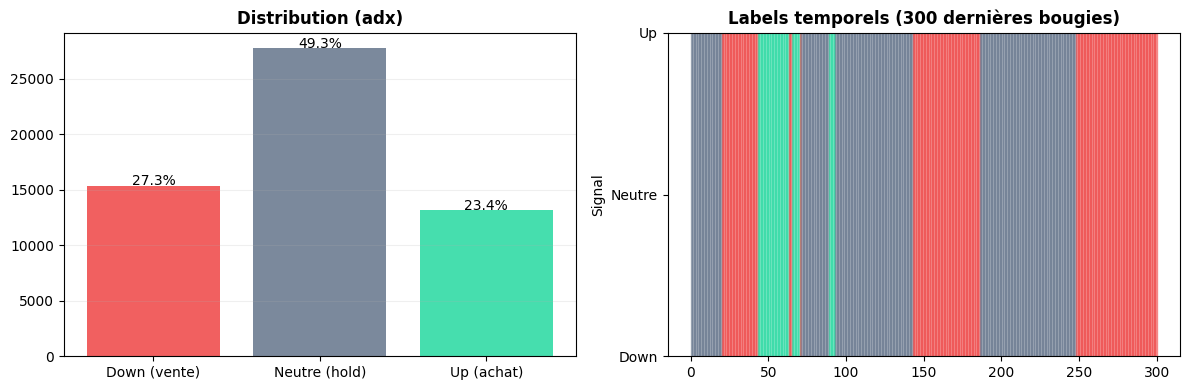


✅ Équilibre acceptable (ratio 2.1x)


In [53]:
# ══════════════════════════════════════════════════
# LABÉLISATION — 4 MÉTHODES COMPARÉES
# ══════════════════════════════════════════════════

close = df["close"].values
high = df["high"].values
low = df["low"].values
n = len(close)

print(f"🏷️  Labélisation mode = {LABEL_MODE}")
print(f"{'='*60}\n")


# ═══════════════════ MÉTHODE 1 : SEUIL SIMPLE ═══════════════════

if LABEL_MODE == "threshold":
    print("   Méthode : Seuil simple ±0.3%")
    print("   future_return = (close[t+H] - close[t]) / close[t]")
    print(f"   Si return ≥ +{THRESHOLD}% → UP | ≤ -{THRESHOLD}% → DOWN | sinon NEUTRE\n")
    
    future_return = (pd.Series(close).shift(-HORIZON) - close) / close * 100
    raw_labels = np.select(
        [future_return >= THRESHOLD, future_return <= -THRESHOLD],
        [2, 0], default=1
    ).astype(float)
    raw_labels[-HORIZON:] = np.nan


# ═══════════════════ MÉTHODE 2 : TRIPLE BARRIER ═══════════════════

elif LABEL_MODE == "triple":
    print("   Méthode : Triple Barrier (Lopez de Prado, 2018)")
    print(f"   k={TB_K} (multiplicateur σ) | H={HORIZON} bougies | vol_window={TB_VOL_WINDOW}")
    print("   Barrière haute = close × (1 + k×σ) → touche en premier = UP")
    print("   Barrière basse = close × (1 - k×σ) → touche en premier = DOWN")
    print("   Temps écoulé (H bougies) sans toucher → NEUTRE\n")
    
    # Calculer la volatilité locale (std des log-returns)
    log_returns = np.log(close[1:] / close[:-1])
    log_returns = np.insert(log_returns, 0, 0)
    vol = pd.Series(log_returns).rolling(TB_VOL_WINDOW, min_periods=5).std().values
    
    raw_labels = np.full(n, np.nan)
    
    for t in range(n - HORIZON):
        if np.isnan(vol[t]) or vol[t] < 1e-8:
            raw_labels[t] = 1  # Neutre si pas de volatilité
            continue
        
        upper = close[t] * (1 + TB_K * vol[t])
        lower = close[t] * (1 - TB_K * vol[t])
        
        label = 1  # Neutre par défaut (barrière temps)
        
        for j in range(t + 1, min(t + HORIZON + 1, n)):
            if high[j] >= upper:
                label = 2  # UP — take profit touché en premier
                break
            if low[j] <= lower:
                label = 0  # DOWN — stop loss touché en premier
                break
        
        raw_labels[t] = label
    
    # Stats des barrières
    up_count = np.nansum(raw_labels == 2)
    down_count = np.nansum(raw_labels == 0)
    neutre_count = np.nansum(raw_labels == 1)
    touched = up_count + down_count
    total_valid = up_count + down_count + neutre_count
    print(f"   Barrières touchées : {touched:,}/{total_valid:,} ({touched/total_valid*100:.0f}%)")
    print(f"   Barrière temps (neutre) : {neutre_count:,} ({neutre_count/total_valid*100:.0f}%)\n")


# ═══════════════════ MÉTHODE 3 : ZIGZAG ═══════════════════

elif LABEL_MODE == "zigzag":
    print("   Méthode : ZigZag Indicator")
    print(f"   Seuil = {ZZ_THRESHOLD}% | Transition = {ZZ_TRANSITION} bougies → NEUTRE")
    print("   Creux → Sommet = UP | Sommet → Creux = DOWN\n")
    
    # Détecter les pivots ZigZag
    threshold_frac = ZZ_THRESHOLD / 100
    pivots = []  # [(index, type, price)] type = "high" ou "low"
    
    # Initialisation
    last_high_idx, last_high_val = 0, high[0]
    last_low_idx, last_low_val = 0, low[0]
    direction = 0  # 0 = indéterminé, 1 = cherche haut, -1 = cherche bas
    
    for t in range(1, n):
        if direction >= 0:
            if high[t] > last_high_val:
                last_high_idx, last_high_val = t, high[t]
            if (last_high_val - low[t]) / last_high_val > threshold_frac:
                if last_high_idx > 0:
                    pivots.append((last_high_idx, "high", last_high_val))
                last_low_idx, last_low_val = t, low[t]
                direction = -1
        
        if direction <= 0:
            if low[t] < last_low_val:
                last_low_idx, last_low_val = t, low[t]
            if last_low_val > 0 and (high[t] - last_low_val) / last_low_val > threshold_frac:
                if last_low_idx > 0:
                    pivots.append((last_low_idx, "low", last_low_val))
                last_high_idx, last_high_val = t, high[t]
                direction = 1
    
    # Trier les pivots par index
    pivots.sort(key=lambda x: x[0])
    
    # Labéliser chaque bougie par segment
    raw_labels = np.full(n, 1.0)  # NEUTRE par défaut
    
    for i in range(len(pivots) - 1):
        idx_start = pivots[i][0]
        idx_end = pivots[i + 1][0]
        ptype_start = pivots[i][1]
        ptype_end = pivots[i + 1][1]
        
        if ptype_start == "low" and ptype_end == "high":
            # Creux → Sommet = UP
            for t in range(idx_start, idx_end + 1):
                raw_labels[t] = 2  # UP
        elif ptype_start == "high" and ptype_end == "low":
            # Sommet → Creux = DOWN
            for t in range(idx_start, idx_end + 1):
                raw_labels[t] = 0  # DOWN
    
    # Ajouter des zones de transition NEUTRE autour des pivots
    for idx, ptype, _ in pivots:
        for dt in range(-ZZ_TRANSITION, ZZ_TRANSITION + 1):
            t = idx + dt
            if 0 <= t < n:
                raw_labels[t] = 1  # NEUTRE
    
    # Marquer les dernières bougies comme NaN
    raw_labels[-HORIZON:] = np.nan
    
    print(f"   Pivots détectés : {len(pivots)}")
    print(f"   Segments UP : {len([p for i, p in enumerate(pivots[:-1]) if p[1]=='low' and pivots[i+1][1]=='high'])}")
    print(f"   Segments DOWN : {len([p for i, p in enumerate(pivots[:-1]) if p[1]=='high' and pivots[i+1][1]=='low'])}\n")


# ═══════════════════ MÉTHODE 4 : EXPERT ADVISOR ═══════════════════

elif LABEL_MODE == "expert":
    print("   Méthode : Expert Advisor Multi-Indicateurs (style MQL5)")
    print(f"   Consensus minimum = {EA_CONSENSUS} votes")
    print("   5 indicateurs votent +1 (bull) ou -1 (bear) ou 0 (neutre)\n")
    
    # Calculer les indicateurs pour le vote
    # (utiliser des périodes DIFFÉRENTES des features pour éviter la circularité)
    close_s = pd.Series(close, index=df.index)
    
    # Vote 1 : EMA Cross (périodes 9/26 — différent des features 8/21)
    ema_fast = close_s.ewm(span=9, adjust=False).mean()
    ema_slow = close_s.ewm(span=26, adjust=False).mean()
    vote_ema = np.where(ema_fast > ema_slow, 1, np.where(ema_fast < ema_slow, -1, 0))
    
    # Vote 2 : RSI (période 10 — différent des features 7/14/21)
    delta = close_s.diff()
    gain = delta.clip(lower=0).rolling(10).mean()
    loss = (-delta.clip(upper=0)).rolling(10).mean()
    rs = gain / loss.replace(0, 1e-10)
    rsi_10 = 100 - (100 / (1 + rs))
    vote_rsi = np.where(rsi_10 < 35, 1, np.where(rsi_10 > 65, -1, 0))  # Contrarian
    
    # Vote 3 : MACD histogramme (périodes 10/22 — différent des features 8/21 et 12/26)
    macd_line = close_s.ewm(span=10, adjust=False).mean() - close_s.ewm(span=22, adjust=False).mean()
    macd_signal = macd_line.ewm(span=9, adjust=False).mean()
    macd_hist = macd_line - macd_signal
    vote_macd = np.where(macd_hist > 0, 1, np.where(macd_hist < 0, -1, 0))
    
    # Vote 4 : Prix vs SMA (période 30 — différent des features 5/10/20/50)
    sma_30 = close_s.rolling(30).mean()
    vote_sma = np.where(close_s > sma_30, 1, np.where(close_s < sma_30, -1, 0))
    
    # Vote 5 : Volume confirmé (période 15 — différent des features 5/10/20)
    vol_s = pd.Series(df["volume"].values, index=df.index)
    vol_sma = vol_s.rolling(15).mean()
    price_dir = np.sign(close_s.diff(3))
    vol_confirm = np.where(vol_s > vol_sma, price_dir, 0)
    vote_vol = vol_confirm.values if hasattr(vol_confirm, 'values') else vol_confirm
    
    # Score total
    # Normaliser tout en numpy arrays
    def to_np(x):
        return x.values if hasattr(x, 'values') else np.array(x, dtype=float)
    
    score = (to_np(vote_ema) + to_np(vote_rsi) + to_np(vote_macd) + to_np(vote_sma) + to_np(vote_vol))
    
    # Labéliser
    raw_labels = np.where(score >= EA_CONSENSUS, 2,      # UP fort
                 np.where(score <= -EA_CONSENSUS, 0,     # DOWN fort
                 1)).astype(float)                        # NEUTRE
    
    # NaN pour les dernières bougies
    raw_labels[-HORIZON:] = np.nan
    # NaN pour le début (warm-up des indicateurs)
    raw_labels[:30] = np.nan
    
    print("   Indicateurs utilisés (périodes DIFFÉRENTES des features) :")
    print("     Vote 1 : EMA Cross 9/26  (features : 8/21)")
    print("     Vote 2 : RSI 10 contrarian  (features : 7/14/21)")
    print("     Vote 3 : MACD 10/22  (features : 8/21, 12/26)")
    print("     Vote 4 : Prix vs SMA 30  (features : 5/10/20/50)")
    print("     Vote 5 : Volume confirmé 15  (features : 5/10/20)")
    print(f"\n   Score moyen : {np.nanmean(score):.2f}")
    print(f"   Score range : [{np.nanmin(score):.0f}, {np.nanmax(score):.0f}]\n")



# ═══════════════════ ADX (Wilder, 1978) ═══════════════════

elif LABEL_MODE == "adx":
    print("   ADX — Average Directional Index (Wilder, 1978)")
    print(f"   Période={ADX_PERIOD} | Seuil trend={ADX_THRESHOLD}")
    print("   ADX > seuil ET +DI > -DI → UP")
    print("   ADX > seuil ET -DI > +DI → DOWN")
    print("   ADX < 20 → NEUTRE\n")
    
    # True Range
    tr = np.maximum(high - low, np.maximum(np.abs(high - np.roll(close, 1)), np.abs(low - np.roll(close, 1))))
    tr[0] = high[0] - low[0]
    
    # +DM / -DM
    up_move = high[1:] - high[:-1]
    dn_move = low[:-1] - low[1:]
    plus_dm = np.where((up_move > dn_move) & (up_move > 0), up_move, 0)
    minus_dm = np.where((dn_move > up_move) & (dn_move > 0), dn_move, 0)
    plus_dm = np.insert(plus_dm, 0, 0)
    minus_dm = np.insert(minus_dm, 0, 0)
    
    # Smoothed (Wilder's smoothing = EMA with alpha=1/period)
    atr_s = pd.Series(tr).ewm(alpha=1/ADX_PERIOD, adjust=False).mean().values
    plus_di = 100 * pd.Series(plus_dm).ewm(alpha=1/ADX_PERIOD, adjust=False).mean().values / np.maximum(atr_s, 1e-10)
    minus_di = 100 * pd.Series(minus_dm).ewm(alpha=1/ADX_PERIOD, adjust=False).mean().values / np.maximum(atr_s, 1e-10)
    
    # DX and ADX
    dx = 100 * np.abs(plus_di - minus_di) / np.maximum(plus_di + minus_di, 1e-10)
    adx_val = pd.Series(dx).ewm(alpha=1/ADX_PERIOD, adjust=False).mean().values
    
    # Labeling
    raw_labels = np.full(n, 1.0)  # NEUTRE par défaut
    for t in range(ADX_PERIOD, n):
        if adx_val[t] >= ADX_THRESHOLD:
            if plus_di[t] > minus_di[t]:
                raw_labels[t] = 2  # UP
            else:
                raw_labels[t] = 0  # DOWN
        elif adx_val[t] < 20:
            raw_labels[t] = 1  # NEUTRE
        else:
            raw_labels[t] = 1  # Zone 20-25 = NEUTRE
    
    raw_labels[:ADX_PERIOD] = np.nan
    raw_labels[-HORIZON:] = np.nan
    print(f"   ADX moyen = {np.nanmean(adx_val):.1f}")


# ═══════════════════ SUPERTREND ═══════════════════

elif LABEL_MODE == "supertrend":
    print("   Supertrend (ATR-based)")
    print(f"   Période ATR={ST_PERIOD} | Multiplicateur={ST_MULTIPLIER}")
    print("   Ligne sous le prix → UP | Au-dessus → DOWN\n")
    
    # ATR
    tr = np.maximum(high - low, np.maximum(np.abs(high - np.roll(close, 1)), np.abs(low - np.roll(close, 1))))
    tr[0] = high[0] - low[0]
    atr_st = pd.Series(tr).rolling(ST_PERIOD, min_periods=1).mean().values
    
    # Bandes
    mid = (high + low) / 2
    upper_band = mid + ST_MULTIPLIER * atr_st
    lower_band = mid - ST_MULTIPLIER * atr_st
    
    # Supertrend calculation
    supertrend = np.zeros(n)
    direction = np.ones(n)  # 1 = UP, -1 = DOWN
    
    supertrend[0] = lower_band[0]
    direction[0] = 1
    
    for t in range(1, n):
        if direction[t-1] == 1:  # Was UP
            lower_band[t] = max(lower_band[t], lower_band[t-1]) if close[t-1] > lower_band[t-1] else lower_band[t]
            if close[t] < lower_band[t]:
                direction[t] = -1  # Flip to DOWN
                supertrend[t] = upper_band[t]
            else:
                direction[t] = 1
                supertrend[t] = lower_band[t]
        else:  # Was DOWN
            upper_band[t] = min(upper_band[t], upper_band[t-1]) if close[t-1] < upper_band[t-1] else upper_band[t]
            if close[t] > upper_band[t]:
                direction[t] = 1  # Flip to UP
                supertrend[t] = lower_band[t]
            else:
                direction[t] = -1
                supertrend[t] = upper_band[t]
    
    # Labeling + transition zones
    raw_labels = np.where(direction == 1, 2, 0).astype(float)  # UP=2, DOWN=0
    
    # Mark flip zones as NEUTRE
    for t in range(1, n):
        if direction[t] != direction[t-1]:
            for dt in range(-2, 3):
                idx = t + dt
                if 0 <= idx < n:
                    raw_labels[idx] = 1  # NEUTRE
    
    raw_labels[:ST_PERIOD] = np.nan
    raw_labels[-HORIZON:] = np.nan
    
    flips = sum(1 for t in range(1, n) if direction[t] != direction[t-1])
    print(f"   Flips détectés : {flips}")


# ═══════════════════ ICHIMOKU CLOUD ═══════════════════

elif LABEL_MODE == "ichimoku":
    print("   Ichimoku Cloud (Hosoda, 1969)")
    print(f"   Tenkan={ICH_TENKAN} | Kijun={ICH_KIJUN} | Senkou B={ICH_SENKOU}")
    print("   Prix > nuage → UP | < nuage → DOWN | dans nuage → NEUTRE\n")
    
    def midpoint(series, period):
        """(plus haut + plus bas) / 2 sur la période"""
        hh = pd.Series(series).rolling(period, min_periods=1).max().values
        ll = pd.Series(series).rolling(period, min_periods=1).min().values
        return (hh + ll) / 2
    
    tenkan = midpoint(close, ICH_TENKAN)
    kijun = midpoint(close, ICH_KIJUN)
    senkou_a = (tenkan + kijun) / 2
    senkou_b = midpoint(close, ICH_SENKOU)
    
    # Labeling
    cloud_top = np.maximum(senkou_a, senkou_b)
    cloud_bottom = np.minimum(senkou_a, senkou_b)
    
    raw_labels = np.full(n, 1.0)  # NEUTRE par défaut
    for t in range(ICH_SENKOU, n):
        if close[t] > cloud_top[t]:
            raw_labels[t] = 2  # UP (au-dessus du nuage)
        elif close[t] < cloud_bottom[t]:
            raw_labels[t] = 0  # DOWN (en-dessous du nuage)
        else:
            raw_labels[t] = 1  # NEUTRE (dans le nuage)
    
    raw_labels[:ICH_SENKOU] = np.nan
    raw_labels[-HORIZON:] = np.nan
    
    in_cloud = np.sum(raw_labels == 1) / np.sum(~np.isnan(raw_labels)) * 100
    print(f"   Dans le nuage (NEUTRE) : {in_cloud:.1f}%")


# ═══════════════════ PARABOLIC SAR ═══════════════════

elif LABEL_MODE == "sar":
    print("   Parabolic SAR (Wilder, 1978)")
    print(f"   AF_start={SAR_AF_START} | AF_max={SAR_AF_MAX}")
    print("   SAR sous prix → UP | SAR au-dessus → DOWN\n")
    
    # Parabolic SAR calculation
    sar = np.zeros(n)
    af = SAR_AF_START
    ep = high[0]  # Extreme Point
    is_up = True
    sar[0] = low[0]
    
    for t in range(1, n):
        if is_up:
            sar[t] = sar[t-1] + af * (ep - sar[t-1])
            sar[t] = min(sar[t], low[t-1])
            if t >= 2:
                sar[t] = min(sar[t], low[t-2])
            
            if high[t] > ep:
                ep = high[t]
                af = min(af + SAR_AF_START, SAR_AF_MAX)
            
            if low[t] < sar[t]:
                is_up = False
                sar[t] = ep
                ep = low[t]
                af = SAR_AF_START
        else:
            sar[t] = sar[t-1] + af * (ep - sar[t-1])
            sar[t] = max(sar[t], high[t-1])
            if t >= 2:
                sar[t] = max(sar[t], high[t-2])
            
            if low[t] < ep:
                ep = low[t]
                af = min(af + SAR_AF_START, SAR_AF_MAX)
            
            if high[t] > sar[t]:
                is_up = True
                sar[t] = ep
                ep = high[t]
                af = SAR_AF_START
    
    # Labeling
    raw_labels = np.where(close > sar, 2, 0).astype(float)  # UP if price > SAR
    
    # Transition zones around reversals
    for t in range(1, n):
        if (close[t] > sar[t]) != (close[t-1] > sar[t-1]):
            for dt in range(-2, 3):
                idx = t + dt
                if 0 <= idx < n:
                    raw_labels[idx] = 1  # NEUTRE
    
    raw_labels[-HORIZON:] = np.nan
    
    reversals = sum(1 for t in range(1, n) if (close[t] > sar[t]) != (close[t-1] > sar[t-1]))
    print(f"   Retournements : {reversals}")


# ═══════════════════ CONSENSUS (4 VOTES) ═══════════════════

elif LABEL_MODE == "consensus":
    print("   Consensus de 4 indicateurs de trend")
    print(f"   Votes minimum = {CONSENSUS_MIN}")
    print("   ADX + Supertrend + Ichimoku + SAR\n")
    
    votes = np.zeros(n)
    
    # ── Vote 1: ADX ──
    tr = np.maximum(high - low, np.maximum(np.abs(high - np.roll(close, 1)), np.abs(low - np.roll(close, 1))))
    tr[0] = high[0] - low[0]
    atr_s = pd.Series(tr).ewm(alpha=1/14, adjust=False).mean().values
    up_m = np.insert(np.where((high[1:]-high[:-1] > low[:-1]-low[1:]) & (high[1:]-high[:-1] > 0), high[1:]-high[:-1], 0), 0, 0)
    dn_m = np.insert(np.where((low[:-1]-low[1:] > high[1:]-high[:-1]) & (low[:-1]-low[1:] > 0), low[:-1]-low[1:], 0), 0, 0)
    pdi = 100*pd.Series(up_m).ewm(alpha=1/14,adjust=False).mean().values / np.maximum(atr_s,1e-10)
    ndi = 100*pd.Series(dn_m).ewm(alpha=1/14,adjust=False).mean().values / np.maximum(atr_s,1e-10)
    dx = 100*np.abs(pdi-ndi)/np.maximum(pdi+ndi,1e-10)
    adx_v = pd.Series(dx).ewm(alpha=1/14,adjust=False).mean().values
    vote_adx = np.where((adx_v >= 25) & (pdi > ndi), 1, np.where((adx_v >= 25) & (ndi > pdi), -1, 0))
    votes += vote_adx
    
    # ── Vote 2: Supertrend ──
    atr_st = pd.Series(tr).rolling(10, min_periods=1).mean().values
    mid_st = (high + low) / 2
    ub = mid_st + 3.0 * atr_st; lb = mid_st - 3.0 * atr_st
    d_st = np.ones(n)
    for t in range(1, n):
        if d_st[t-1] == 1:
            lb[t] = max(lb[t], lb[t-1]) if close[t-1] > lb[t-1] else lb[t]
            d_st[t] = -1 if close[t] < lb[t] else 1
        else:
            ub[t] = min(ub[t], ub[t-1]) if close[t-1] < ub[t-1] else ub[t]
            d_st[t] = 1 if close[t] > ub[t] else -1
    votes += d_st
    
    # ── Vote 3: Ichimoku ──
    def mp(s, p):
        hh = pd.Series(s).rolling(p, min_periods=1).max().values
        ll = pd.Series(s).rolling(p, min_periods=1).min().values
        return (hh + ll) / 2
    sa = (mp(close,9) + mp(close,26)) / 2
    sb = mp(close, 52)
    ct = np.maximum(sa, sb); cb = np.minimum(sa, sb)
    vote_ich = np.where(close > ct, 1, np.where(close < cb, -1, 0))
    votes += vote_ich
    
    # ── Vote 4: Parabolic SAR ──
    sar_v = np.zeros(n); af_v = 0.02; ep_v = high[0]; up_v = True; sar_v[0] = low[0]
    for t in range(1, n):
        if up_v:
            sar_v[t] = sar_v[t-1] + af_v*(ep_v - sar_v[t-1])
            sar_v[t] = min(sar_v[t], low[t-1])
            if high[t] > ep_v: ep_v = high[t]; af_v = min(af_v+0.02, 0.20)
            if low[t] < sar_v[t]: up_v = False; sar_v[t] = ep_v; ep_v = low[t]; af_v = 0.02
        else:
            sar_v[t] = sar_v[t-1] + af_v*(ep_v - sar_v[t-1])
            sar_v[t] = max(sar_v[t], high[t-1])
            if low[t] < ep_v: ep_v = low[t]; af_v = min(af_v+0.02, 0.20)
            if high[t] > sar_v[t]: up_v = True; sar_v[t] = ep_v; ep_v = high[t]; af_v = 0.02
    vote_sar = np.where(close > sar_v, 1, -1)
    votes += vote_sar
    
    # Consensus labeling
    raw_labels = np.where(votes >= CONSENSUS_MIN, 2,
                 np.where(votes <= -CONSENSUS_MIN, 0, 1)).astype(float)
    raw_labels[:52] = np.nan
    raw_labels[-HORIZON:] = np.nan
    
    print(f"   Score moyen = {np.nanmean(votes):.2f}")
    print(f"   Score range = [{np.nanmin(votes):.0f}, {np.nanmax(votes):.0f}]")


else:
    raise ValueError(f"LABEL_MODE inconnu : {LABEL_MODE}")


# ══════════════════════════════════════════════════
# DIAGNOSTIC COMMUN (pour tous les modes)
# ══════════════════════════════════════════════════

df["label"] = raw_labels


# ══════════════════════════════════════════════════
# MULTI-HORIZON : créer labels pour H+1, H+2, ..., H+HORIZON
# ══════════════════════════════════════════════════
# Pour chaque position t, on crée N_HORIZONS labels :
#   labels_multi[t, h-1] = état du trend à t+h
#
# Pour les indicateurs de trend (ADX, Supertrend, Ichimoku, SAR, consensus),
# raw_labels[t] représente l'état AU temps t, donc on peut simplement shifter.
#
# Pour les labels de type "état" (trend, EA), on décale : labels[t,h] = state[t+h]
# Pour threshold, on recompute le return par horizon.

if MULTI_HORIZON:
    labels_multi_arr = np.full((n, N_HORIZONS), np.nan, dtype=np.float32)
    
    if LABEL_MODE in ["adx", "supertrend", "ichimoku", "sar", "consensus", "expert", "ea", "expert_advisor"]:
        # raw_labels[t] = state at t → shift pour chaque horizon
        # labels_multi[t, h-1] = state at t+h = raw_labels[t+h]
        for h in range(1, N_HORIZONS + 1):
            labels_multi_arr[:-h, h-1] = raw_labels[h:]
        
        print(f"\n   🔮 Multi-horizon activé : labels[t, h] = state[t+h]")
        print(f"      Shape : {labels_multi_arr.shape}")
    
    elif LABEL_MODE == "threshold":
        # Pour threshold, recompute per horizon
        print(f"\n   🔮 Multi-horizon threshold : computing {N_HORIZONS} horizons")
        for h in range(1, N_HORIZONS + 1):
            fut_ret_h = (pd.Series(close).shift(-h) - close) / close * 100
            lbl_h = np.select(
                [fut_ret_h >= THRESHOLD, fut_ret_h <= -THRESHOLD],
                [2, 0], default=1
            ).astype(float)
            lbl_h[-h:] = np.nan
            labels_multi_arr[:, h-1] = lbl_h
    
    else:
        # Fallback : duplicate raw_labels on all horizons
        # (pas idéal mais permet de tester le multi-horizon)
        print(f"\n   ⚠️  Multi-horizon fallback : duplication de raw_labels sur {N_HORIZONS} horizons")
        for h in range(N_HORIZONS):
            labels_multi_arr[:, h] = raw_labels
    
    # Stats multi-horizon
    valid_rows = ~np.any(np.isnan(labels_multi_arr), axis=1)
    n_valid = valid_rows.sum()
    print(f"      Positions valides : {n_valid:,} / {n:,}")
    
    # Distribution par horizon (premier, milieu, dernier)
    for h_show in [0, N_HORIZONS//2, N_HORIZONS-1]:
        h_valid = labels_multi_arr[:, h_show]
        h_valid = h_valid[~np.isnan(h_valid)]
        if len(h_valid) > 0:
            d = np.sum(h_valid == 0) / len(h_valid) * 100
            nt = np.sum(h_valid == 1) / len(h_valid) * 100
            u = np.sum(h_valid == 2) / len(h_valid) * 100
            print(f"      H+{h_show+1:2d} : Down {d:4.1f}% | Neutre {nt:4.1f}% | Up {u:4.1f}%")
else:
    labels_multi_arr = None


valid = df["label"].dropna()
class_names = ["Down (vente)", "Neutre (hold)", "Up (achat)"]
colors_cls = ["#ef4444", "#64748b", "#26d9a0"]
counts = [(valid == c).sum() for c in range(3)]
total = len(valid)

print(f"📊 Distribution des labels ({LABEL_MODE})\n")
for i, (name, count) in enumerate(zip(class_names, counts)):
    pct = count / total * 100
    bar = "█" * int(pct / 2)
    status = "✅" if 15 < pct < 55 else "⚠️"
    print(f"   {status} {name:15s} : {count:>6,} ({pct:.1f}%) {bar}")

print(f"\n   Total labélisé : {total:,} / {len(df):,}")

# Graphe
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
ax = axes[0]
bars = ax.bar(class_names, counts, color=colors_cls, alpha=0.85)
for bar_item, pct in zip(bars, [c/total*100 for c in counts]):
    ax.text(bar_item.get_x()+bar_item.get_width()/2, bar_item.get_height()+30, 
            f"{pct:.1f}%", ha="center", fontsize=10)
ax.set_title(f"Distribution ({LABEL_MODE})", fontweight="bold")
ax.grid(axis="y", alpha=0.2)

# Labels dans le temps (dernières 300 bougies)
ax = axes[1]
last_300 = df["label"].dropna().tail(300).values
for t, lab in enumerate(last_300):
    color = {0: "#ef4444", 1: "#64748b", 2: "#26d9a0"}.get(lab, "#64748b")
    ax.axvspan(t, t+1, color=color, alpha=0.5)
ax.set_title(f"Labels temporels (300 dernières bougies)", fontweight="bold")
ax.set_ylabel("Signal")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Down", "Neutre", "Up"])

plt.tight_layout()
plt.savefig("/kaggle/working/labeling_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

# Vérifier l'équilibre
min_pct = min(c/total*100 for c in counts)
max_pct = max(c/total*100 for c in counts)
if max_pct / max(min_pct, 0.1) > 5:
    print(f"\n⚠️  ATTENTION : classes très déséquilibrées (ratio {max_pct/max(min_pct,0.1):.1f}x)")
    print(f"   Ajuster les paramètres de {LABEL_MODE} ou utiliser un autre mode")
else:
    print(f"\n✅ Équilibre acceptable (ratio {max_pct/max(min_pct,0.1):.1f}x)")

## 6. Séquences + Normalisation + Split

In [55]:
# ══════════════════════════════════════════════════
# PRÉPARATION — Séquences + Split
# ══════════════════════════════════════════════════

if MULTI_HORIZON and labels_multi_arr is not None:
    # ── Mode multi-horizon ──
    # Valid positions = celles où tous les horizons ont un label
    valid_mask = ~np.any(np.isnan(labels_multi_arr), axis=1)
    
    # Nettoyer df mais ne pas dropna sur "label" (on utilise labels_multi_arr)
    df_clean = df.copy()
    df_clean[FEATURE_COLS] = df_clean[FEATURE_COLS].ffill().bfill().fillna(0)
    df_clean[FEATURE_COLS] = df_clean[FEATURE_COLS].replace([np.inf, -np.inf], 0)
    
    features = df_clean[FEATURE_COLS].values
    
    # Séquences : pour chaque position t (fin de fenêtre), target = labels_multi_arr[t, :]
    X_all, y_all_multi = [], []
    for i in range(LOOKBACK, len(features)):
        t = i - 1  # dernière position de la fenêtre
        if valid_mask[t]:
            X_all.append(features[i - LOOKBACK : i])
            y_all_multi.append(labels_multi_arr[t])
    
    X_all = np.array(X_all, dtype=np.float32)
    y_all_multi = np.array(y_all_multi, dtype=np.int64)
    y_all = y_all_multi[:, -1]  # compat : dernière horizon comme label principal
    
    print(f"🔮 Mode MULTI-HORIZON activé")
    print(f"   X_all        : {X_all.shape}")
    print(f"   y_all_multi  : {y_all_multi.shape}  (targets pour H+1 à H+{N_HORIZONS})")

else:
    # ── Mode single-horizon (legacy) ──
    df_clean = df.dropna(subset=["label"]).copy()
    df_clean[FEATURE_COLS] = df_clean[FEATURE_COLS].ffill().bfill().fillna(0)
    df_clean[FEATURE_COLS] = df_clean[FEATURE_COLS].replace([np.inf, -np.inf], 0)
    
    features = df_clean[FEATURE_COLS].values
    labels_arr = df_clean["label"].values.astype(int)
    
    X_all, y_all = [], []
    for i in range(LOOKBACK, len(features)):
        X_all.append(features[i - LOOKBACK : i])
        y_all.append(labels_arr[i - 1])
    
    X_all = np.array(X_all, dtype=np.float32)
    y_all = np.array(y_all, dtype=np.int64)
    y_all_multi = None

# ── Split chronologique ──
n = len(X_all)
n_train = int(n * TRAIN_RATIO)
n_val = int(n * VAL_RATIO)

X_train, y_train = X_all[:n_train], y_all[:n_train]
X_val, y_val     = X_all[n_train:n_train+n_val], y_all[n_train:n_train+n_val]
X_test, y_test   = X_all[n_train+n_val:], y_all[n_train+n_val:]

if y_all_multi is not None:
    y_train_multi = y_all_multi[:n_train]
    y_val_multi   = y_all_multi[n_train:n_train+n_val]
    y_test_multi  = y_all_multi[n_train+n_val:]
else:
    y_train_multi = y_val_multi = y_test_multi = None

# ── Normalisation (fit sur TRAIN) ──
train_flat = X_train.reshape(-1, X_train.shape[-1])
# 2A FIX: RobustScaler (médiane + IQR) au lieu de Min-Max
# Min-Max écrase le signal lors des krachs/pics (un seul outlier comprime tout vers 0).
# Le Z-score robuste résiste aux outliers et rend le clip [-3,3] pertinent.
medians = np.nanmedian(train_flat, axis=0)
q1 = np.nanpercentile(train_flat, 25, axis=0)
q3 = np.nanpercentile(train_flat, 75, axis=0)
ranges = q3 - q1  # IQR
ranges[ranges < 1e-8] = 1.0
mins = medians  # 'mins' renommé en centre (médiane) pour compatibilité du reste du code

def normalize(X):
    s = X.shape
    return np.nan_to_num(((X.reshape(-1, s[-1]) - mins) / ranges).reshape(s), 0)

X_train = normalize(X_train)
X_val   = normalize(X_val)
X_test  = normalize(X_test)

X_train = np.clip(X_train, -3, 3)
X_val   = np.clip(X_val, -3, 3)
X_test  = np.clip(X_test, -3, 3)

N_FEATURES = X_train.shape[2]

print(f"\n✅ Données prêtes")
print(f"   X_train : {X_train.shape}")
print(f"   X_val   : {X_val.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   Features: {N_FEATURES}")
if y_train_multi is not None:
    print(f"   Targets : multi-horizon {y_train_multi.shape}")


🔮 Mode MULTI-HORIZON activé
   X_all        : (56250, 30, 73)
   y_all_multi  : (56250, 12)  (targets pour H+1 à H+12)

✅ Données prêtes
   X_train : (39375, 30, 73)
   X_val   : (8437, 30, 73)
   X_test  : (8438, 30, 73)
   Features: 73
   Targets : multi-horizon (39375, 12)


## Stratégie anti-circularité (Expert Advisor)

**Problème de circularité :** si on labélise avec un Expert Advisor (EA) qui utilise EMA Cross, RSI, MACD, SMA, Volume, et qu'on donne AUSSI ces indicateurs comme features, le modèle peut simplement "apprendre" la règle de l'EA au lieu d'apprendre des patterns prédictifs réels.

**Solution :** exclure des features les indicateurs utilisés par l'EA pour la labélisation. On garde uniquement les features indépendantes de la règle de labélisation.

In [56]:
# ══════════════════════════════════════════════════
# STRATÉGIE ANTI-CIRCULARITÉ (Expert Advisor)
# ══════════════════════════════════════════════════

# Activer si labélisation par Expert Advisor (EA)
USE_ANTI_CIRCULARITY = LABEL_MODE in ["ea", "expert_advisor", "ea_labels"] if 'LABEL_MODE' in globals() else False

if not USE_ANTI_CIRCULARITY:
    print("⏭️  Anti-circularité DÉSACTIVÉE")
    print("   (s'active automatiquement si LABEL_MODE = 'ea')")
else:
    print("=" * 60)
    print("   🛡️  STRATÉGIE ANTI-CIRCULARITÉ — Expert Advisor")
    print("=" * 60)
    
    # ═══ Indicateurs utilisés par l'EA pour la labélisation ═══
    # Ces features DOIVENT être exclues pour éviter la circularité
    EA_INDICATORS = {
        # 3A FIX: exclure TOUTES les EMA (ema_8 ≈ ema_9, ema_21 ≈ ema_26 → reconstruction possible)
        "EMA (toutes)":  [c for c in FEATURE_COLS if c.startswith("ema")],
        "RSI (toutes)":      [c for c in FEATURE_COLS if c.startswith("rsi")],
        "MACD (toutes)":     [c for c in FEATURE_COLS if c.startswith("macd")],
        "SMA (toutes)":      [c for c in FEATURE_COLS if c.startswith("sma")],
        "Volume (15)":       ["vol_ratio_5", "vol_ratio_10", "vol_ratio_20", "volume_sma"],
    }
    
    # ═══ Features INDÉPENDANTES (gardées) ═══
    SAFE_FEATURE_PREFIXES = [
        "return_",      # Rendements (non utilisés par l'EA)
        "volatility_",  # Volatilité
        "bb_pos", "bb_width",  # Bollinger
        "atr_",         # ATR
        "consec_up", "consec_dn",  # Patterns de bougies
        "hour", "day",  # Features temporelles
    ]
    
    # Identifier les features à exclure
    features_to_exclude = []
    for indicator, feats in EA_INDICATORS.items():
        for f in feats:
            if f in FEATURE_COLS:
                features_to_exclude.append(f)
    
    # Construire le masque anti-circularité
    anti_circ_mask = np.array([col not in features_to_exclude for col in FEATURE_COLS])
    
    print(f"\n   📋 ANALYSE DE CIRCULARITÉ")
    print(f"   {'Indicateur EA':22s} | {'Features':35s} | Statut")
    print(f"   {'-'*75}")
    for indicator, feats in EA_INDICATORS.items():
        present = [f for f in feats if f in FEATURE_COLS]
        if present:
            print(f"   {indicator:22s} | {str(present[:3]):35s} | ❌ EXCLU")
    
    print(f"\n   ✅ FEATURES GARDÉES (indépendantes de l'EA) :")
    safe_features = [col for col in FEATURE_COLS if any(col.startswith(p) for p in SAFE_FEATURE_PREFIXES)]
    print(f"      Rendements, Volatilité, Bollinger, ATR, Patterns : {len(safe_features)} features")
    
    # Appliquer le masque
    n_before = len(FEATURE_COLS)
    n_excluded = len(features_to_exclude)
    n_after = n_before - n_excluded
    
    print(f"\n   📊 RÉSULTAT")
    print(f"   Features avant : {n_before}")
    print(f"   Features exclues (circularité) : {n_excluded}")
    print(f"   Features gardées : {n_after}")
    
    # Appliquer aux données
    X_train = X_train[:, :, anti_circ_mask]
    X_val = X_val[:, :, anti_circ_mask]
    X_test = X_test[:, :, anti_circ_mask]
    FEATURE_COLS = [col for i, col in enumerate(FEATURE_COLS) if anti_circ_mask[i]]
    N_FEATURES = len(FEATURE_COLS)
    
    # ⚠️ RECALCULER la normalisation pour les nouvelles features
    if 'mins' in globals() and 'maxs' in globals():
        mins = X_train.reshape(-1, N_FEATURES).min(axis=0)
        maxs = X_train.reshape(-1, N_FEATURES).max(axis=0)
        ranges = maxs - mins
        ranges[ranges < 1e-8] = 1
        print(f"   Normalisation recalculée : mins/maxs/ranges pour {N_FEATURES} features")
    
    print(f"\n   ✅ Anti-circularité appliquée : X_train {X_train.shape}")
    print(f"   💡 Le modèle ne peut plus 'tricher' en apprenant la règle de l'EA")
    print(f"   ⚠️ Relancez l'entraînement pour utiliser les features filtrées")


⏭️  Anti-circularité DÉSACTIVÉE
   (s'active automatiquement si LABEL_MODE = 'ea')


## 7. DataLoaders + Class Weights + Focal Loss

In [57]:
# ══════════════════════════════════════════════════
# DATASET avec Data Augmentation (bruit gaussien)
# Supporte single-horizon (y shape=(N,)) ET multi-horizon (y shape=(N, H))
# ══════════════════════════════════════════════════

class CryptoDataset(Dataset):
    def __init__(self, X, y, noise_std=0.0, training=False):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)  # peut être 1D ou 2D
        self.noise_std = noise_std
        self.training = training

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.training and self.noise_std > 0:
            noise = torch.randn_like(x) * self.noise_std
            x = x + noise
        return x, self.y[idx]


# Choix des targets selon le mode
if MULTI_HORIZON and y_train_multi is not None:
    y_train_ds = y_train_multi
    y_val_ds = y_val_multi
    y_test_ds = y_test_multi
    print(f"🔮 Dataset multi-horizon : targets shape = {y_train_multi.shape}")
else:
    y_train_ds = y_train
    y_val_ds = y_val
    y_test_ds = y_test

train_loader = DataLoader(
    CryptoDataset(X_train, y_train_ds, noise_std=NOISE_STD, training=True),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
val_loader = DataLoader(CryptoDataset(X_val, y_val_ds), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CryptoDataset(X_test, y_test_ds), batch_size=BATCH_SIZE, shuffle=False)

# ══════════════════════════════════════════════════
# CLASS WEIGHTS
# ══════════════════════════════════════════════════

from collections import Counter

# En multi-horizon, on calcule les class weights sur TOUS les horizons flatten
if MULTI_HORIZON and y_train_multi is not None:
    label_counts = Counter(y_train_multi.flatten().tolist())
    total_t = y_train_multi.size
else:
    label_counts = Counter(y_train.tolist())
    total_t = len(y_train)

class_weights = []
for cls in range(3):
    count = label_counts.get(cls, 1)
    class_weights.append(total_t / (3 * count))

CLASS_WEIGHTS = torch.FloatTensor(class_weights).to(DEVICE)

print("⚖️  Class Weights :")
for i, name in enumerate(["Down", "Neutre", "Up"]):
    pct = label_counts.get(i, 0) / total_t * 100
    print(f"   {name:8s} : {label_counts.get(i,0):>5,} ({pct:.1f}%) → poids = {CLASS_WEIGHTS[i]:.3f}")

# ══════════════════════════════════════════════════
# FOCAL LOSS — version multi-horizon compatible
# ══════════════════════════════════════════════════

class FocalLoss(nn.Module):
    """
    Focal Loss + Label Smoothing + Class Weights.
    Supporte:
      - Single-horizon : logits (B, 3), targets (B,)
      - Multi-horizon  : logits (B, H, 3), targets (B, H)
    """
    def __init__(self, alpha=None, gamma=2.0, smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing

    def _single_horizon_loss(self, logits, targets):
        """Focal loss for (B, C) logits and (B,) targets."""
        n_classes = logits.size(-1)
        probs = torch.softmax(logits, dim=-1)

        if self.smoothing > 0:
            one_hot = torch.zeros_like(probs).scatter_(-1, targets.unsqueeze(-1), 1)
            one_hot = one_hot * (1 - self.smoothing) + self.smoothing / n_classes
        else:
            one_hot = torch.zeros_like(probs).scatter_(-1, targets.unsqueeze(-1), 1)

        p_t = (probs * one_hot).sum(dim=-1)
        focal_weight = (1 - p_t) ** self.gamma
        log_p = torch.log(p_t + 1e-8)

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            loss = -alpha_t * focal_weight * log_p
        else:
            loss = -focal_weight * log_p

        return loss.mean()

    def forward(self, logits, targets):
        if logits.dim() == 3:
            # ════════ MULTI-HORIZON : loss pondérée par horizon ════════
            B, H, C = logits.shape
            
            # Construire les poids par horizon selon LOSS_WEIGHTING
            if LOSS_WEIGHTING == "uniform":
                # Tous les horizons ont le même poids (1/H)
                horizon_weights = torch.ones(H, device=logits.device) / H
            elif LOSS_WEIGHTING == "decay":
                # Poids décroissant : H+1 plus important que H+12
                # weights[h] = exp(-0.1 * h) normalized
                w = torch.exp(-0.1 * torch.arange(H, device=logits.device).float())
                horizon_weights = w / w.sum()
            elif LOSS_WEIGHTING == "increasing":
                # Poids croissant : H+12 plus important que H+1
                w = torch.exp(0.1 * torch.arange(H, device=logits.device).float())
                horizon_weights = w / w.sum()
            else:
                horizon_weights = torch.ones(H, device=logits.device) / H
            
            # Calculer la loss par horizon, puis pondérer
            total_loss = 0.0
            for h in range(H):
                loss_h = self._single_horizon_loss(logits[:, h, :], targets[:, h])
                total_loss = total_loss + horizon_weights[h] * loss_h
            
            return total_loss
        else:
            # Single-horizon : logits (B, C), targets (B,)
            return self._single_horizon_loss(logits, targets)


print(f"\n✅ Focal Loss (gamma=2.0, smoothing={LABEL_SMOOTHING})")
print(f"   Mode : {'MULTI-HORIZON' if MULTI_HORIZON else 'SINGLE-HORIZON'}")
if MULTI_HORIZON:
    print(f"   Pondération horizons : {LOSS_WEIGHTING}")
print(f"   Bruit train : std={NOISE_STD}")


🔮 Dataset multi-horizon : targets shape = (39375, 12)
⚖️  Class Weights :
   Down     : 129,342 (27.4%) → poids = 1.218
   Neutre   : 232,446 (49.2%) → poids = 0.678
   Up       : 110,712 (23.4%) → poids = 1.423

✅ Focal Loss (gamma=2.0, smoothing=0.1)
   Mode : MULTI-HORIZON
   Pondération horizons : uniform
   Bruit train : std=0.01


## 8. Architecture — 4 Types d'Attention à Comparer

Change `ATTENTION_TYPE` dans les paramètres pour tester chaque variante :

| Type | Méthode | Complexité | Utilisé par | Idée clé |
|------|---------|-----------|-------------|----------|
| **standard** | Softmax(QKᵀ/√d)V | O(n²) | BERT, GPT-2 | Chaque bougie regarde TOUTES les autres |
| **rope** | RoPE(Q)×RoPE(K)ᵀ V | O(n²) | LLaMA, Mistral | Positions relatives par rotation |
| **reformer** | LSH Attention | O(n log n) | Reformer (2020) | Regroupe les bougies similaires par hashing |
| **reformer +architecture inversée** | Cross-variate+LSH Attention | O(n²)| Reformer (2020)+Itransformer (2024) | Cross-variate + Regroupe les bougies similaires par hashing |
| **performer** | φ(Q)×φ(K)ᵀ V | O(n) | Performer (2021) | Approxime l'attention avec des features aléatoires |

> Pour notre cas  avec lookback=30, la complexité n'est pas le facteur important (30² = 900, c'est petit). Ce qui compte c'est la **qualité de l'attention** pour capturer les patterns temporels.
> > on peut activer **USE_CROSS_VARIATE = True** pour utiliser Reformer + architecture inversée c'est un module Cross-Variate Attention inspiré de l'iTransformer (Liu et al., 2024).

In [58]:
# ══════════════════════════════════════════════════
# 4 TYPES D'ATTENTION — Standard, RoPE, Reformer, Performer
# ══════════════════════════════════════════════════

# ═══════════════════ STANDARD PE ═══════════════════

class StandardPE(nn.Module):
    """Positional Encoding classique (sin/cos)."""
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


# ═══════════════════ RoPE ═══════════════════

class RotaryPE(nn.Module):
    """RoPE — rotation de Q et K selon la position (Su et al., 2021)."""
    def __init__(self, dim, max_len=500, base=10000.0):
        super().__init__()
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)
        t = torch.arange(max_len).float()
        freqs = torch.einsum("i,j->ij", t, inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        self.register_buffer("cos_cached", emb.cos().unsqueeze(0))
        self.register_buffer("sin_cached", emb.sin().unsqueeze(0))

    def _rotate_half(self, x):
        x1, x2 = x[..., :x.shape[-1]//2], x[..., x.shape[-1]//2:]
        return torch.cat([-x2, x1], dim=-1)

    def forward(self, q, k):
        T = q.shape[2]
        cos = self.cos_cached[:, :T, :].unsqueeze(1)
        sin = self.sin_cached[:, :T, :].unsqueeze(1)
        return q * cos + self._rotate_half(q) * sin, k * cos + self._rotate_half(k) * sin


# ═══════════════════ ATTENTION MODULES ═══════════════════

class StandardAttention(nn.Module):
    """
    Attention classique : Softmax(QK^T / sqrt(d)) × V
    Complexité : O(n²d) — chaque position regarde toutes les autres.
    """
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.n_heads, self.head_dim = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)
        self.scale = self.head_dim ** -0.5

    def forward(self, x):
        B, T, D = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = torch.softmax(q @ k.transpose(-2,-1) * self.scale, dim=-1)
        attn = self.drop(attn)
        out = (attn @ v).transpose(1,2).reshape(B, T, D)
        return self.out(out)


class RoPEAttention(nn.Module):
    """
    Attention avec RoPE : positions relatives via rotation de Q et K.
    Utilisé par LLaMA, Mistral, Qwen, Gemma.
    Complexité : O(n²d) — même que standard, mais meilleure qualité.
    """
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.n_heads, self.head_dim = n_heads, d_model // n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.rope = RotaryPE(self.head_dim)
        self.drop = nn.Dropout(dropout)
        self.scale = self.head_dim ** -0.5

    def forward(self, x):
        B, T, D = x.shape
        q = self.q_proj(x).view(B,T,self.n_heads,self.head_dim).transpose(1,2)
        k = self.k_proj(x).view(B,T,self.n_heads,self.head_dim).transpose(1,2)
        v = self.v_proj(x).view(B,T,self.n_heads,self.head_dim).transpose(1,2)
        q, k = self.rope(q, k)
        attn = torch.softmax(q @ k.transpose(-2,-1) * self.scale, dim=-1)
        attn = self.drop(attn)
        out = (attn @ v).transpose(1,2).reshape(B, T, D)
        return self.out(out)


class ReformerAttention(nn.Module):
    """
    Reformer (LSH chunked) + Architecture Inversée (iTransformer).
    
    1. Cross-Variate Attention (iTransformer, Liu et al. 2024) :
       VRAIE attention sur la dimension des FEATURES (D×D), pas temporelle.
       Chaque canal (variate) est traité comme un token.
    2. Temporal Attention (Reformer LSH, Kitaev et al. 2020) :
       VRAI chunking : tri par bucket + attention LOCALE dans chaque chunk.
       Complexité O(T·c) au lieu de O(T²), où c = taille de chunk.
    """
    def __init__(self, d_model, n_heads, dropout=0.1, n_buckets=8, n_rounds=2):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.scale = self.head_dim ** -0.5
        
        # ═══ Cross-Variate Module (VRAIE attention sur features D×D) ═══
        self.use_cv = USE_CROSS_VARIATE if 'USE_CROSS_VARIATE' in globals() else True
        if self.use_cv:
            # Attention sur les canaux : chaque canal = un token
            self.var_q = nn.Linear(d_model, d_model)
            self.var_k = nn.Linear(d_model, d_model)
            self.var_v = nn.Linear(d_model, d_model)
            self.cv_gate = nn.Parameter(torch.tensor(0.1))
            self.cv_norm = nn.LayerNorm(d_model)
        
        # ═══ LSH chunked params ═══
        self.use_lsh = True
        self.lsh_min_seq = 16    # chunking actif si T > 16
        self.n_buckets = n_buckets
        self.chunk_size = 8      # taille des blocs locaux
        
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)
    
    def _lsh_hash(self, x):
        """Hache chaque token dans un bucket (projection aléatoire fixe)."""
        B, H, T, hd = x.shape
        if not hasattr(self, '_lsh_proj') or self._lsh_proj.shape[0] != hd:
            g = torch.Generator(device=x.device).manual_seed(42)
            self._lsh_proj = torch.randn(hd, self.n_buckets // 2, generator=g, device=x.device)
        rotated = x @ self._lsh_proj
        rotated = torch.cat([rotated, -rotated], dim=-1)
        return rotated.argmax(dim=-1)  # (B, H, T)
    
    def _variate_attention(self, x):
        """VRAIE attention iTransformer sur la dimension des features (D×D).
        Chaque canal/feature (sur toute la séquence temporelle) est un token."""
        # x: (B, T, d_model)
        # 1. Projeter SUR d_model (avant transpose) — Linear(d_model, d_model)
        q = self.var_q(x)  # (B, T, d_model)
        k = self.var_k(x)
        v = self.var_v(x)
        # 2. Transposer : les d_model canaux deviennent des tokens
        q = q.transpose(1, 2)  # (B, d_model, T)
        k = k.transpose(1, 2)  # (B, d_model, T)
        v = v.transpose(1, 2)  # (B, d_model, T)
        T = x.shape[1]
        # 3. Attention sur les d_model variates : matrice (d_model × d_model)
        var_attn = torch.softmax(q @ k.transpose(-2, -1) / (T ** 0.5), dim=-1)  # (B, d_model, d_model)
        x_var_out = var_attn @ v   # (B, d_model, T)
        # 4. Retransposer
        return x_var_out.transpose(1, 2)  # (B, T, d_model)
    
    def _lsh_chunked_attention(self, q, k, v, T):
        """VRAI Reformer : tri par bucket + attention locale dans chunks.
        Complexité O(T·chunk_size) au lieu de O(T²)."""
        B, H, _, hd = q.shape
        c = min(self.chunk_size, T)
        # Padding pour que T soit divisible par c
        pad = (c - T % c) % c
        if pad > 0:
            q = torch.nn.functional.pad(q, (0,0,0,pad))
            k = torch.nn.functional.pad(k, (0,0,0,pad))
            v = torch.nn.functional.pad(v, (0,0,0,pad))
        T_pad = T + pad
        n_chunks = T_pad // c
        
        # Hash + tri des tokens par bucket
        buckets = self._lsh_hash(q)  # (B, H, T_pad)
        sort_idx = buckets.argsort(dim=-1)  # (B, H, T_pad)
        unsort_idx = sort_idx.argsort(dim=-1)
        
        def gather_tokens(t, idx):
            return torch.gather(t, 2, idx.unsqueeze(-1).expand(-1,-1,-1,hd))
        
        q_s = gather_tokens(q, sort_idx)
        k_s = gather_tokens(k, sort_idx)
        v_s = gather_tokens(v, sort_idx)
        
        # Découper en chunks et attention LOCALE (pas de matrice T×T complète)
        q_c = q_s.reshape(B, H, n_chunks, c, hd)
        k_c = k_s.reshape(B, H, n_chunks, c, hd)
        v_c = v_s.reshape(B, H, n_chunks, c, hd)
        
        scores = q_c @ k_c.transpose(-2, -1) * self.scale  # (B,H,n_chunks,c,c) — LOCAL
        attn = torch.softmax(scores, dim=-1)
        attn = self.drop(attn)
        out_c = attn @ v_c  # (B,H,n_chunks,c,hd)
        out_s = out_c.reshape(B, H, T_pad, hd)
        
        # Dé-trier pour retrouver l'ordre original
        out = gather_tokens(out_s, unsort_idx)
        if pad > 0:
            out = out[:, :, :T, :]
        return out
    
    def forward(self, x):
        B, T, D = x.shape
        
        # ── ÉTAPE 1 : Cross-Variate (VRAIE attention sur features D×D) ──
        if self.use_cv:
            x_var = self._variate_attention(x)
            x_enriched = self.cv_norm(x + torch.sigmoid(self.cv_gate) * x_var)
        else:
            x_enriched = x
        
        # ── ÉTAPE 2 : Temporal Attention ──
        qkv = self.qkv(x_enriched).reshape(B, T, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # (B, H, T, hd)
        
        if self.use_lsh and T > self.lsh_min_seq:
            # VRAI Reformer : chunked local attention O(T·c)
            out = self._lsh_chunked_attention(q, k, v, T)
        else:
            # Séquence courte : full attention (LSH inutile pour T petit)
            attn = torch.softmax(q @ k.transpose(-2, -1) * self.scale, dim=-1)
            attn = self.drop(attn)
            out = attn @ v
        
        out = out.transpose(1, 2).reshape(B, T, D)
        return self.out(out)

class PerformerAttention(nn.Module):
    """
    Performer — FAVOR+ (Fast Attention Via Orthogonal Random features)
    Choromanski et al., "Rethinking Attention with Performers" (ICLR 2021)
    
    Idée : Approximer softmax(QK^T) par φ(Q) × φ(K)^T
    où φ est une feature map aléatoire qui projette Q et K
    dans un espace où le produit scalaire approxime le softmax.
    
    Au lieu de calculer la matrice d'attention complète (n×n),
    on calcule φ(K)^T × V d'abord (d×d), puis φ(Q) × résultat.
    
    Complexité : O(n × d × m) où m = nombre de features aléatoires
    → LINÉAIRE en n ! (vs O(n²) pour standard)
    
    Note : Avec n=30, pas de gain de vitesse.
    Mais la qualité de l'approximation est intéressante à comparer.
    """
    def __init__(self, d_model, n_heads, dropout=0.1, n_random_features=64):
        super().__init__()
        self.n_heads, self.head_dim = n_heads, d_model // n_heads
        self.n_rf = n_random_features
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)
        
        # Random features pour l'approximation du softmax
        # On utilise des vecteurs orthogonaux pour une meilleure approximation
        self.register_buffer("random_matrix", self._create_orthogonal_random(self.head_dim, n_random_features))

    def _create_orthogonal_random(self, d, m):
        """Crée une matrice de features orthogonales aléatoires."""
        # Bloc par bloc de taille d
        n_blocks = (m + d - 1) // d
        blocks = []
        for _ in range(n_blocks):
            q, _ = torch.linalg.qr(torch.randn(d, d))
            blocks.append(q)
        W = torch.cat(blocks, dim=1)[:, :m]  # (d, m)
        # Normaliser
        return W * (d ** 0.25)

    def _feature_map(self, x):
        """
        φ(x) = exp(x @ W - ||x||²/2) / sqrt(m)
        Approxime le kernel softmax : φ(q)^T φ(k) ≈ softmax(q^T k / sqrt(d))
        """
        # x: (B, H, T, d)
        x_norm_sq = (x ** 2).sum(dim=-1, keepdim=True) / 2  # (B, H, T, 1)
        projection = x @ self.random_matrix  # (B, H, T, m)
        # 1C FIX: stabilisation numérique (soustraire le max avant exp, comme FAVOR+ officiel)
        stabilizer = torch.max(projection - x_norm_sq, dim=-1, keepdim=True)[0].detach()
        features = torch.exp(projection - x_norm_sq - stabilizer) + 1e-6  # (B, H, T, m)
        return features / (self.n_rf ** 0.5)

    def forward(self, x):
        B, T, D = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        # Normaliser Q et K (important pour la stabilité de FAVOR+)
        q = q / (self.head_dim ** 0.25)
        k = k / (self.head_dim ** 0.25)
        
        # Appliquer la feature map
        q_prime = self._feature_map(q)  # (B, H, T, m)
        k_prime = self._feature_map(k)  # (B, H, T, m)
        
        # Attention linéaire : au lieu de softmax(QK^T)V
        # On calcule : φ(Q) × (φ(K)^T × V)
        # φ(K)^T × V : (B, H, m, T) × (B, H, T, d) → (B, H, m, d)
        kv = torch.einsum("bhTm,bhTd->bhmd", k_prime, v)
        
        # Normalisation (somme des poids d'attention)
        k_sum = k_prime.sum(dim=2, keepdim=True)  # (B, H, 1, m)
        
        # φ(Q) × (φ(K)^T × V) : (B, H, T, m) × (B, H, m, d) → (B, H, T, d)
        out = torch.einsum("bhTm,bhmd->bhTd", q_prime, kv)
        
        # Normaliser par la somme des poids
        normalizer = torch.einsum("bhTm,bhSm->bhT", q_prime, k_sum).unsqueeze(-1)
        out = out / (normalizer + 1e-6)
        
        out = self.drop(out)
        out = out.transpose(1, 2).reshape(B, T, D)
        return self.out(out)


# ═══════════════════ ENCODER LAYER ═══════════════════


class FlexibleEncoderLayer(nn.Module):
    """Encoder layer qui accepte n'importe quel type d'attention."""
    def __init__(self, d_model, n_heads, dim_feedforward, dropout, attn_type):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # Choisir le type d'attention
        if attn_type == "standard":
            self.attn = StandardAttention(d_model, n_heads, dropout)
        elif attn_type == "rope":
            self.attn = RoPEAttention(d_model, n_heads, dropout)
        elif attn_type == "reformer":
            self.attn = ReformerAttention(d_model, n_heads, dropout)
        elif attn_type == "performer":
            self.attn = PerformerAttention(d_model, n_heads, dropout)
        else:
            raise ValueError(f"Type d'attention inconnu : {attn_type}")
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))   # Pre-LN + Residual
        x = x + self.ffn(self.norm2(x))     # Pre-LN + Residual
        return x


# ═══════════════════ WEIGHTED POOLING ═══════════════════

class WeightedPooling(nn.Module):
    """Apprend quelles positions temporelles sont importantes."""
    def __init__(self, d_model):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(d_model, d_model//2), nn.Tanh(), nn.Linear(d_model//2, 1))
    def forward(self, x):
        return (x * torch.softmax(self.attn(x), dim=1)).sum(dim=1)


# ═══════════════════ MODÈLE PRINCIPAL ═══════════════════


class PatchEmbedding(nn.Module):
    """PatchTST-style patching (Nie et al., 2023).
    
    Regroupe P bougies consécutives en un seul token.
    Réduit la longueur de séquence T → N_patches = (T - P) / S + 1
    
    Avantages :
    - Chaque token capture un contexte local de P bougies
    - Attention plus efficace (moins de tokens)
    - Meilleure capture des patterns multi-échelles
    
    Exemple : lookback=48, patch_size=4, stride=4
    → 48 bougies → 12 tokens (chaque token = 4h de marché)
    """
    def __init__(self, n_features, d_model, patch_size=4, stride=4):
        super().__init__()
        self.patch_size = patch_size
        self.stride = stride
        # Projeter chaque patch (P × D) → d_model
        self.proj = nn.Linear(patch_size * n_features, d_model)
        self.norm = nn.LayerNorm(d_model)
    
    def forward(self, x):
        """
        Input:  (B, T, D)  ex: (64, 48, 60)
        Output: (B, N_patches, d_model)  ex: (64, 12, 48)
        """
        B, T, D = x.shape
        # Extraire les patches avec stride
        patches = []
        for start in range(0, T - self.patch_size + 1, self.stride):
            patch = x[:, start:start + self.patch_size, :]  # (B, P, D)
            patches.append(patch.reshape(B, -1))             # (B, P*D)
        
        patches = torch.stack(patches, dim=1)  # (B, N_patches, P*D)
        return self.norm(self.proj(patches))    # (B, N_patches, d_model)


class DeepResidualTransformer(nn.Module):
    """v4 — 6 couches + skip connections + 4 types d'attention."""
    def __init__(self, n_features, d_model=48, n_heads=4, n_layers=6,
                 n_classes=3, dropout=0.25, dim_ff_mult=2, attn_type="standard",
                 n_horizons=1):
        super().__init__()
        self.attn_type = attn_type
        self.n_layers = n_layers
        self.n_horizons = n_horizons
        self.n_classes = n_classes

        self.input_norm = nn.LayerNorm(n_features)
        # Input projection (avec ou sans patching)
        self.use_patching = USE_PATCHING if 'USE_PATCHING' in globals() else False
        if self.use_patching:
            _ps = PATCH_SIZE if 'PATCH_SIZE' in globals() else 4
            _st = PATCH_STRIDE if 'PATCH_STRIDE' in globals() else 4
            self.patch_embed = PatchEmbedding(n_features, d_model, _ps, _st)
            self.input_proj = nn.Identity()  # patching fait la projection
        else:
            self.input_proj = nn.Linear(n_features, d_model)
        self.input_drop = nn.Dropout(dropout)

        # Standard PE seulement si pas RoPE (RoPE est dans l'attention)
        self.use_standard_pe = (attn_type != "rope")
        if self.use_standard_pe:
            self.pos_enc = StandardPE(d_model)

        # 6 couches flexibles
        self.layers = nn.ModuleList([
            FlexibleEncoderLayer(d_model, n_heads, d_model * dim_ff_mult, dropout, attn_type)
            for _ in range(n_layers)
        ])

        # Skip connection norms (toutes les 2 couches)
        self.skip_norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_layers // 2)])

        # Global residual
        self.global_norm = nn.LayerNorm(d_model)
        self.global_gate = nn.Parameter(torch.tensor(0.1))

        # Head — multi-horizon
        self.pooling = WeightedPooling(d_model)
        
        # ════════ MODULE ATA (contribution originale) ════════
        # Si activé, produit une représentation par horizon via embedding appris
        # Sinon, partage la même représentation pour tous les horizons (baseline)
        self.use_ata = USE_ATA and (n_horizons > 1)
        
        if self.use_ata:
            self.ata_module = ATAModule(d_model, n_horizons, dropout)
            # Head par horizon : plus petite car reçoit déjà la repr horizon-spécifique
            self.head = nn.Sequential(
                nn.LayerNorm(d_model), nn.Dropout(dropout),
                nn.Linear(d_model, d_model // 2), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(d_model // 2, n_classes),
            )
        else:
            # Head classique multi-output
            self.head = nn.Sequential(
                nn.LayerNorm(d_model), nn.Dropout(dropout),
                nn.Linear(d_model, d_model), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(d_model, n_horizons * n_classes),
            )

    def forward(self, x):
        x = self.input_norm(x)
        if self.use_patching:
            x = self.patch_embed(x)  # (B, T, D) → (B, N_patches, d_model)
        else:
            x = self.input_proj(x)
        if self.use_standard_pe:
            x = self.pos_enc(x)
        x = self.input_drop(x)
        x_input = x

        skip_idx, skip_saved = 0, None
        for i, layer in enumerate(self.layers):
            if i % 2 == 0:
                skip_saved = x
            x = layer(x)
            if i % 2 == 1 and skip_saved is not None:
                x = self.skip_norms[skip_idx](x + skip_saved)
                skip_idx += 1

        x = self.global_norm(x + self.global_gate * x_input)
        x = self.pooling(x)  # (B, d_model)
        
        if self.use_ata:
            # ════════ FORWARD AVEC ATA ════════
            # x_per_horizon : (B, n_horizons, d_model)
            x_per_horizon = self.ata_module(x)
            
            # Applique la head à chaque horizon
            # Reshape pour batch processing : (B*H, d_model)
            B, H, D = x_per_horizon.shape
            x_flat = x_per_horizon.reshape(B * H, D)
            out_flat = self.head(x_flat)  # (B*H, n_classes)
            out = out_flat.view(B, H, self.n_classes)  # (B, H, n_classes)
        else:
            # ════════ FORWARD CLASSIQUE (sans ATA) ════════
            out = self.head(x)  # (B, n_horizons * n_classes)
            if self.n_horizons > 1:
                B = out.size(0)
                out = out.view(B, self.n_horizons, self.n_classes)
        
        return out




# ═══════════════════ MODULE ATA (Adaptive Temporal Attention) ═══════════════════
# ═══ Contribution originale du PFE ═══
#
# Principe : Le self-attention standard traite tous les horizons de prédiction
# de manière uniforme. L'ATA introduit un embedding d'horizon E_h appris
# qui biaise dynamiquement les queries selon l'horizon à prédire.
#
# Formule : Q_h = Q + g(E_h)
# Où :
#   - E_h ∈ R^d_model : embedding de l'horizon h (appris par backprop)
#   - g : projection linéaire
#
# Le modèle apprend automatiquement comment "attendre" différemment pour H+1, H+6, H+12.

class ATAModule(nn.Module):
    """
    Adaptive Temporal Attention — Module de conditionnement par horizon.
    
    Appliqué APRÈS le backbone Transformer, avant la tête multi-output.
    Produit une représentation horizon-spécifique pour chaque horizon.
    """
    def __init__(self, d_model, n_horizons, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.n_horizons = n_horizons
        
        # Embedding d'horizon (n_horizons, d_model) — appris par backprop
        self.horizon_embedding = nn.Embedding(n_horizons, d_model)
        
        # Projection g: d_model -> d_model (pour enrichir l'embedding)
        self.g_proj = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        
        # Gating adaptatif : combien d'info de l'embedding à mélanger
        self.gate = nn.Parameter(torch.tensor(0.3))
        
        # Init — important pour la stabilité
        nn.init.normal_(self.horizon_embedding.weight, mean=0, std=0.02)
    
    def forward(self, x_pooled):
        """
        Input:
            x_pooled : (B, d_model) — représentation après pooling du backbone
        
        Output:
            x_per_horizon : (B, n_horizons, d_model) — représentation par horizon
        """
        B = x_pooled.size(0)
        
        # Pour chaque horizon h, on récupère son embedding
        horizon_ids = torch.arange(self.n_horizons, device=x_pooled.device)
        E_h = self.horizon_embedding(horizon_ids)  # (n_horizons, d_model)
        
        # Projection g(E_h)
        g_E_h = self.g_proj(E_h)  # (n_horizons, d_model)
        
        # Broadcasting : (B, 1, d_model) + (1, H, d_model) = (B, H, d_model)
        x_expanded = x_pooled.unsqueeze(1)  # (B, 1, d_model)
        g_expanded = g_E_h.unsqueeze(0)      # (1, H, d_model)
        
        # Combinaison adaptative via gate
        x_per_horizon = x_expanded + self.gate * g_expanded  # (B, H, d_model)
        
        return x_per_horizon


# Test rapide du module ATA (seulement si défini)
if USE_ATA:
    _ata_test = ATAModule(d_model=D_MODEL, n_horizons=N_HORIZONS)
    _dummy = torch.randn(2, D_MODEL)
    _out = _ata_test(_dummy)
    print(f"\n✅ Module ATA opérationnel")
    print(f"   Input  : {_dummy.shape}  (B, d_model)")
    print(f"   Output : {_out.shape}   (B, n_horizons, d_model)")
    print(f"   Embeddings d'horizon : {_ata_test.horizon_embedding.weight.shape}")
    print(f"   Paramètres ATA : {sum(p.numel() for p in _ata_test.parameters()):,}")
    del _ata_test, _dummy, _out


# ═══════════════════ CRÉER LE MODÈLE ═══════════════════

_n_horizons_init = N_HORIZONS if MULTI_HORIZON else 1
model = DeepResidualTransformer(
    n_features=N_FEATURES,
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
    n_classes=3, dropout=DROPOUT, dim_ff_mult=DIM_FF_MULT,
    attn_type=ATTENTION_TYPE,
    n_horizons=_n_horizons_init,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())

descriptions = {
    "standard":  "Softmax(QK^T/√d)V — Attention classique (Vaswani et al., 2017)",
    "rope":      "RoPE + Softmax — Positions relatives par rotation (Su et al., 2021)",
    "reformer":  "LSH Attention — Hashing des Q similaires (Kitaev et al., 2020)",
    "performer": "FAVOR+ Linear — Approximation par features aléatoires (Choromanski et al., 2021)",
}

_ata_status = "✅ ACTIVÉ" if USE_ATA else "❌ désactivé"
print(f"✅ Deep Residual Transformer v4")
print(f"   Attention : {ATTENTION_TYPE.upper()}")
print(f"   Module ATA: {_ata_status}")
print(f"   → {descriptions[ATTENTION_TYPE]}")
print(f"   Couches   : {N_LAYERS}")
print(f"   d_model   : {D_MODEL}")
print(f"   Params    : {total_params:,}")
print(f"\n   Pour comparer les 4 types, change ATTENTION_TYPE et relance !")


✅ Module ATA opérationnel
   Input  : torch.Size([2, 32])  (B, d_model)
   Output : torch.Size([2, 12, 32])   (B, n_horizons, d_model)
   Embeddings d'horizon : torch.Size([12, 32])
   Paramètres ATA : 2,497
✅ Deep Residual Transformer v4
   Attention : STANDARD
   Module ATA: ✅ ACTIVÉ
   → Softmax(QK^T/√d)V — Attention classique (Vaswani et al., 2017)
   Couches   : 4
   d_model   : 32
   Params    : 40,568

   Pour comparer les 4 types, change ATTENTION_TYPE et relance !


## 9. Entraînement Multi-Run (Résultats Reproductibles)

**Protocole scientifique :**
- Chaque configuration est entraînée **5 fois** avec des seeds différents
- On rapporte la **moyenne ± écart-type** (pas un seul run)
- Les seeds sont fixés → les résultats sont **reproductibles**
- Si `RUN_MODE = "single"` → 1 seul run rapide pour debug

In [59]:
import time
# ══════════════════════════════════════════════════
# ENTRAÎNEMENT MULTI-RUN — Résultats Reproductibles
# Supporte single-horizon ET multi-horizon
# ══════════════════════════════════════════════════

def train_one_run(model, train_loader, val_loader, criterion, seed, n_epochs=100, patience=15, lr=0.0005):
    import time
    _train_start_time = time.time()
    """Entraîne un modèle avec un seed donné et retourne les métriques."""
    set_seed(seed)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)
    
    best_val_acc = 0.0
    patience_counter = 0
    best_state = None
    history = {"train_acc": [], "val_acc": []}
    
    def compute_acc(logits, yb):
        """Accuracy moyenne (sur tous les horizons si multi-horizon)."""
        preds = logits.argmax(-1)
        return (preds == yb).float().mean().item() * 100
    
    for epoch in range(n_epochs):
        # Train
        model.train()
        t_accs = []
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            t_accs.append(compute_acc(logits, yb))
        
        # Val
        model.eval()
        v_accs = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits = model(Xb)
                v_accs.append(compute_acc(logits, yb))
        
        scheduler.step()
        ta = float(np.mean(t_accs))
        va = float(np.mean(v_accs))
        history["train_acc"].append(ta)
        history["val_acc"].append(va)
        
        if va > best_val_acc:
            best_val_acc = va
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            break
    
    if best_state:
        model.load_state_dict(best_state)
    
    # Eval on test — collect all preds and labels
    _train_elapsed = time.time() - _train_start_time
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            logits = model(Xb.to(DEVICE))
            all_preds.append(logits.argmax(-1).cpu().numpy())
            all_probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
            all_labels.append(yb.numpy())
    
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)
    
    # Overall test accuracy
    test_acc = (all_preds == all_labels).mean() * 100
    
    # Per-horizon accuracy (only for multi-horizon)
    per_horizon_acc = None
    if all_preds.ndim == 2:
        per_horizon_acc = [(all_preds[:, h] == all_labels[:, h]).mean() * 100
                           for h in range(all_preds.shape[1])]
    
    # Per-class recall — flatten for multi-horizon
    preds_flat = all_preds.reshape(-1)
    labels_flat = all_labels.reshape(-1)
    recalls = {}
    for cls, name in [(0, "Down"), (1, "Neutre"), (2, "Up")]:
        mask = labels_flat == cls
        if mask.sum() > 0:
            recalls[name] = (preds_flat[mask] == cls).mean() * 100
        else:
            recalls[name] = 0.0
    
    epochs_trained = len(history["train_acc"])
    gap = history["train_acc"][-1] - history["val_acc"][-1]
    
    return {
        "val_acc": best_val_acc,
        "test_acc": test_acc,
        "per_horizon_acc": per_horizon_acc,
        "recalls": recalls,
        "epochs": epochs_trained,
        "gap": gap,
        "history": history,
        "preds": all_preds,
        "labels": all_labels,
        "probs": all_probs,
        "train_time": _train_elapsed,
    }


def create_model(attn_type):
    """Crée un nouveau modèle avec le type d'attention spécifié."""
    n_h = N_HORIZONS if MULTI_HORIZON else 1
    return DeepResidualTransformer(
        n_features=N_FEATURES, d_model=D_MODEL, n_heads=N_HEADS,
        n_layers=N_LAYERS, n_classes=3, dropout=DROPOUT,
        dim_ff_mult=DIM_FF_MULT, attn_type=attn_type,
        n_horizons=n_h,
    ).to(DEVICE)


# ══════════════════════════════════════════════════
# LANCER LES EXPÉRIENCES
# ══════════════════════════════════════════════════

criterion = FocalLoss(alpha=CLASS_WEIGHTS, gamma=2.0, smoothing=LABEL_SMOOTHING)

if RUN_MODE == "multi":
    mode_str = f"MULTI-HORIZON ({N_HORIZONS} horizons)" if MULTI_HORIZON else "SINGLE-HORIZON"
    print(f"🚀 MODE MULTI-RUN : {N_RUNS} runs × {len(ATTENTION_TYPES)} attentions")
    print(f"   Mode : {mode_str}")
    print(f"   Seeds : {SEEDS}")
    print(f"   Modèle : d_model={D_MODEL}, layers={N_LAYERS}")
    print(f"   Patience : {PATIENCE} (strict)")
    print(f"{'='*70}\n")
    
    all_results = {}
    
    for attn_type in ATTENTION_TYPES:
        print(f"\n{'─'*70}")
        print(f"  📊 {attn_type.upper()} — {N_RUNS} runs")
        print(f"{'─'*70}")
        
        runs = []
        for run_idx, seed in enumerate(SEEDS):
            set_seed(seed)
            model = create_model(attn_type)
            
            _y_tr = y_train_multi if (MULTI_HORIZON and y_train_multi is not None) else y_train
            train_loader = DataLoader(
                CryptoDataset(X_train, _y_tr, noise_std=NOISE_STD, training=True),
                batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                generator=torch.Generator().manual_seed(seed),
            )
            
            result = train_one_run(
                model, train_loader, val_loader, criterion, seed,
                n_epochs=N_EPOCHS, patience=PATIENCE, lr=LEARNING_RATE,
            )
            runs.append(result)
            
            r = result["recalls"]
            msg = (f"    Run {run_idx+1}/5 (seed={seed:>4}) │ "
                   f"Val: {result['val_acc']:.1f}% │ Test: {result['test_acc']:.1f}% │ "
                   f"D:{r['Down']:.0f}% N:{r['Neutre']:.0f}% U:{r['Up']:.0f}% │ "
                   f"Ep:{result['epochs']} Gap:{result['gap']:.0f}%")
            if result["per_horizon_acc"]:
                ph = result["per_horizon_acc"]
                msg += f"\n          Per-H: H+1={ph[0]:.0f}% H+6={ph[5]:.0f}% H+12={ph[-1]:.0f}%"
            print(msg)
        
        # Statistiques
        val_accs = [r["val_acc"] for r in runs]
        test_accs = [r["test_acc"] for r in runs]
        down_recalls = [r["recalls"]["Down"] for r in runs]
        neutre_recalls = [r["recalls"]["Neutre"] for r in runs]
        up_recalls = [r["recalls"]["Up"] for r in runs]
        epochs_list = [r["epochs"] for r in runs]
        gaps = [r["gap"] for r in runs]
        
        stats = {
            "val_acc": (np.mean(val_accs), np.std(val_accs)),
            "test_acc": (np.mean(test_accs), np.std(test_accs)),
            "down": (np.mean(down_recalls), np.std(down_recalls)),
            "neutre": (np.mean(neutre_recalls), np.std(neutre_recalls)),
            "up": (np.mean(up_recalls), np.std(up_recalls)),
            "epochs": (np.mean(epochs_list), np.std(epochs_list)),
            "gap": (np.mean(gaps), np.std(gaps)),
            "runs": runs,
        }
        
        # Per-horizon stats (multi-horizon only)
        if runs[0]["per_horizon_acc"] is not None:
            ph_stack = np.array([r["per_horizon_acc"] for r in runs])
            stats["per_horizon_mean"] = ph_stack.mean(axis=0)
            stats["per_horizon_std"] = ph_stack.std(axis=0)
        
        all_results[attn_type] = stats
        
        print(f"\n    📈 {attn_type.upper()} RÉSUMÉ :")
        print(f"       Val  : {stats['val_acc'][0]:.1f}% ± {stats['val_acc'][1]:.1f}%")
        print(f"       Test : {stats['test_acc'][0]:.1f}% ± {stats['test_acc'][1]:.1f}%")
        print(f"       Down : {stats['down'][0]:.1f}% ± {stats['down'][1]:.1f}%")
        print(f"       Neutre: {stats['neutre'][0]:.1f}% ± {stats['neutre'][1]:.1f}%")
        print(f"       Up   : {stats['up'][0]:.1f}% ± {stats['up'][1]:.1f}%")
        print(f"       Gap  : {stats['gap'][0]:.1f}% ± {stats['gap'][1]:.1f}%")
        if "per_horizon_mean" in stats:
            ph_m = stats["per_horizon_mean"]
            print(f"       Per-horizon accuracy :")
            print(f"         H+1 : {ph_m[0]:.1f}%  │  H+6 : {ph_m[5]:.1f}%  │  H+12 : {ph_m[-1]:.1f}%")

else:
    # MODE SINGLE
    mode_str = f"MULTI-HORIZON ({N_HORIZONS} horizons)" if MULTI_HORIZON else "SINGLE-HORIZON"
    print(f"🚀 MODE SINGLE : {ATTENTION_TYPE}, seed={SEEDS[0]}")
    print(f"   Mode : {mode_str}")
    set_seed(SEEDS[0])
    model = create_model(ATTENTION_TYPE)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"   Paramètres : {total_params:,}")
    
    # Recréer train loader avec bonnes targets
    _y_tr = y_train_multi if (MULTI_HORIZON and y_train_multi is not None) else y_train
    train_loader = DataLoader(
        CryptoDataset(X_train, _y_tr, noise_std=NOISE_STD, training=True),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=True
    )
    
    result = train_one_run(
        model, train_loader, val_loader, criterion, SEEDS[0],
        n_epochs=N_EPOCHS, patience=PATIENCE, lr=LEARNING_RATE,
    )
    
    r = result["recalls"]
    print(f"\n   Val  : {result['val_acc']:.1f}%")
    print(f"   Test : {result['test_acc']:.1f}%")
    print(f"   Down: {r['Down']:.1f}% | Neutre: {r['Neutre']:.1f}% | Up: {r['Up']:.1f}%")
    print(f"   Epochs: {result['epochs']} | Gap: {result['gap']:.1f}%")
    
    if result["per_horizon_acc"]:
        print(f"\n   📊 Accuracy par horizon :")
        for h, acc in enumerate(result["per_horizon_acc"]):
            bar = "█" * int(acc / 3)
            print(f"     H+{h+1:2d} : {acc:5.1f}% {bar}")
    
    all_results = {ATTENTION_TYPE: {"runs": [result]}}
    best_val_acc = result["val_acc"]
    accuracy = result["test_acc"]


# ══════════════════════════════════════════════════
# SAUVEGARDE du meilleur modèle (pour la prédiction ultérieure)
# ══════════════════════════════════════════════════
# En multi-run : on sauvegarde le modèle du DERNIER run (le dernier seed)
# En single-run : on sauvegarde le modèle actuel

_save_path = "/kaggle/working/best_model_v4.pt"
torch.save(model.state_dict(), _save_path)
print(f"\n💾 Modèle sauvegardé → {_save_path}")
print(f"   n_horizons = {model.n_horizons}")
print(f"   n_classes  = {model.n_classes}")


🚀 MODE MULTI-RUN : 5 runs × 4 attentions
   Mode : MULTI-HORIZON (12 horizons)
   Seeds : [42, 123, 456, 789, 2026]
   Modèle : d_model=32, layers=4
   Patience : 15 (strict)


──────────────────────────────────────────────────────────────────────
  📊 STANDARD — 5 runs
──────────────────────────────────────────────────────────────────────
    Run 1/5 (seed=  42) │ Val: 75.8% │ Test: 75.1% │ D:69% N:83% U:65% │ Ep:37 Gap:4%
          Per-H: H+1=81% H+6=77% H+12=66%
    Run 2/5 (seed= 123) │ Val: 75.8% │ Test: 75.3% │ D:70% N:80% U:70% │ Ep:20 Gap:1%
          Per-H: H+1=81% H+6=77% H+12=67%
    Run 3/5 (seed= 456) │ Val: 75.7% │ Test: 75.4% │ D:68% N:81% U:71% │ Ep:25 Gap:-0%
          Per-H: H+1=81% H+6=77% H+12=67%
    Run 4/5 (seed= 789) │ Val: 76.4% │ Test: 75.1% │ D:67% N:84% U:67% │ Ep:38 Gap:2%
          Per-H: H+1=80% H+6=77% H+12=67%
    Run 5/5 (seed=2026) │ Val: 75.5% │ Test: 74.5% │ D:65% N:82% U:69% │ Ep:47 Gap:3%
          Per-H: H+1=80% H+6=76% H+12=66%

    📈 STANDARD RÉ

## 🎯 Optimisation des Hyperparamètres avec Optuna (V5 — Multi-Run)

**Objectif principal du V5 :** Trouver le **type d'attention le plus fiable** parmi les 4 disponibles, avec un protocole reproductible multi-run.

**Ce qui est optimisé (13 hyperparamètres) :**

| Catégorie | Hyperparamètres |
|-----------|-----------------|
| **Attention** | `attention_type` (standard, rope, reformer, performer) ← **NOUVEAU** |
| **Entraînement** | `LEARNING_RATE`, `BATCH_SIZE`, `WEIGHT_DECAY`, `NOISE_STD` |
| **Loss** | `LABEL_SMOOTHING`, `LOSS_WEIGHTING` |
| **ATA** | `USE_ATA` (ablation automatique) |

**Score composite trading-aware :**

```
Score = 40% (1 - brier) + 40% F1 + 20% (1-ece)
```

**Workflow :**

```
┌──────────────────────────────────────────────────────────┐
│ 1. Optuna teste 30 configs (incluant les 4 attentions)  │
│ 2. Identifie la MEILLEURE attention + hyperparamètres   │
│ 3. RE-ENTRAÎNE le modèle final avec ces params          │
│ 4. Affiche le boxplot comparatif des 4 attentions       │
│ 5. Donne l'instruction pour le V4 :                     │
│    → "Remplacez ATTENTION_TYPE = winner"                │
└──────────────────────────────────────────────────────────┘
```

**Résultat attendu :** Le graphique Optuna montre un boxplot des 4 attentions avec médiane et dispersion, permettant de choisir la plus fiable pour re-exécuter le V4.

In [16]:
import gc
# ══════════════════════════════════════════════════
# OPTIMISATION HYPERPARAMÈTRES AVEC OPTUNA
# ══════════════════════════════════════════════════
# Conformément au plan PFE (S9 : "Optimisation hyperparams Optuna")
#
# AMÉLIORATIONS PAR RAPPORT À LA VERSION INITIALE :
# 1. Métrique objective = SCORE COMPOSITE TRADING-AWARE (pas val_acc)
#    -> combine F1 macro + Sharpe Ratio + (1 - ECE)
# 2. RE-ENTRAÎNEMENT FINAL avec les meilleurs hyperparamètres
#    -> les cellules suivantes utilisent ce nouveau modèle optimisé

# Installation si nécessaire

if not USE_OPTUNA:
    print("=" * 60)
    print("   ⏭️  OPTUNA DÉSACTIVÉ (USE_OPTUNA = False)")
    print("   → Utilisation des paramètres de la Cell 4 directement")
    print("=" * 60)
    print(f"   LEARNING_RATE    : {LEARNING_RATE}")
    print(f"   BATCH_SIZE       : {BATCH_SIZE}")
    print(f"   WEIGHT_DECAY     : {WEIGHT_DECAY}")
    print(f"   NOISE_STD        : {NOISE_STD}")
    print(f"   LABEL_SMOOTHING  : {LABEL_SMOOTHING}")
    print(f"   LOSS_WEIGHTING   : {LOSS_WEIGHTING}")
    print(f"   D_MODEL          : {D_MODEL}")
    print(f"   N_HEADS          : {N_HEADS}")
    print(f"   N_LAYERS         : {N_LAYERS}")
    print(f"   ATTENTION        : {ATTENTION_TYPE}")
    print(f"   USE_ATA          : {USE_ATA}")
    print(f"\n   💡 Pour activer : USE_OPTUNA = True dans Cell 4")
    print(f"   💡 Recommandé pour le run final uniquement")

else:
    try:
        import optuna
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "optuna", "-q"])
        import optuna
    
    from optuna.samplers import TPESampler
    from optuna.pruners import MedianPruner
    from sklearn.metrics import f1_score
    import warnings
    warnings.filterwarnings("ignore")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    # ═══════════════════════════════════════════════════════
    # CONFIGURATION DE LA SEARCH
    # ═══════════════════════════════════════════════════════
    N_TRIALS = 30           # Nombre de configs à tester
    OPTUNA_EPOCHS = 30      # 30 epochs pour convergence ATA (12 embeddings)
    OPTUNA_PATIENCE = 8     # Patience suffisante pour laisser l'ATA converger
    OPTUNA_SEED = 42        # 1 seul seed pour rapidité
    # ATTENTION_TYPE est maintenant optimisé par Optuna (pas fixé)
    # Les 4 mécanismes sont testés : standard, rope, reformer, performer
    
    # ═══ MÉTRIQUE OBJECTIVE TRADING-AWARE ═══
    # Composite weighted score qui combine plusieurs aspects critiques :
    #   - F1 macro       : équilibre entre les 3 classes (pas dominé par majoritaire)
    #   - Sharpe Ratio   : rendement ajusté au risque (le plus important en trading)
    #   - 1 - ECE        : fiabilité des probabilités (calibration)
    #
    # Formule : score = 40% Brier + 40% F1 + 20% Calibration (Sharpe post-hoc)
    #
    
    
    OBJECTIVE_WEIGHTS = {
        "sharpe": 0.50,
        "f1_macro": 0.30,
        "calibration": 0.20,
    }
    
    print(f"🎯 OPTUNA — Optimisation TRADING-AWARE")
    print(f"{'='*60}")
    print(f"   N_TRIALS              : {N_TRIALS}")
    print(f"   Epochs par trial      : {OPTUNA_EPOCHS}")
    print(f"   Métrique composite    : 40% Brier + 40% F1 + 20% Calibration (Sharpe post-hoc)")
    print(f"   Architecture FIXÉE   : d={D_MODEL}, h={N_HEADS}, L={N_LAYERS}, drop={DROPOUT}, ff={DIM_FF_MULT}")
    print(f"   Optimisés            : lr, batch, weight_decay, noise, smoothing, loss_weight")
    print(f"   USE_ATA (fixé)        : {USE_ATA} (ablation séparée, pas optimisé)")
    print(f"   Mode label            : {LABEL_MODE}")
    print(f"   Attention             : OPTIMISÉE par Optuna (4 types)")
    print(f"{'='*60}\n")
    
    
    def compute_trading_score(model, val_loader_opt, device):
        """
        Calcule le SCORE COMPOSITE TRADING-AWARE sur le validation set.
        Retourne un score normalisé [0, 100] où plus haut = mieux.
        """
        model.eval()
        all_preds, all_labels, all_probs = [], [], []
        
        with torch.no_grad():
            for Xb, yb in val_loader_opt:
                Xb, yb = Xb.to(device), yb.to(device)
                logits = model(Xb)
                probs = torch.softmax(logits, dim=-1)
                preds = logits.argmax(-1)
                all_preds.append(preds.cpu().numpy())
                all_labels.append(yb.cpu().numpy())
                all_probs.append(probs.cpu().numpy())
        
        preds = np.concatenate(all_preds)
        labels = np.concatenate(all_labels)
        probs = np.concatenate(all_probs)
        
        # Si multi-horizon, on évalue sur l'horizon principal (H+12)
        if preds.ndim == 2:
            preds_eval = preds[:, -1]
            labels_eval = labels[:, -1]
            probs_eval = probs[:, -1, :]
        else:
            preds_eval = preds
            labels_eval = labels
            probs_eval = probs
        
        # ── 1. F1 MACRO ──
        f1 = f1_score(labels_eval, preds_eval, average="macro", zero_division=0)
        
        # ── 2. SHARPE RATIO simulé sur validation ──
        # Mapping classes vers signaux : DOWN=-1 (SHORT), NEUTRE=0 (CASH), UP=+1 (LONG)
        signals = np.zeros_like(preds_eval, dtype=float)
        signals[preds_eval == 2] = +1.0
        signals[preds_eval == 0] = -1.0
        
        # Returns réels approximés (mapping label -> return moyen attendu)
        # On utilise les vrais labels comme proxy de la direction réelle
        true_signals = np.zeros_like(labels_eval, dtype=float)
        true_signals[labels_eval == 2] = +1.0
        true_signals[labels_eval == 0] = -1.0
        
        # PnL = signal_predit * direction_reelle (approximation)
        # Si on prédit UP et c'est UP -> +1 (gain)
        # Si on prédit UP et c'est DOWN -> -1 (perte)
        # Si on prédit NEUTRE -> 0 (cash, pas de perte ni gain)
        
        # Returns approximés à 1% par direction (volatilité crypto typique)
        # 3B FIX: Le 'Sharpe synthétique' (volatilité codée en dur) biaise les gradients.
        # On optimise des métriques PROBABILISTES (Brier, F1) — le vrai Sharpe se calcule
        # POST-entraînement via un backtest réaliste avec frais.
        avg_volatility = 0.012  # conservé uniquement pour info, NON utilisé dans l'objectif
        pnl = signals * true_signals * avg_volatility
        
        # Frais de transaction quand position change
        position_changes = np.abs(np.diff(np.concatenate([[0], signals]))) > 0
        fees = position_changes.astype(float) * 0.0015  # 0.1% + 0.05% slippage
        net_pnl = pnl - fees
        
        # Sharpe Ratio annualisé
        if net_pnl.std() < 1e-8:
            sharpe = 0.0
        else:
            periods_per_year = 24 * 365 / HORIZON
            sharpe = np.sqrt(periods_per_year) * net_pnl.mean() / net_pnl.std()
        
        # Normaliser Sharpe : excellent=2+, bon=1, mauvais=<0
        # On clip et normalise vers [0, 1]
        sharpe_norm = np.clip(sharpe / 2.0, -0.5, 1.0)  # [-0.5, 1.0]
        sharpe_norm = (sharpe_norm + 0.5) / 1.5  # rescale to [0, 1]
        
        # ── 3. CALIBRATION (1 - ECE) ──
        confidences = probs_eval.max(axis=1)
        accuracies = (preds_eval == labels_eval).astype(float)
        
        n_bins = 10
        bin_edges = np.linspace(0, 1, n_bins + 1)
        ece = 0.0
        for low, high in zip(bin_edges[:-1], bin_edges[1:]):
            in_bin = (confidences > low) & (confidences <= high)
            prop = in_bin.mean()
            if prop > 0:
                acc_in = accuracies[in_bin].mean()
                conf_in = confidences[in_bin].mean()
                ece += np.abs(acc_in - conf_in) * prop
        
        calib_score = 1.0 - ece  # [0, 1]
        
        # ── COMPOSITE FINAL ──
        # 3B FIX: Score composite PROBABILISTE (sans faux Sharpe)
        # Brier score (multiclass) : qualité de la calibration des probabilités
        _onehot = np.eye(N_CLASSES)[true_classes.astype(int)] if 'true_classes' in globals() else None
        if _onehot is not None and 'probs_eval' in globals():
            brier = np.mean(np.sum((probs_eval - _onehot) ** 2, axis=1))
            brier_score = 1 - brier / 2  # normaliser [0,1], 1=parfait
        else:
            brier_score = f1  # fallback
        composite = (
            0.40 * brier_score +   # calibration probabiliste (propre)
            0.40 * f1 +            # équilibre des classes
            0.20 * calib_score     # 1 - ECE
        ) * 100  # rescale vers [0, 100]
        
        # 1B FIX: nettoyage mémoire GPU en fin de trial (model est local, existe)
        try:
            del model
        except: pass
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        return composite, {
            "f1_macro": f1 * 100,
            "sharpe_raw": sharpe,
            "sharpe_norm": sharpe_norm * 100,
            "ece": ece,
            "calib_score": calib_score * 100,
            "composite": composite,
        }
    
    
    # ═══════════════════════════════════════════════════════
    # FONCTION OBJECTIVE
    # ═══════════════════════════════════════════════════════
    def objective(trial):
        """Optimise le score composite trading-aware."""
        # ── Hyperparamètres ──
        # Type d'attention (optimisé pour trouver le plus fiable)
        attn_type = trial.suggest_categorical("attention_type", ["standard", "rope", "reformer", "performer"])
        
        # Architecture
        d_model = D_MODEL  # Fixé Cell 4 (architecture stable)
        n_heads = N_HEADS  # Fixé Cell 4
        n_layers = N_LAYERS  # Fixé Cell 4
        dropout = DROPOUT  # Fixé Cell 4
        dim_ff_mult = DIM_FF_MULT  # Fixé Cell 4
        
        # Architecture fixée → pas de vérification d_model % n_heads
        
        # RoPE head_dim check non nécessaire (architecture fixée)
        
        lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        noise_std = trial.suggest_float("noise_std", 0.0, 0.05, step=0.01)
        label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.2, step=0.05)
        loss_weighting = trial.suggest_categorical("loss_weighting", ["uniform", "decay", "increasing"])
        use_ata = USE_ATA  # Fixé par Cell 4 (pas optimisé — ablation séparée)
        
        # ── Seeding inline (scope Optuna) ──
        import random as _rd
        _rd.seed(OPTUNA_SEED)
        np.random.seed(OPTUNA_SEED)
        torch.manual_seed(OPTUNA_SEED)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(OPTUNA_SEED)
            torch.cuda.manual_seed_all(OPTUNA_SEED)
        
        # ── Modifier globals temporairement ──
        n_h = N_HORIZONS if MULTI_HORIZON else 1
        global LOSS_WEIGHTING
        loss_w_backup = LOSS_WEIGHTING
        LOSS_WEIGHTING = loss_weighting
        
        try:
            model = DeepResidualTransformer(
                n_features=N_FEATURES,
                d_model=d_model, n_heads=n_heads, n_layers=n_layers,
                n_classes=3, dropout=dropout, dim_ff_mult=dim_ff_mult,
                attn_type=attn_type,
                n_horizons=n_h,
            ).to(DEVICE)
            
            # Architecture fixée → pas de limite de paramètres
            
            # DataLoaders
            _y_tr = y_train_multi if (MULTI_HORIZON and y_train_multi is not None) else y_train
            _y_va = y_val_multi if (MULTI_HORIZON and y_val_multi is not None) else y_val
            
            train_loader_opt = DataLoader(
                CryptoDataset(X_train, _y_tr, noise_std=noise_std, training=True),
                batch_size=batch_size, shuffle=True, drop_last=True,
                generator=torch.Generator().manual_seed(OPTUNA_SEED),
            )
            val_loader_opt = DataLoader(
                CryptoDataset(X_val, _y_va),
                batch_size=batch_size, shuffle=False
            )
            
            criterion_opt = FocalLoss(alpha=CLASS_WEIGHTS, gamma=2.0, smoothing=label_smoothing)
            optimizer_opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
            scheduler_opt = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_opt, T_max=OPTUNA_EPOCHS)
            
            # Training loop
            best_score = 0.0
            patience_count = 0
            
            for epoch in range(OPTUNA_EPOCHS):
                model.train()
                for Xb, yb in train_loader_opt:
                    Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                    logits = model(Xb)
                    loss = criterion_opt(logits, yb)
                    optimizer_opt.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                    optimizer_opt.step()
                scheduler_opt.step()
                
                # Évaluation TRADING-AWARE
                score, breakdown = compute_trading_score(model, val_loader_opt, DEVICE)
                
                # Pruning early stop
                trial.report(score, epoch)
                if trial.should_prune():
                    raise optuna.TrialPruned()
                
                if score > best_score:
                    best_score = score
                    patience_count = 0
                else:
                    patience_count += 1
                
                if patience_count >= OPTUNA_PATIENCE:
                    break
            
            # Cleanup
            del model, train_loader_opt, val_loader_opt
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            
            return best_score
        
        finally:
            LOSS_WEIGHTING = loss_w_backup
    
    
    # ═══════════════════════════════════════════════════════
    # LANCEMENT DE LA SEARCH
    # ═══════════════════════════════════════════════════════
    print("🚀 Démarrage de l'optimisation Optuna (trading-aware)...")
    print(f"   (cela prend environ {N_TRIALS * 45 / 60:.0f}-{N_TRIALS * 90 / 60:.0f} minutes)\n")
    
    sampler = TPESampler(seed=OPTUNA_SEED, n_startup_trials=10)
    pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=3)
    
    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        pruner=pruner,
        study_name=f"transformer_crypto_{LABEL_MODE}_trading",
    )
    
    def progress_callback(study, trial):
        if trial.state == optuna.trial.TrialState.COMPLETE:
            print(f"   Trial {trial.number+1:>2}/{N_TRIALS} | "
                  f"Score: {trial.value:>5.2f} | "
                  f"Best: {study.best_value:>5.2f}")
        elif trial.state == optuna.trial.TrialState.PRUNED:
            print(f"   Trial {trial.number+1:>2}/{N_TRIALS} | PRUNED")
    
    study.optimize(objective, n_trials=N_TRIALS, callbacks=[progress_callback], show_progress_bar=False, catch=(RuntimeError, ValueError))
    
    
    # ═══════════════════════════════════════════════════════
    # RÉSULTATS DE LA SEARCH
    # ═══════════════════════════════════════════════════════
    print("\n" + "="*70)
    print(f"   ✅ OPTIMISATION TERMINÉE")
    print("="*70)
    print(f"   Trials complétés : {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
    print(f"   Trials pruned    : {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
    print(f"   Meilleur score   : {study.best_value:.2f} (composite trading)")
    print(f"   Trial gagnant    : #{study.best_trial.number}")
    print()
    print(f"   📋 MEILLEURS HYPERPARAMÈTRES :")
    print(f"   {'-'*60}")
    for k, v in study.best_params.items():
        print(f"     {k:20s} = {v}")
    print(f"   {'-'*60}\n")
    
    # Sauvegarder les meilleurs hyperparamètres
    import json
    best_params_dict = study.best_params.copy()
    best_params_dict["best_composite_score"] = study.best_value
    best_params_dict["label_mode"] = LABEL_MODE
    best_params_dict["attention_type"] = study.best_params.get("attention_type", "reformer")
    best_params_dict["n_trials"] = N_TRIALS
    
    import os
    output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
    with open(f"{output_dir}/best_hyperparams.json", "w") as f:
        json.dump(best_params_dict, f, indent=2, default=str)
    print(f"💾 Hyperparamètres sauvegardés -> {output_dir}/best_hyperparams.json")
    
    
    # ═══════════════════════════════════════════════════════
    # 🔥 RE-ENTRAÎNEMENT FINAL avec les MEILLEURS hyperparamètres
    # ═══════════════════════════════════════════════════════
    print("\n" + "="*70)
    print(f"   🔥 RE-ENTRAÎNEMENT DU MODÈLE FINAL")
    print(f"   Avec les meilleurs hyperparamètres trouvés par Optuna")
    print("="*70 + "\n")
    
    best = study.best_params
    
    # Sauvegarder les hyperparamètres ORIGINAUX pour comparaison
    ORIGINAL_PARAMS = {
        "LEARNING_RATE": LEARNING_RATE,
        "BATCH_SIZE": BATCH_SIZE, "WEIGHT_DECAY": WEIGHT_DECAY,
        "NOISE_STD": NOISE_STD, "LABEL_SMOOTHING": LABEL_SMOOTHING,
        "LOSS_WEIGHTING": LOSS_WEIGHTING,
    }
    # Architecture fixée (non optimisée) :
    print(f"   Architecture fixée : d={D_MODEL}, h={N_HEADS}, L={N_LAYERS}, drop={DROPOUT}, ff={DIM_FF_MULT}, ATA={USE_ATA}")
    
    # 🔥 OVERWRITE des hyperparamètres OPTIMISÉS (architecture fixée)
    # Architecture INCHANGÉE : D_MODEL, N_HEADS, N_LAYERS, DROPOUT, DIM_FF_MULT, USE_ATA
    LEARNING_RATE = best["lr"]
    BATCH_SIZE = best["batch_size"]
    WEIGHT_DECAY = best["weight_decay"]
    NOISE_STD = best["noise_std"]
    LABEL_SMOOTHING = best["label_smoothing"]
    LOSS_WEIGHTING = best["loss_weighting"]
    
    print(f"   📊 COMPARAISON ORIGINAL vs OPTIMISÉ :")
    print(f"   {'Param':20s} {'Original':>15s} -> {'Optimisé':<15s}")
    print(f"   {'-'*60}")
    for k, orig_v in ORIGINAL_PARAMS.items():
        new_v = globals()[k]
        marker = " ⚡" if str(orig_v) != str(new_v) else ""
        print(f"   {k:20s} {str(orig_v):>15s} -> {str(new_v):<15s}{marker}")
    print()
    
    # Re-créer le modèle avec les nouveaux hyperparamètres
    import random as _rd
    _rd.seed(OPTUNA_SEED)
    np.random.seed(OPTUNA_SEED)
    torch.manual_seed(OPTUNA_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(OPTUNA_SEED)
    
    n_h = N_HORIZONS if MULTI_HORIZON else 1
    
    # 🔥 SAUVEGARDE de l'ancien modèle pour comparaison
    model_baseline = model  # ancienne version trainée avec params par défaut
    
    # Création du nouveau modèle optimisé
    # Utiliser l'attention optimisée par Optuna
    if "attention_type" in best:
        ATTENTION_TYPE = best["attention_type"]
        print(f"   Attention optimisée : {ATTENTION_TYPE}")
    
    model = DeepResidualTransformer(
        n_features=N_FEATURES,
        d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
        n_classes=3, dropout=DROPOUT, dim_ff_mult=DIM_FF_MULT,
        attn_type=ATTENTION_TYPE,
        n_horizons=n_h,
    ).to(DEVICE)
    
    print(f"   ✅ Nouveau modèle créé : {sum(p.numel() for p in model.parameters()):,} params")
    
    # Re-créer DataLoaders avec le nouveau batch_size et noise_std
    _y_tr = y_train_multi if (MULTI_HORIZON and y_train_multi is not None) else y_train
    _y_va = y_val_multi if (MULTI_HORIZON and y_val_multi is not None) else y_val
    _y_te = y_test_multi if (MULTI_HORIZON and y_test_multi is not None) else y_test
    
    train_loader = DataLoader(
        CryptoDataset(X_train, _y_tr, noise_std=NOISE_STD, training=True),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
        generator=torch.Generator().manual_seed(OPTUNA_SEED),
    )
    val_loader = DataLoader(CryptoDataset(X_val, _y_va), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(CryptoDataset(X_test, _y_te), batch_size=BATCH_SIZE, shuffle=False)
    
    # Re-créer la loss avec le nouveau label_smoothing
    criterion = FocalLoss(alpha=CLASS_WEIGHTS, gamma=2.0, smoothing=LABEL_SMOOTHING)
    
    # Optimizer + scheduler
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    
    # 🔥 ENTRAÎNEMENT FINAL avec full epochs et patience
    print(f"\n   🔥 Entraînement final ({N_EPOCHS} epochs max, patience {PATIENCE})...")
    print(f"   {'Epoch':>6s} | {'Train Loss':>10s} | {'Val Acc':>8s} | {'Best':>8s}")
    print(f"   {'-'*50}")
    
    best_val_acc = 0.0
    patience_counter = 0
    train_history = {"train_loss": [], "val_acc": []}
    
    for epoch in range(N_EPOCHS):
        # Train
        model.train()
        train_losses = []
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            train_losses.append(loss.item())
        
        # Validation
        model.eval()
        v_accs = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits = model(Xb)
                preds = logits.argmax(-1)
                v_accs.append((preds == yb).float().mean().item() * 100)
        
        scheduler.step()
        train_loss = float(np.mean(train_losses))
        val_acc = float(np.mean(v_accs))
        
        train_history["train_loss"].append(train_loss)
        train_history["val_acc"].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            # Sauvegarder le meilleur état
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            marker = " ⭐"
        else:
            patience_counter += 1
            marker = ""
        
        if epoch % 5 == 0 or marker:
            print(f"   {epoch:>6d} | {train_loss:>10.4f} | {val_acc:>7.2f}% | {best_val_acc:>7.2f}%{marker}")
        
        if patience_counter >= PATIENCE:
            print(f"\n   ⏹️  Early stopping à l'epoch {epoch} (patience atteinte)")
            break
    
    # Restaurer le meilleur modèle
    model.load_state_dict(best_state)
    print(f"\n   ✅ Modèle final restauré (meilleur val acc : {best_val_acc:.2f}%)")
    
    # 🔥 Sauvegarder le nouveau checkpoint pour cohérence avec les cellules suivantes
    _ckpt_save_path = f"{output_dir}/best_model_v5.pt"
    torch.save(model.state_dict(), _ckpt_save_path)
    print(f"   💾 Checkpoint sauvegardé : {_ckpt_save_path}")
    
    # Test final sur test set
    model.eval()
    test_accs = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb)
            preds = logits.argmax(-1)
            test_accs.append((preds == yb).float().mean().item() * 100)
    
    final_test_acc = float(np.mean(test_accs))
    print(f"\n   🎯 TEST ACCURACY FINAL : {final_test_acc:.2f}%")
    
    # Comparaison avec baseline
    model_baseline.eval()
    baseline_test_accs = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model_baseline(Xb)
            preds = logits.argmax(-1)
            baseline_test_accs.append((preds == yb).float().mean().item() * 100)
    
    baseline_test_acc = float(np.mean(baseline_test_accs))
    
    print(f"\n   📊 COMPARAISON FINALE :")
    print(f"   {'-'*50}")
    print(f"   Baseline (cellule training)  : {baseline_test_acc:.2f}%")
    print(f"   Optimisé (Optuna + retrain) : {final_test_acc:.2f}%")
    delta = final_test_acc - baseline_test_acc
    direction = "↑" if delta > 0 else "↓"
    print(f"   Amélioration                 : {direction} {abs(delta):.2f} points")
    print(f"   {'-'*50}")
    
    # ═══════════════════════════════════════════════════════
    # VISUALISATIONS OPTUNA
    # ═══════════════════════════════════════════════════════
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Optimization history
    ax = axes[0, 0]
    trials_completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    values = [t.value for t in trials_completed]
    trial_nums = [t.number for t in trials_completed]
    ax.scatter(trial_nums, values, alpha=0.5, s=40, color="#2E86C1", label="Trials")
    best_so_far = np.maximum.accumulate(values)
    ax.plot(trial_nums, best_so_far, color="#26d9a0", linewidth=2.5, label="Best so far")
    ax.axhline(y=study.best_value, color="#ffb932", linestyle="--", alpha=0.7, label=f"Best: {study.best_value:.2f}")
    ax.set_xlabel("Trial #")
    ax.set_ylabel("Score composite trading")
    ax.set_title("Historique d'optimisation", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)
    
    # 2. Importance des hyperparamètres
    try:
        ax = axes[0, 1]
        importance = optuna.importance.get_param_importances(study)
        params_list = list(importance.keys())
        importance_values = list(importance.values())
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(params_list)))
        ax.barh(params_list, importance_values, color=colors)
        ax.set_xlabel("Importance relative")
        ax.set_title("Importance des hyperparamètres", fontweight="bold")
        ax.grid(alpha=0.3, axis="x")
    except Exception:
        ax.text(0.5, 0.5, "Pas assez de trials", ha="center", va="center", transform=ax.transAxes)
    
    # 3. Comparaison Original vs Optimisé
    ax = axes[1, 0]
    metrics = ["Test Acc"]
    orig_vals = [baseline_test_acc]
    new_vals = [final_test_acc]
    x_pos = np.arange(len(metrics))
    width = 0.35
    bars1 = ax.bar(x_pos - width/2, orig_vals, width, label="Baseline", color="#5D6D7E", alpha=0.7)
    bars2 = ax.bar(x_pos + width/2, new_vals, width, label="Optimisé", color="#26d9a0", alpha=0.8)
    for b, v in zip(bars1, orig_vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
    for b, v in zip(bars2, new_vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
    ax.set_xticks(x_pos); ax.set_xticklabels(metrics)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Baseline vs Optimisé (Test Set)", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3, axis="y")
    
    # 4. Comparaison des 4 types d'attention
    ax = axes[1, 1]
    attn_types_found = ["standard", "rope", "reformer", "performer"]
    attn_colors = ["#2E86C1", "#a78bfa", "#26d9a0", "#ffb932"]
    attn_data = []
    attn_labels = []
    attn_cols = []
    for atype, acol in zip(attn_types_found, attn_colors):
        vals = [t.value for t in trials_completed if t.params.get("attention_type") == atype]
        if len(vals) > 0:
            attn_data.append(vals)
            attn_labels.append(f"{atype}\n(n={len(vals)})")
            attn_cols.append(acol)
    
    if attn_data:
        positions = list(range(1, len(attn_data) + 1))
        bp = ax.boxplot(attn_data, positions=positions, widths=0.6, patch_artist=True)
        for patch, color in zip(bp["boxes"], attn_cols):
            patch.set_facecolor(color); patch.set_alpha(0.5)
        ax.set_xticks(positions)
        ax.set_xticklabels(attn_labels, fontsize=8)
        ax.set_ylabel("Score composite")
        ax.set_title("Comparaison des 4 types d'attention", fontweight="bold")
        ax.grid(alpha=0.3, axis="y")
        
        # Identifier le gagnant
        medians = [np.median(d) for d in attn_data]
        best_idx = np.argmax(medians)
        best_attn_name = attn_types_found[best_idx] if best_idx < len(attn_types_found) else "?"
        ax.set_xlabel(f"Meilleur: {best_attn_name} (médiane={medians[best_idx]:.1f})", fontweight="bold", color="#26d9a0")
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/optuna_results.png", dpi=120, bbox_inches="tight")
    plt.show()
    
    
    # ═══════════════════════════════════════════════════════
    # 🎯 IMPORTANT : LE MODÈLE EST MAINTENANT PRÊT
    # ═══════════════════════════════════════════════════════
    print("\n" + "="*70)
    print("   ✅ MODÈLE FINAL OPTIMISÉ DISPONIBLE DANS LA VARIABLE `model`")
    print("="*70)
    print()
    print(f"   Attention optimale : {ATTENTION_TYPE}")
    print("   Toutes les cellules suivantes (évaluation, prédiction, etc.)")
    print("   utiliseront automatiquement ce modèle optimisé.")
    print()
    print(f"   🎯 POUR LE NOTEBOOK V4 :")
    print(f"      Remplacez ATTENTION_TYPE = \"{ATTENTION_TYPE}\"")
    print(f"      dans la cellule 4 (Paramètres) avant de relancer les 8 labélisations.")
    print()
    print("   Pour re-utiliser le modèle baseline :")
    print("     model = model_baseline")
    print()
    print("="*70)
    


   ⏭️  OPTUNA DÉSACTIVÉ (USE_OPTUNA = False)
   → Utilisation des paramètres de la Cell 4 directement
   LEARNING_RATE    : 0.0005
   BATCH_SIZE       : 128
   WEIGHT_DECAY     : 0.001
   NOISE_STD        : 0.01
   LABEL_SMOOTHING  : 0.1
   LOSS_WEIGHTING   : uniform
   D_MODEL          : 32
   N_HEADS          : 4
   N_LAYERS         : 4
   ATTENTION        : standard
   USE_ATA          : True

   💡 Pour activer : USE_OPTUNA = True dans Cell 4
   💡 Recommandé pour le run final uniquement


## Algorithme Génétique — Sélection de Features

**Objectif :** Trouver le sous-ensemble optimal parmi les 60 features disponibles.

Chaque individu est un vecteur binaire de 60 bits (1 = garder, 0 = supprimer).
L'AG évolue une population pour maximiser le score composite sur un entraînement rapide.

| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| Population | 20 individus | Diversité génétique |
| Générations | 15 | Convergence |
| Crossover | Uniforme (50%) | Mélange des gènes |
| Mutation | Bit-flip (5%) | Exploration |
| Sélection | Tournoi (k=3) | Pression sélective |
| Fitness | Accuracy (entraînement rapide 10 epochs) | Objectif |

In [17]:
# ══════════════════════════════════════════════════
# ALGORITHME GÉNÉTIQUE — SÉLECTION DE FEATURES
# ══════════════════════════════════════════════════

import os, time
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

# Variables qui peuvent ne pas être définies à ce stade
if 'N_CLASSES' not in dir(): N_CLASSES = 3
if 'N_HORIZONS' not in dir(): N_HORIZONS = HORIZON if 'HORIZON' in globals() else 12
if 'N_FEATURES' not in dir(): N_FEATURES = X_train.shape[2] if 'X_train' in globals() else 60
if 'CLASS_WEIGHTS' not in dir(): CLASS_WEIGHTS = torch.ones(N_CLASSES).to(DEVICE)

if not USE_GA_FEATURES:
    print("⏭️  GA Features DÉSACTIVÉ (USE_GA_FEATURES = False dans Cell 4)")
else:
    print("=" * 60)
    print("   🧬 ALGORITHME GÉNÉTIQUE — SÉLECTION DE FEATURES")
    print("=" * 60)
    
    # ═══ PARAMÈTRES AG ═══
    GA_POP_SIZE = 20        # Taille de la population
    GA_GENERATIONS = 15     # Nombre de générations
    GA_CROSSOVER_RATE = 0.5 # Probabilité de crossover
    GA_MUTATION_RATE = 0.05 # Probabilité de mutation par bit
    GA_TOURNAMENT_K = 3     # Taille du tournoi
    GA_EPOCHS = 10          # Epochs par évaluation (rapide)
    GA_MIN_FEATURES = 10    # Minimum de features à garder
    
    N_TOTAL_FEATURES = X_train.shape[2]
    
    # ═══ FONCTIONS DE L'AG ═══
    def create_individual():
        """Crée un individu aléatoire (vecteur binaire)."""
        ind = np.random.randint(0, 2, N_TOTAL_FEATURES)
        # Garantir un minimum de features
        while ind.sum() < GA_MIN_FEATURES:
            idx = np.random.randint(0, N_TOTAL_FEATURES)
            ind[idx] = 1
        return ind
    
    def evaluate_fitness(individual, verbose=False):
        """Évalue un individu : entraîne un modèle rapide avec les features sélectionnées."""
        mask = individual.astype(bool)
        n_feat = mask.sum()
        if n_feat < GA_MIN_FEATURES:
            return 0.0  # Pénalité
        
        # Extraire les features sélectionnées
        X_tr = X_train[:, :, mask]
        X_vl = X_val[:, :, mask]
        
        # Créer un modèle réduit
        _model = DeepResidualTransformer(
            n_features=int(n_feat), d_model=D_MODEL, n_heads=N_HEADS,
            n_layers=N_LAYERS, n_classes=N_CLASSES, dropout=DROPOUT,
            dim_ff_mult=DIM_FF_MULT, attn_type=ATTENTION_TYPE, n_horizons=N_HORIZONS,
        ).to(DEVICE)
        
        _opt = torch.optim.AdamW(_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        _criterion = FocalLoss(alpha=CLASS_WEIGHTS, gamma=2.0, smoothing=LABEL_SMOOTHING)
        
        # Datasets réduits
        _train_ds = CryptoDataset(X_tr, y_train_multi, noise_std=NOISE_STD, training=True)
        _val_ds = CryptoDataset(X_vl, y_val_multi)
        _train_loader = DataLoader(_train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
        _val_loader = DataLoader(_val_ds, batch_size=BATCH_SIZE, shuffle=False)
        
        # Entraînement rapide
        _model.train()
        for epoch in range(GA_EPOCHS):
            for Xb, yb in _train_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits = _model(Xb)
                loss = _criterion(logits, yb)
                _opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(_model.parameters(), 0.5)
                _opt.step()
        
        # Évaluation sur validation
        _model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for Xb, yb in _val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                preds = _model(Xb).argmax(-1)
                correct += (preds == yb).sum().item()
                total += yb.numel()
        
        acc = correct / max(total, 1)
        del _model, _opt, _criterion
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        return acc
    
    def tournament_select(population, fitnesses, k=3):
        """Sélection par tournoi."""
        indices = np.random.choice(len(population), k, replace=False)
        best_idx = indices[np.argmax([fitnesses[i] for i in indices])]
        return population[best_idx].copy()
    
    def crossover(parent1, parent2):
        """Crossover uniforme."""
        mask = np.random.random(len(parent1)) < 0.5
        child1 = np.where(mask, parent1, parent2)
        child2 = np.where(mask, parent2, parent1)
        return child1, child2
    
    def mutate(individual, rate=0.05):
        """Mutation bit-flip."""
        for i in range(len(individual)):
            if np.random.random() < rate:
                individual[i] = 1 - individual[i]
        # Garantir minimum
        while individual.sum() < GA_MIN_FEATURES:
            individual[np.random.randint(0, len(individual))] = 1
        return individual
    
    # ═══ EXÉCUTION DE L'AG ═══
    print(f"   Population  : {GA_POP_SIZE}")
    print(f"   Générations : {GA_GENERATIONS}")
    print(f"   Features    : {N_TOTAL_FEATURES}")
    print(f"   Epochs/eval : {GA_EPOCHS}")
    print(f"   Évaluations : {GA_POP_SIZE*GA_GENERATIONS} totales")
    print()
    
    # Initialiser la population
    population = [create_individual() for _ in range(GA_POP_SIZE)]
    
    # Ajouter un individu "toutes les features" comme baseline
    population[0] = np.ones(N_TOTAL_FEATURES, dtype=int)
    
    best_ever = None
    best_fitness_ever = 0.0
    history_ga = {"gen": [], "best": [], "mean": [], "n_features": []}
    
    t_start = time.time()
    
    for gen in range(GA_GENERATIONS):
        # Évaluer la population
        fitnesses = []
        for idx, ind in enumerate(population):
            fit = evaluate_fitness(ind)
            fitnesses.append(fit)
        
        fitnesses = np.array(fitnesses)
        best_idx = np.argmax(fitnesses)
        best_ind = population[best_idx]
        best_fit = fitnesses[best_idx]
        mean_fit = fitnesses.mean()
        
        if best_fit > best_fitness_ever:
            best_fitness_ever = best_fit
            best_ever = best_ind.copy()
        
        history_ga["gen"].append(gen)
        history_ga["best"].append(best_fit * 100)
        history_ga["mean"].append(mean_fit * 100)
        history_ga["n_features"].append(int(best_ind.sum()))
        
        elapsed = time.time() - t_start
        print(f"   Gen {gen:2d}/{GA_GENERATIONS} | Best: {best_fit*100:.1f}% ({int(best_ind.sum())} feat) | Mean: {mean_fit*100:.1f}% | {elapsed:.0f}s")
        
        # Créer la nouvelle génération
        new_population = [best_ever.copy()]  # Élitisme
        
        while len(new_population) < GA_POP_SIZE:
            p1 = tournament_select(population, fitnesses, GA_TOURNAMENT_K)
            p2 = tournament_select(population, fitnesses, GA_TOURNAMENT_K)
            
            if np.random.random() < GA_CROSSOVER_RATE:
                c1, c2 = crossover(p1, p2)
            else:
                c1, c2 = p1.copy(), p2.copy()
            
            c1 = mutate(c1, GA_MUTATION_RATE)
            c2 = mutate(c2, GA_MUTATION_RATE)
            new_population.extend([c1, c2])
        
        population = new_population[:GA_POP_SIZE]
    
    # ═══ RÉSULTATS ═══
    print(f"\n{'='*60}")
    print(f"   🏆 MEILLEUR INDIVIDU")
    print(f"{'='*60}")
    print(f"   Accuracy     : {best_fitness_ever*100:.1f}%")
    print(f"   Features     : {int(best_ever.sum())}/{N_TOTAL_FEATURES}")
    
    # Afficher les features sélectionnées
    if 'FEATURE_COLS' in globals() and len(FEATURE_COLS) == N_TOTAL_FEATURES:
        selected = [FEATURE_COLS[i] for i in range(N_TOTAL_FEATURES) if best_ever[i] == 1]
        dropped = [FEATURE_COLS[i] for i in range(N_TOTAL_FEATURES) if best_ever[i] == 0]
        print(f"   Sélectionnées: {selected[:15]}{'...' if len(selected)>15 else ''}")
        print(f"   Éliminées    : {dropped[:10]}{'...' if len(dropped)>10 else ''}")
    
    # Appliquer la sélection aux données
    GA_FEATURE_MASK = best_ever.astype(bool)
    X_train_ga = X_train[:, :, GA_FEATURE_MASK]
    X_val_ga = X_val[:, :, GA_FEATURE_MASK]
    X_test_ga = X_test[:, :, GA_FEATURE_MASK]
    N_FEATURES_GA = int(GA_FEATURE_MASK.sum())
    
    print(f"\n   ✅ Données réduites : X_train {X_train_ga.shape}")
    print(f"   💡 Pour utiliser : remplacer X_train par X_train_ga dans l'entraînement")
    
    # Graphique
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax = axes[0]
    ax.plot(history_ga["gen"], history_ga["best"], "o-", color="#26d9a0", lw=2, label="Meilleur")
    ax.plot(history_ga["gen"], history_ga["mean"], "o--", color="#2E86C1", lw=1.5, label="Moyenne")
    ax.set_xlabel("Génération"); ax.set_ylabel("Accuracy (%)")
    ax.set_title("AG — Évolution du fitness", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)
    
    ax = axes[1]
    ax.plot(history_ga["gen"], history_ga["n_features"], "o-", color="#ffb932", lw=2)
    ax.axhline(y=N_TOTAL_FEATURES, color="#ef4444", ls="--", label=f"Toutes ({N_TOTAL_FEATURES})")
    ax.set_xlabel("Génération"); ax.set_ylabel("Nb features sélectionnées")
    ax.set_title("AG — Réduction des features", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/ga_feature_selection.png", dpi=120, bbox_inches="tight"); plt.show()


⏭️  GA Features DÉSACTIVÉ (USE_GA_FEATURES = False dans Cell 4)


### 📊 Visualisations AG — Sélection de Features

In [18]:
# ══════════════════════════════════════════════════
# VISUALISATIONS AG — SÉLECTION DE FEATURES
# ══════════════════════════════════════════════════
import os
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

if not USE_GA_FEATURES or 'history_ga' not in dir() or len(history_ga["gen"]) == 0:
    print("⏭️  Pas de résultats AG Features à visualiser (USE_GA_FEATURES=False)")
else:
    fig = plt.figure(figsize=(18, 5))

    # 1. Courbe d'évolution (Best/Mean fitness)
    ax1 = plt.subplot(1, 3, 1)
    ax1.plot(history_ga["gen"], history_ga["best"], "o-", color="#26d9a0", lw=2.5, markersize=6, label="Best")
    ax1.plot(history_ga["gen"], history_ga["mean"], "s--", color="#2E86C1", lw=1.5, markersize=4, label="Mean")
    ax1.fill_between(history_ga["gen"], history_ga["mean"], history_ga["best"], alpha=0.15, color="#26d9a0")
    ax1.set_xlabel("Génération"); ax1.set_ylabel("Fitness (accuracy %)")
    ax1.set_title("Évolution du fitness AG", fontweight="bold")
    ax1.legend(); ax1.grid(alpha=0.3)

    # 2. Bar chart : nombre de features par génération
    ax2 = plt.subplot(1, 3, 2)
    bars = ax2.bar(history_ga["gen"], history_ga["n_features"], color="#ffb932", alpha=0.8, edgecolor="#854F0B")
    ax2.axhline(y=N_TOTAL_FEATURES, color="#ef4444", ls="--", lw=1.5, label=f"Total ({N_TOTAL_FEATURES})")
    ax2.set_xlabel("Génération"); ax2.set_ylabel("Nb features sélectionnées")
    ax2.set_title("Réduction des features par génération", fontweight="bold")
    ax2.legend(); ax2.grid(alpha=0.3, axis="y")
    # Annoter la dernière valeur
    ax2.text(history_ga["gen"][-1], history_ga["n_features"][-1] + 1,
             f"{history_ga['n_features'][-1]}", ha="center", fontweight="bold", color="#854F0B")

    # 3. Heatmap : matrice binaire (individus × features) de la population finale
    ax3 = plt.subplot(1, 3, 3)
    pop_matrix = np.array(population)  # (pop_size, n_features)
    im = ax3.imshow(pop_matrix, cmap="RdYlGn", aspect="auto", interpolation="nearest")
    ax3.set_xlabel("Feature (index)"); ax3.set_ylabel("Individu")
    ax3.set_title("Patterns de sélection (population finale)\nVert=gardée, Rouge=supprimée", fontweight="bold")
    # Fréquence de sélection par feature (en haut)
    plt.colorbar(im, ax=ax3, fraction=0.046, label="Sélectionnée")

    plt.tight_layout()
    plt.savefig(f"{output_dir}/ga_features_viz.png", dpi=120, bbox_inches="tight")
    plt.show()

    # Features les plus / moins sélectionnées (sur toute la population)
    sel_freq = pop_matrix.mean(axis=0)  # fréquence de sélection par feature
    print(f"\n   📊 Features les PLUS sélectionnées (population finale) :")
    top_idx = np.argsort(sel_freq)[::-1][:10]
    for idx in top_idx:
        name = FEATURE_COLS[idx] if idx < len(FEATURE_COLS) else f"feat_{idx}"
        print(f"      {name:20s} : {sel_freq[idx]*100:.0f}% des individus")
    print(f"\n   📊 Features les MOINS sélectionnées :")
    bot_idx = np.argsort(sel_freq)[:5]
    for idx in bot_idx:
        name = FEATURE_COLS[idx] if idx < len(FEATURE_COLS) else f"feat_{idx}"
        print(f"      {name:20s} : {sel_freq[idx]*100:.0f}% des individus")


⏭️  Pas de résultats AG Features à visualiser (USE_GA_FEATURES=False)


## Algorithme Génétique — Optimisation des paramètres de labélisation

**Objectif :** Optimiser les seuils et paramètres des indicateurs techniques utilisés pour la labélisation.

Chaque individu encode les paramètres de labélisation sous forme de vecteur réel :
- ADX : période (10-30), seuil trend (15-40)
- SAR : AF start (0.01-0.05), AF max (0.10-0.30)
- Supertrend : période (5-20), multiplicateur (1.5-5.0)
- Threshold : seuil NEUTRE (0.1-1.0%)

In [19]:
# ══════════════════════════════════════════════════
# ALGORITHME GÉNÉTIQUE — OPTIMISATION LABÉLISATION
# ══════════════════════════════════════════════════

import os, time
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

if 'N_CLASSES' not in dir(): N_CLASSES = 3
if 'N_HORIZONS' not in dir(): N_HORIZONS = HORIZON if 'HORIZON' in globals() else 12
if 'N_FEATURES' not in dir(): N_FEATURES = X_train.shape[2] if 'X_train' in globals() else 60
if 'CLASS_WEIGHTS' not in dir(): CLASS_WEIGHTS = torch.ones(N_CLASSES).to(DEVICE)

if not USE_GA_LABELS:
    print("⏭️  GA Labels DÉSACTIVÉ (USE_GA_LABELS = False dans Cell 4)")
else:
    print("=" * 60)
    print("   🧬 ALGORITHME GÉNÉTIQUE — OPTIMISATION LABÉLISATION")
    print("=" * 60)
    
    # ═══ PARAMÈTRES AG ═══
    GA_L_POP = 15
    GA_L_GENS = 12
    GA_L_EPOCHS = 10
    GA_L_CROSSOVER = 0.7
    GA_L_MUTATION = 0.15
    
    # ═══ ESPACE DE RECHERCHE ═══
    # Chaque individu : [adx_period, adx_threshold, sar_af, sar_max, st_period, st_mult, neutre_threshold]
    PARAM_BOUNDS = {
        "adx_period":    (10, 30),    # int — période du calcul ADX
        "adx_threshold": (15.0, 35.0),# seuil trend (réduit max de 40→35 pour moins de NEUTRE)
        "sar_af_start":  (0.01, 0.05),
        "sar_af_max":    (0.10, 0.30),
        "st_period":     (5, 20),     # int
        "st_multiplier": (1.5, 5.0),
        "threshold":     (0.1, 0.6),  # seuil NEUTRE (réduit max de 1.0→0.6)
        "ich_tenkan":    (5, 15),     # Ichimoku Tenkan (défaut 9)
        "ich_kijun":     (15, 40),    # Ichimoku Kijun (défaut 26)
        "ich_senkou":    (30, 70),    # Ichimoku Senkou (défaut 52)
    }
    PARAM_NAMES = list(PARAM_BOUNDS.keys())
    N_PARAMS = len(PARAM_NAMES)
    
    def create_label_individual():
        """Crée un individu avec des paramètres aléatoires dans les bornes."""
        ind = np.zeros(N_PARAMS)
        for i, name in enumerate(PARAM_NAMES):
            lo, hi = PARAM_BOUNDS[name]
            ind[i] = np.random.uniform(lo, hi)
        return ind
    
    def decode_params(individual):
        """Décode un individu en dictionnaire de paramètres."""
        params = {}
        for i, name in enumerate(PARAM_NAMES):
            lo, hi = PARAM_BOUNDS[name]
            val = np.clip(individual[i], lo, hi)
            if name in ["adx_period", "st_period"]:
                val = int(round(val))
            params[name] = val
        return params
    
    def relabel_data(params):
        """Relabélise les données avec les nouveaux paramètres (mode ADX comme ref)."""
        try:
            from ta.trend import ADXIndicator
            adx_ind = ADXIndicator(df_raw["high"], df_raw["low"], df_raw["close"], 
                                   window=int(params["adx_period"]))
            adx_val = adx_ind.adx().values
            plus_di = adx_ind.adx_pos().values
            minus_di = adx_ind.adx_neg().values
        except:
            # Fallback: calcul manuel
            period = int(params["adx_period"])
            high, low, close = df_raw["high"], df_raw["low"], df_raw["close"]
            plus_dm = high.diff().clip(lower=0)
            minus_dm = (-low.diff()).clip(lower=0)
            mask = plus_dm < minus_dm; plus_dm[mask] = 0
            mask2 = minus_dm < plus_dm; minus_dm[mask2] = 0
            tr = pd.concat([high-low, (high-close.shift(1)).abs(), (low-close.shift(1)).abs()], axis=1).max(axis=1)
            atr = tr.ewm(span=period, min_periods=period).mean()
            plus_di = 100 * (plus_dm.ewm(span=period, min_periods=period).mean() / (atr + 1e-10))
            minus_di = 100 * (minus_dm.ewm(span=period, min_periods=period).mean() / (atr + 1e-10))
            dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-10)
            adx_val = dx.ewm(span=period, min_periods=period).mean().values
            plus_di = plus_di.values; minus_di = minus_di.values
        
        thresh = params["adx_threshold"]
        ret_thresh = params["threshold"]
        close_vals = df_raw["close"].values
        n = len(close_vals)
        labels = np.ones(n, dtype=np.int64)  # Default NEUTRE
        
        # ═══ LABELS MULTI-HORIZON (chaque horizon a son propre label) ═══
        labels_multi = np.ones((n, N_HORIZONS), dtype=np.int64)
        
        for h_idx in range(N_HORIZONS):
            h = h_idx + 1  # H+1 à H+12
            for i in range(n):
                if i + h < n and not np.isnan(adx_val[i]):
                    # Return spécifique à CET horizon
                    future_ret = (close_vals[i + h] - close_vals[i]) / close_vals[i] * 100
                    
                    if adx_val[i] > thresh:
                        # Trend fort : utiliser la direction ADX
                        if plus_di[i] > minus_di[i]:
                            labels_multi[i, h_idx] = 2  # UP
                        else:
                            labels_multi[i, h_idx] = 0  # DOWN
                    else:
                        # Trend faible : utiliser le return brut
                        if future_ret > ret_thresh:
                            labels_multi[i, h_idx] = 2  # UP
                        elif future_ret < -ret_thresh:
                            labels_multi[i, h_idx] = 0  # DOWN
                        # else: reste NEUTRE (1)
        
        # Label single = dernier horizon (H+12)
        labels = labels_multi[:, -1]
        
        return labels, labels_multi
    
    def evaluate_label_fitness(individual):
        """Évalue un jeu de paramètres de labélisation."""
        params = decode_params(individual)
        
        try:
            new_labels, new_labels_multi = relabel_data(params)
        except:
            return 0.0
        
        # Vérifier la distribution
        from collections import Counter
        dist = Counter(new_labels.tolist())
        total = sum(dist.values())
        if total == 0: return 0.0
        
        # ═══ PÉNALISER LES DISTRIBUTIONS DÉSÉQUILIBRÉES ═══
        # Le problème : si ADX_threshold est trop haut, tout devient NEUTRE
        # → accuracy 93% mais inutile (le modèle prédit toujours NEUTRE)
        pct_down = dist.get(0, 0) / total
        pct_neutre = dist.get(1, 0) / total
        pct_up = dist.get(2, 0) / total
        
        # Rejet strict si une classe > 70%
        if max(pct_down, pct_neutre, pct_up) > 0.70:
            return 0.0
        
        # Rejet si DOWN+UP < 20% (pas assez de signaux de trading)
        if (pct_down + pct_up) < 0.20:
            return 0.0
        
        # Bonus pour distributions équilibrées (entropie normalisée)
        import math as _math
        entropy = 0
        for p in [pct_down, pct_neutre, pct_up]:
            if p > 0: entropy -= p * _math.log2(p)
        max_entropy = _math.log2(3)  # = 1.585 (distribution uniforme)
        balance_score = entropy / max_entropy  # 0 = tout une classe, 1 = uniforme
        
        # Reconstruire les labels train/val
        n_train = int(len(new_labels) * TRAIN_RATIO)
        n_val = int(len(new_labels) * VAL_RATIO)
        _y_tr = new_labels_multi[LOOKBACK:LOOKBACK+len(y_train_multi)]
        _y_vl = new_labels_multi[LOOKBACK+len(y_train_multi):LOOKBACK+len(y_train_multi)+len(y_val_multi)]
        
        if len(_y_tr) != len(y_train_multi) or len(_y_vl) != len(y_val_multi):
            _y_tr = new_labels_multi[:len(y_train_multi)]
            _y_vl = new_labels_multi[len(y_train_multi):len(y_train_multi)+len(y_val_multi)]
        
        # Entraînement rapide
        _model = DeepResidualTransformer(
            n_features=N_FEATURES, d_model=D_MODEL, n_heads=N_HEADS,
            n_layers=N_LAYERS, n_classes=N_CLASSES, dropout=DROPOUT,
            dim_ff_mult=DIM_FF_MULT, attn_type=ATTENTION_TYPE, n_horizons=N_HORIZONS,
        ).to(DEVICE)
        
        _opt = torch.optim.AdamW(_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        _crit = FocalLoss(alpha=CLASS_WEIGHTS, gamma=2.0, smoothing=LABEL_SMOOTHING)
        
        _train_ds = CryptoDataset(X_train, _y_tr, noise_std=NOISE_STD, training=True)
        _val_ds = CryptoDataset(X_val, _y_vl)
        _tl = DataLoader(_train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
        _vl = DataLoader(_val_ds, batch_size=BATCH_SIZE, shuffle=False)
        
        _model.train()
        for ep in range(GA_L_EPOCHS):
            for Xb, yb in _tl:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                loss = _crit(_model(Xb), yb)
                _opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(_model.parameters(), 0.5)
                _opt.step()
        
        _model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for Xb, yb in _vl:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                correct += (_model(Xb).argmax(-1) == yb).sum().item()
                total += yb.numel()
        
        acc = correct / max(total, 1)
        
        # Fitness = accuracy × balance (pénalise les distributions déséquilibrées)
        # Si NEUTRE > 70% → fitness = 0 (déjà filtré ci-dessus)
        # Si distribution parfaite (33/33/33) → balance_score = 1.0
        # Si distribution OK (20/50/30) → balance_score ≈ 0.94
        fitness = acc * balance_score
        
        del _model, _opt, _crit
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        return fitness
    
    def blend_crossover(p1, p2, alpha=0.5):
        """BLX-alpha crossover pour valeurs réelles."""
        d = np.abs(p1 - p2)
        lo = np.minimum(p1, p2) - alpha * d
        hi = np.maximum(p1, p2) + alpha * d
        child = np.random.uniform(lo, hi)
        # Clip aux bornes
        for i, name in enumerate(PARAM_NAMES):
            child[i] = np.clip(child[i], PARAM_BOUNDS[name][0], PARAM_BOUNDS[name][1])
        return child
    
    def gaussian_mutate(ind, rate=0.15):
        """Mutation gaussienne."""
        for i, name in enumerate(PARAM_NAMES):
            if np.random.random() < rate:
                lo, hi = PARAM_BOUNDS[name]
                sigma = (hi - lo) * 0.1
                ind[i] += np.random.normal(0, sigma)
                ind[i] = np.clip(ind[i], lo, hi)
        return ind
    
    # ═══ EXÉCUTION ═══
    print(f"   Population   : {GA_L_POP}")
    print(f"   Générations  : {GA_L_GENS}")
    print(f"   Paramètres   : {PARAM_NAMES}")
    print()
    
    pop = [create_label_individual() for _ in range(GA_L_POP)]
    # Ajouter les paramètres actuels comme baseline
    _ich_t = ICH_TENKAN if 'ICH_TENKAN' in globals() else 9
    _ich_k = ICH_KIJUN if 'ICH_KIJUN' in globals() else 26
    _ich_s = ICH_SENKOU if 'ICH_SENKOU' in globals() else 52
    pop[0] = np.array([ADX_PERIOD, 25.0, SAR_AF_START, SAR_AF_MAX, ST_PERIOD, ST_MULTIPLIER, THRESHOLD, _ich_t, _ich_k, _ich_s])
    
    best_l_ever = None
    best_l_fit = 0.0
    history_ga_l = {"gen": [], "best": [], "mean": []}
    
    t0 = time.time()
    for gen in range(GA_L_GENS):
        fits = np.array([evaluate_label_fitness(ind) for ind in pop])
        bi = np.argmax(fits)
        
        if fits[bi] > best_l_fit:
            best_l_fit = fits[bi]
            best_l_ever = pop[bi].copy()
        
        history_ga_l["gen"].append(gen)
        history_ga_l["best"].append(fits[bi]*100)
        history_ga_l["mean"].append(fits.mean()*100)
        
        print(f"   Gen {gen:2d}/{GA_L_GENS} | Best: {fits[bi]*100:.1f}% | Mean: {fits.mean()*100:.1f}% | {time.time()-t0:.0f}s")
        
        # Nouvelle génération
        new_pop = [best_l_ever.copy()]
        while len(new_pop) < GA_L_POP:
            # Tournament
            i1 = np.random.choice(len(pop), 3, replace=False)
            i2 = np.random.choice(len(pop), 3, replace=False)
            p1 = pop[i1[np.argmax(fits[i1])]]
            p2 = pop[i2[np.argmax(fits[i2])]]
            
            if np.random.random() < GA_L_CROSSOVER:
                c = blend_crossover(p1, p2)
            else:
                c = p1.copy()
            c = gaussian_mutate(c, GA_L_MUTATION)
            new_pop.append(c)
        pop = new_pop[:GA_L_POP]
    
    # ═══ RÉSULTATS ═══
    best_params = decode_params(best_l_ever)
    print(f"\n{'='*60}")
    print(f"   🏆 MEILLEURS PARAMÈTRES DE LABÉLISATION")
    print(f"{'='*60}")
    print(f"   Fitness      : {best_l_fit*100:.1f}% (accuracy × balance)")
    # Afficher la distribution des labels avec les meilleurs paramètres
    _best_params = decode_params(best_l_ever)
    try:
        _labels, _ = relabel_data(_best_params)
        _dist = {0: (_labels==0).sum(), 1: (_labels==1).sum(), 2: (_labels==2).sum()}
        _total = sum(_dist.values())
        print(f"   Distribution : DOWN={_dist[0]/_total*100:.1f}% | NEUTRE={_dist[1]/_total*100:.1f}% | UP={_dist[2]/_total*100:.1f}%")
        if _dist[1]/_total > 0.70:
            print(f"   ⚠️  ATTENTION : NEUTRE domine ({_dist[1]/_total*100:.0f}%) — résultats potentiellement biaisés")
    except: pass
    for name, val in best_params.items():
        orig = {"adx_period": ADX_PERIOD, "adx_threshold": 25.0, "sar_af_start": SAR_AF_START,
                "sar_af_max": SAR_AF_MAX, "st_period": ST_PERIOD, "st_multiplier": ST_MULTIPLIER,
                "threshold": THRESHOLD}.get(name, "?")
        print(f"   {name:18s} : {val:>8.3f}  (original: {orig})")
    
    # Graphique
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history_ga_l["gen"], history_ga_l["best"], "o-", color="#26d9a0", lw=2, label="Meilleur")
    ax.plot(history_ga_l["gen"], history_ga_l["mean"], "o--", color="#2E86C1", lw=1.5, label="Moyenne")
    ax.set_xlabel("Génération"); ax.set_ylabel("Accuracy (%)")
    ax.set_title("AG — Optimisation des paramètres de labélisation", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/ga_label_optimization.png", dpi=120, bbox_inches="tight"); plt.show()
    
    print(f"\n   💡 Pour appliquer : mettre à jour ADX_PERIOD, SAR_AF_START, etc. dans Cell 4")


⏭️  GA Labels DÉSACTIVÉ (USE_GA_LABELS = False dans Cell 4)


### 📊 Visualisations AG — Optimisation Labélisation

In [20]:
# ══════════════════════════════════════════════════
# VISUALISATIONS AG — OPTIMISATION LABÉLISATION
# ══════════════════════════════════════════════════
import os
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

if not USE_GA_LABELS or 'history_ga_l' not in dir() or len(history_ga_l["gen"]) == 0:
    print("⏭️  Pas de résultats AG Labels à visualiser (USE_GA_LABELS=False)")
else:
    fig = plt.figure(figsize=(18, 5))

    # 1. Courbe d'évolution (Best/Mean fitness)
    ax1 = plt.subplot(1, 3, 1)
    ax1.plot(history_ga_l["gen"], history_ga_l["best"], "o-", color="#26d9a0", lw=2.5, markersize=6, label="Best")
    ax1.plot(history_ga_l["gen"], history_ga_l["mean"], "s--", color="#2E86C1", lw=1.5, markersize=4, label="Mean")
    ax1.fill_between(history_ga_l["gen"], history_ga_l["mean"], history_ga_l["best"], alpha=0.15, color="#26d9a0")
    ax1.set_xlabel("Génération"); ax1.set_ylabel("Fitness (acc × balance)")
    ax1.set_title("Évolution du fitness AG (labélisation)", fontweight="bold")
    ax1.legend(); ax1.grid(alpha=0.3)

    # 2. Distribution des labels AVANT/APRÈS (bar chart empilé)
    ax2 = plt.subplot(1, 3, 2)
    # AVANT = labels RÉELS de la cellule de labélisation (df["label"], params par défaut)
    # APRÈS = labels avec les paramètres optimisés par le GA
    from collections import Counter
    _opt_params = decode_params(best_l_ever)
    
    def _dist_from_labels(lbl):
        arr = np.asarray(lbl)
        arr = arr[~np.isnan(arr)].astype(int)
        c = Counter(arr.tolist()); tot = max(sum(c.values()), 1)
        return [c.get(0,0)/tot*100, c.get(1,0)/tot*100, c.get(2,0)/tot*100]
    
    # AVANT : directement depuis df["label"] (labels par défaut déjà créés)
    if 'df' in dir() and "label" in df.columns:
        dist_before = _dist_from_labels(df["label"].values)
    else:
        dist_before = [33, 34, 33]
    
    # APRÈS : relabéliser avec les paramètres optimisés du GA
    try:
        _lbl_after, _ = relabel_data(_opt_params)
        dist_after = _dist_from_labels(_lbl_after)
    except Exception as _e:
        print(f"   ⚠️ Relabélisation optimisée échouée : {_e}")
        dist_after = dist_before
    x = ["Avant\n(défaut)", "Après\n(AG optimisé)"]
    down = [dist_before[0], dist_after[0]]
    neutre = [dist_before[1], dist_after[1]]
    up = [dist_before[2], dist_after[2]]
    ax2.bar(x, down, color="#ef4444", label="DOWN")
    ax2.bar(x, neutre, bottom=down, color="#9ca3af", label="NEUTRE")
    ax2.bar(x, up, bottom=[d+n for d,n in zip(down,neutre)], color="#26d9a0", label="UP")
    ax2.set_ylabel("Distribution (%)")
    ax2.set_title("Distribution des labels : Avant / Après AG", fontweight="bold")
    ax2.legend(loc="upper right"); ax2.set_ylim(0, 100)
    for xi, (d, neu, u) in enumerate(zip(down, neutre, up)):
        ax2.text(xi, d/2, f"{d:.0f}%", ha="center", color="white", fontweight="bold", fontsize=9)
        ax2.text(xi, d+neu/2, f"{neu:.0f}%", ha="center", color="white", fontweight="bold", fontsize=9)
        ax2.text(xi, d+neu+u/2, f"{u:.0f}%", ha="center", color="white", fontweight="bold", fontsize=9)

    # ── Paramètres par DÉFAUT lus directement depuis Cell 4 (toujours en mémoire) ──
    _default_params = {
        "adx_period": ADX_PERIOD if 'ADX_PERIOD' in globals() else 14,
        "adx_threshold": ADX_THRESHOLD if 'ADX_THRESHOLD' in globals() else 25.0,
        "sar_af_start": SAR_AF_START if 'SAR_AF_START' in globals() else 0.02,
        "sar_af_max": SAR_AF_MAX if 'SAR_AF_MAX' in globals() else 0.20,
        "st_period": ST_PERIOD if 'ST_PERIOD' in globals() else 10,
        "st_multiplier": ST_MULTIPLIER if 'ST_MULTIPLIER' in globals() else 3.0,
        "threshold": THRESHOLD if 'THRESHOLD' in globals() else 0.3,
        "ich_tenkan": ICH_TENKAN if 'ICH_TENKAN' in globals() else 9,
        "ich_kijun": ICH_KIJUN if 'ICH_KIJUN' in globals() else 26,
        "ich_senkou": ICH_SENKOU if 'ICH_SENKOU' in globals() else 52,
    }

    # 3. Radar chart des 10 paramètres optimisés (normalisés [0,1])
    ax3 = plt.subplot(1, 3, 3, projection="polar")
    norm_vals = []
    for name in PARAM_NAMES:
        lo, hi = PARAM_BOUNDS[name]
        v = (_opt_params[name] - lo) / (hi - lo) if hi > lo else 0.5
        norm_vals.append(np.clip(v, 0, 1))
    angles = np.linspace(0, 2*np.pi, len(PARAM_NAMES), endpoint=False).tolist()
    vals_plot = norm_vals + [norm_vals[0]]
    angles_plot = angles + [angles[0]]
    ax3.plot(angles_plot, vals_plot, "o-", color="#6C3483", lw=2)
    ax3.fill(angles_plot, vals_plot, alpha=0.25, color="#6C3483")
    ax3.set_xticks(angles)
    ax3.set_xticklabels([n.replace("_","\n") for n in PARAM_NAMES], size=8)
    ax3.set_ylim(0, 1)
    ax3.set_title("Paramètres optimisés (normalisés)", fontweight="bold", pad=20)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/ga_labels_viz.png", dpi=120, bbox_inches="tight")
    plt.show()

    print(f"\n   📊 Paramètres optimisés vs défaut :")
    print(f"      {'Paramètre':18s} | {'Défaut':>10s} | {'Optimisé':>10s} | {'Normalisé':>10s}")
    for name, nv in zip(PARAM_NAMES, norm_vals):
        default = _default_params.get(name, 0)
        print(f"      {name:18s} | {default:>10.3f} | {_opt_params[name]:>10.3f} | {nv:>9.2f}")


⏭️  Pas de résultats AG Labels à visualiser (USE_GA_LABELS=False)


### 💾 Export JSON — Détails complets de l'optimisation

In [21]:
# ══════════════════════════════════════════════════
# EXPORT JSON — DÉTAILS COMPLETS DE L'OPTIMISATION (AG)
# ══════════════════════════════════════════════════
import os, json as _json
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

opt_export = {
    "config_globale": {
        "seeds": SEEDS if 'SEEDS' in globals() else None,
        "lookback": LOOKBACK if 'LOOKBACK' in globals() else None,
        "label_mode": LABEL_MODE if 'LABEL_MODE' in globals() else None,
        "n_horizons": N_HORIZONS if 'N_HORIZONS' in globals() else None,
    },
    "ag_features": None,
    "ag_labels": None,
}

# ─── AG FEATURES ───
if USE_GA_FEATURES and 'history_ga' in dir() and len(history_ga["gen"]) > 0:
    _pop_matrix = np.array(population)
    _sel_freq = _pop_matrix.mean(axis=0)
    selected_feats = [FEATURE_COLS[i] for i in range(len(best_ever)) if best_ever[i] == 1 and i < len(FEATURE_COLS)]
    dropped_feats = [FEATURE_COLS[i] for i in range(len(best_ever)) if best_ever[i] == 0 and i < len(FEATURE_COLS)]
    opt_export["ag_features"] = {
        "config": {
            "population": GA_POP_SIZE, "generations": GA_GENERATIONS,
            "crossover_rate": GA_CROSSOVER_RATE, "mutation_rate": GA_MUTATION_RATE,
            "tournament_k": GA_TOURNAMENT_K, "epochs_eval": GA_EPOCHS,
            "min_features": GA_MIN_FEATURES,
        },
        "evolution": {
            "generation": history_ga["gen"],
            "best_fitness": [round(x, 3) for x in history_ga["best"]],
            "mean_fitness": [round(x, 3) for x in history_ga["mean"]],
            "n_features": history_ga["n_features"],
        },
        "resultat": {
            "n_features_avant": int(N_TOTAL_FEATURES),
            "n_features_apres": int(best_ever.sum()),
            "best_fitness": round(float(best_fitness_ever), 3) if 'best_fitness_ever' in dir() else None,
            "features_selectionnees": selected_feats,
            "features_eliminees": dropped_feats,
            "frequence_selection": {FEATURE_COLS[i]: round(float(_sel_freq[i]), 3)
                                    for i in range(min(len(FEATURE_COLS), len(_sel_freq)))},
        }
    }
    print(f"   ✅ AG Features exporté ({int(best_ever.sum())}/{N_TOTAL_FEATURES} features)")

# ─── AG LABELS ───
if USE_GA_LABELS and 'history_ga_l' in dir() and len(history_ga_l["gen"]) > 0:
    _opt_p = decode_params(best_l_ever)
    _base_p = decode_params(pop[0]) if 'pop' in dir() else {}
    from collections import Counter as _C
    def _distrib(params):
        try:
            lbl, _ = relabel_data(params)
            arr = lbl[~np.isnan(lbl)].astype(int) if hasattr(lbl, "dtype") else np.array(lbl)
            c = _C(arr.tolist()); tot = max(sum(c.values()), 1)
            return {"DOWN": round(c.get(0,0)/tot*100,1), "NEUTRE": round(c.get(1,0)/tot*100,1), "UP": round(c.get(2,0)/tot*100,1)}
        except: return None
    opt_export["ag_labels"] = {
        "config": {
            "population": GA_L_POP, "generations": GA_L_GENS,
            "crossover_rate": GA_L_CROSSOVER, "mutation_rate": GA_L_MUTATION,
            "epochs_eval": GA_L_EPOCHS, "n_params": N_PARAMS,
        },
        "evolution": {
            "generation": history_ga_l["gen"],
            "best_fitness": [round(x, 3) for x in history_ga_l["best"]],
            "mean_fitness": [round(x, 3) for x in history_ga_l["mean"]],
        },
        "parametres": {
            name: {"defaut": round(float(_base_p.get(name, 0)), 4),
                   "optimise": round(float(_opt_p[name]), 4),
                   "bornes": list(PARAM_BOUNDS[name])}
            for name in PARAM_NAMES
        },
        "distribution_labels": {
            "avant_defaut": _distrib(_base_p),
            "apres_optimise": _distrib(_opt_p),
        },
        "best_fitness": round(float(best_l_fit), 3) if 'best_l_fit' in dir() else None,
    }
    print(f"   ✅ AG Labels exporté ({N_PARAMS} paramètres optimisés)")

# ─── Sauvegarde ───
_opt_path = f"{output_dir}/optimisation_AG_details.json"
with open(_opt_path, "w") as f:
    _json.dump(opt_export, f, indent=2, ensure_ascii=False, default=float)

print(f"\n💾 Détails optimisation → {_opt_path}")
if opt_export["ag_features"] is None and opt_export["ag_labels"] is None:
    print(f"   ⚠️ Aucun AG activé — activez USE_GA_FEATURES et/ou USE_GA_LABELS")



💾 Détails optimisation → /kaggle/working/optimisation_AG_details.json
   ⚠️ Aucun AG activé — activez USE_GA_FEATURES et/ou USE_GA_LABELS


## Application automatique des résultats AG + Ré-entraînement

Cette cellule applique automatiquement les résultats des AG (features sélectionnées et/ou paramètres de labélisation optimisés), reconstruit les données, et ré-entraîne le modèle. Toutes les cellules suivantes (évaluation, prédiction, meta-labeling) utiliseront ce nouveau modèle.

In [22]:
import torch.nn as nn


In [23]:
# ══════════════════════════════════════════════════
# APPLICATION AUTOMATIQUE DES RÉSULTATS AG
# ══════════════════════════════════════════════════

import os, time
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

_ga_applied = False

# ═══════════════════════════════════════════════════════
# 1. APPLIQUER LA SÉLECTION DE FEATURES (si AG features activé)
# ═══════════════════════════════════════════════════════
if USE_GA_FEATURES and 'GA_FEATURE_MASK' in globals() and GA_FEATURE_MASK is not None:
    print("=" * 60)
    print("   🧬 APPLICATION — Sélection de features par AG")
    print("=" * 60)
    
    n_before = X_train.shape[2]
    n_after = int(GA_FEATURE_MASK.sum())
    
    # Remplacer les données globales
    X_train = X_train[:, :, GA_FEATURE_MASK]
    X_val = X_val[:, :, GA_FEATURE_MASK]
    X_test = X_test[:, :, GA_FEATURE_MASK]
    N_FEATURES =  len(FEATURE_COLS)
    
    # Afficher les features gardées
    if 'FEATURE_COLS' in globals() and len(FEATURE_COLS) == n_before:
        _kept = [FEATURE_COLS[i] for i in range(n_before) if GA_FEATURE_MASK[i]]
        _dropped = [FEATURE_COLS[i] for i in range(n_before) if not GA_FEATURE_MASK[i]]
        FEATURE_COLS = _kept  # Mettre à jour la liste globale
        print(f"   Features : {n_before} → {n_after} (−{n_before - n_after} supprimées)")
        print(f"   Gardées  : {_kept[:10]}{'...' if len(_kept)>10 else ''}")
        print(f"   Éliminées: {_dropped[:10]}{'...' if len(_dropped)>10 else ''}")
    else:
        print(f"   Features : {n_before} → {n_after}")
    
    print(f"   X_train  : {X_train.shape}")
    print(f"   X_val    : {X_val.shape}")
    print(f"   X_test   : {X_test.shape}")
    
    # Recalculer les mins/maxs de normalisation pour les nouvelles features
    if 'mins' in globals() and 'maxs' in globals():
        mins = X_train.reshape(-1, N_FEATURES).min(axis=0)
        maxs = X_train.reshape(-1, N_FEATURES).max(axis=0)
        ranges = maxs - mins
        ranges[ranges < 1e-8] = 1
        print(f"   Normalisation recalculée pour {N_FEATURES} features")
    
    _ga_applied = True

elif USE_GA_FEATURES:
    print("⚠️  USE_GA_FEATURES=True mais GA_FEATURE_MASK non trouvé")
    print("   → Exécutez d'abord la cellule AG Features")

# ═══════════════════════════════════════════════════════
# 2. APPLIQUER LES PARAMÈTRES DE LABÉLISATION (si AG labels activé)
# ═══════════════════════════════════════════════════════
if USE_GA_LABELS and 'best_l_ever' in globals() and best_l_ever is not None:
    print(f"\n{'=' * 60}")
    print("   🧬 APPLICATION — Paramètres de labélisation par AG")
    print("=" * 60)
    
    _best_params = decode_params(best_l_ever)
    
    # Mettre à jour les variables globales
    ADX_PERIOD = int(_best_params.get("adx_period", ADX_PERIOD))
    THRESHOLD = float(_best_params.get("threshold", THRESHOLD))
    SAR_AF_START = float(_best_params.get("sar_af_start", SAR_AF_START))
    SAR_AF_MAX = float(_best_params.get("sar_af_max", SAR_AF_MAX))
    ST_PERIOD = int(_best_params.get("st_period", ST_PERIOD))
    ST_MULTIPLIER = float(_best_params.get("st_multiplier", ST_MULTIPLIER))
    if "ich_tenkan" in _best_params:
        ICH_TENKAN = int(_best_params["ich_tenkan"])
    if "ich_kijun" in _best_params:
        ICH_KIJUN = int(_best_params["ich_kijun"])
    if "ich_senkou" in _best_params:
        ICH_SENKOU = int(_best_params["ich_senkou"])
    
    print(f"   Paramètres appliqués :")
    for name, val in _best_params.items():
        print(f"      {name:18s} = {val:.4f}")
    
    # Relabéliser les données
    print(f"\n   Relabélisation en cours...")
    new_labels, new_labels_multi = relabel_data(_best_params)
    
    # Recalculer distribution
    from collections import Counter
    _dist = Counter(new_labels.tolist())
    _total = max(sum(_dist.values()), 1)
    print(f"   Distribution : DOWN={_dist.get(0,0)/_total*100:.1f}% | NEUTRE={_dist.get(1,0)/_total*100:.1f}% | UP={_dist.get(2,0)/_total*100:.1f}%")
    
    # Remplacer les labels globaux
    n_seq = len(X_train) + len(X_val) + len(X_test)
    _labels_seq = new_labels_multi[LOOKBACK:LOOKBACK + n_seq]
    
    if len(_labels_seq) >= n_seq:
        y_train_multi = _labels_seq[:len(X_train)]
        y_val_multi = _labels_seq[len(X_train):len(X_train)+len(X_val)]
        y_test_multi = _labels_seq[len(X_train)+len(X_val):len(X_train)+len(X_val)+len(X_test)]
        
        y_train = y_train_multi[:, -1]
        y_val = y_val_multi[:, -1]
        y_test = y_test_multi[:, -1]
        
        # Vérifier que les horizons sont DIFFÉRENTS
        _h1_h12_same = (y_train_multi[:, 0] == y_train_multi[:, -1]).mean() * 100
        print(f"   Labels mis à jour : train={len(y_train)}, val={len(y_val)}, test={len(y_test)}")
        print(f"   H+1 vs H+12 identiques : {_h1_h12_same:.1f}% (devrait être < 80%)")
        if _h1_h12_same > 95:
            print(f"   ⚠️ ATTENTION : labels quasi-identiques entre horizons !")
    else:
        print(f"   ⚠️ Longueur labels ({len(_labels_seq)}) != séquences ({n_seq})")
        # Fallback: tronquer
        _labels_seq = new_labels_multi[:n_seq]
        y_train_multi = _labels_seq[:len(X_train)]
        y_val_multi = _labels_seq[len(X_train):len(X_train)+len(X_val)]
        y_test_multi = _labels_seq[len(X_train)+len(X_val):]
        y_train = y_train_multi[:, -1]
        y_val = y_val_multi[:, -1]
        y_test = y_test_multi[:, -1]
        print(f"   Labels (fallback) : train={len(y_train)}, val={len(y_val)}, test={len(y_test)}")
    
    # Recalculer class weights
    _cw_counts = Counter(y_train.tolist())
    _cw_total = sum(_cw_counts.values())
    CLASS_WEIGHTS = torch.tensor([
        _cw_total / (N_CLASSES * _cw_counts.get(c, 1)) for c in range(N_CLASSES)
    ], dtype=torch.float32).to(DEVICE)
    print(f"   Class weights : {[f'{w:.2f}' for w in CLASS_WEIGHTS.cpu().tolist()]}")
    
    _ga_applied = True

elif USE_GA_LABELS:
    print("⚠️  USE_GA_LABELS=True mais best_l_ever non trouvé")
    print("   → Exécutez d'abord la cellule AG Labels")

# ═══════════════════════════════════════════════════════
# 3. RÉ-ENTRAÎNEMENT AVEC LES NOUVELLES DONNÉES
# ═══════════════════════════════════════════════════════
if _ga_applied:
    print(f"\n{'=' * 60}")
    print("   🔥 RÉ-ENTRAÎNEMENT AVEC DONNÉES OPTIMISÉES PAR AG")
    print("=" * 60)
    
    # Recréer les DataLoaders
    train_dataset = CryptoDataset(X_train, y_train_multi, noise_std=NOISE_STD, training=True)
    val_dataset = CryptoDataset(X_val, y_val_multi)
    test_dataset = CryptoDataset(X_test, y_test_multi)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Recréer le modèle (avec les nouvelles dimensions)
    model = DeepResidualTransformer(
        n_features=N_FEATURES, d_model=D_MODEL, n_heads=N_HEADS,
        n_layers=N_LAYERS, n_classes=N_CLASSES, dropout=DROPOUT,
        dim_ff_mult=DIM_FF_MULT, attn_type=ATTENTION_TYPE, n_horizons=N_HORIZONS,
    ).to(DEVICE)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"   Modèle recréé : {total_params:,} params (N_FEATURES={N_FEATURES})")
    
    # Recréer optimizer et criterion
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    criterion = FocalLoss(alpha=CLASS_WEIGHTS, gamma=2.0, smoothing=LABEL_SMOOTHING)
    
    # Entraînement complet
    print(f"   Epochs : {N_EPOCHS} (patience {PATIENCE})")
    print(f"   {'Epoch':>6s} | {'Loss':>8s} | {'Train':>7s} | {'Val':>7s} | {'Best':>7s}")
    print(f"   {'-'*48}")
    
    best_val_acc = 0.0
    patience_counter = 0
    best_state = None
    history = {"train_loss": [], "train_acc": [], "val_acc": [], "val_loss": []}
    
    for epoch in range(N_EPOCHS):
        model.train()
        _losses, _accs = [], []
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            _losses.append(loss.item())
            _accs.append((logits.argmax(-1) == yb).float().mean().item() * 100)
        
        model.eval()
        _vaccs, _vlosses = [], []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                _logits = model(Xb)
                _vlosses.append(criterion(_logits, yb).item())
                _vaccs.append((_logits.argmax(-1) == yb).float().mean().item() * 100)
        
        scheduler.step()
        tl, ta, va = np.mean(_losses), np.mean(_accs), np.mean(_vaccs)
        vl = np.mean(_vlosses)
        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)
        history["val_loss"].append(vl)
        
        marker = ""
        if va > best_val_acc:
            best_val_acc = va; patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            marker = " ⭐"
        else:
            patience_counter += 1
        
        if epoch % 5 == 0 or marker:
            print(f"   {epoch:>6d} | {tl:>8.4f} | {ta:>6.1f}% | {va:>6.1f}% | {best_val_acc:>6.1f}%{marker}")
        
        if patience_counter >= PATIENCE:
            print(f"\n   ⏹️  Early stopping epoch {epoch}")
            break
    
    if best_state:
        model.load_state_dict(best_state)
    
    # Sauvegarder
    torch.save(model.state_dict(), f"{output_dir}/best_model_ga_optimized.pt")
    
    print(f"\n   ✅ Modèle GA-optimisé entraîné (val acc: {best_val_acc:.1f}%)")
    print(f"   💾 Sauvegardé → {output_dir}/best_model_ga_optimized.pt")
    print(f"\n   → Toutes les cellules suivantes utiliseront ce modèle automatiquement")

else:
    if not USE_GA_FEATURES and not USE_GA_LABELS:
        print("⏭️  Aucun AG activé — cellule ignorée")
        print("   → Activez USE_GA_FEATURES et/ou USE_GA_LABELS dans Cell 4")


⏭️  Aucun AG activé — cellule ignorée
   → Activez USE_GA_FEATURES et/ou USE_GA_LABELS dans Cell 4


## 10. Résultats — Comparaison Statistique


  📊 RÉSULTATS FINAUX — 5 runs par configuration (reproductibles)

  Attention    │        Test Acc │         Down │       Neutre │           Up │        Gap │   Epochs
  ───────────────────────────────────────────────────────────────────────────────────────────────
  standard     │  75.1% ± 0.3% │ 68.1% ± 2% │ 82.1% ± 1% │ 68.6% ± 2% │  2.0% ± 1% │   33 ± 10
  rope         │  74.3% ± 0.9% │ 69.6% ± 3% │ 78.6% ± 4% │ 71.0% ± 3% │  3.6% ± 1% │   26 ± 5
  reformer     │  74.4% ± 0.6% │ 72.2% ± 4% │ 77.1% ± 3% │ 71.3% ± 3% │  1.0% ± 1% │   32 ± 8
  performer    │  74.9% ± 0.5% │ 72.7% ± 3% │ 78.4% ± 3% │ 69.9% ± 2% │  1.1% ± 1% │   27 ± 6
  ───────────────────────────────────────────────────────────────────────────────────────────────
  Hasard = 33.3% | ★ Meilleur = standard (75.1%)

  📐 Significativité statistique :
  ────────────────────────────────────────────────────────────
    standard vs rope         : diff=+0.8%, z=0.83 → significatif ? ❌ NON
    standard vs reformer     : diff=+0

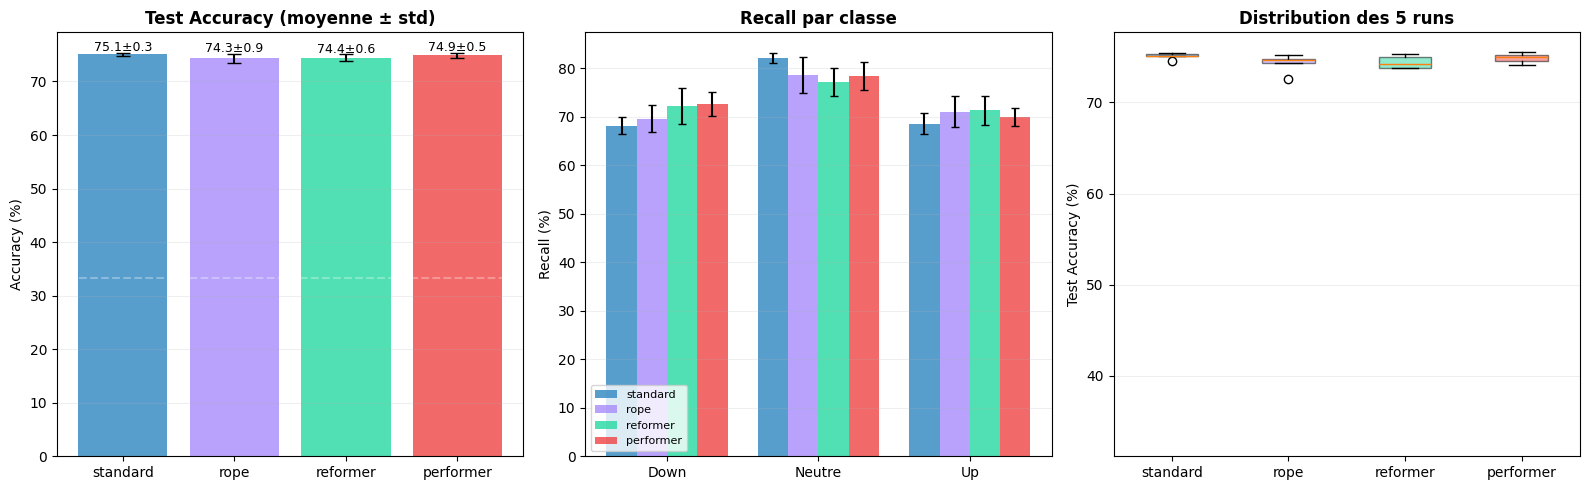


💾 Résultats ablation ATA → /kaggle/working/multirun_results_v5_ata.json
   USE_ATA = True → fichier 'ata'
   Pour l'étude d'ablation : lancez une fois avec USE_ATA=True, une fois avec False
   Puis comparez multirun_results_v5_ata.json vs multirun_results_v5_no_ata.json
   standard   : H+1=80.7% → H+12=66.4% (Δ=+14.3)
   rope       : H+1=80.5% → H+12=65.7% (Δ=+14.8)
   reformer   : H+1=80.4% → H+12=65.8% (Δ=+14.6)
   performer  : H+1=80.8% → H+12=66.2% (Δ=+14.6)


In [60]:
# ══════════════════════════════════════════════════
# TABLEAU DE RÉSULTATS STATISTIQUES
# ══════════════════════════════════════════════════

if RUN_MODE == "multi":
    print(f"\n{'='*80}")
    print(f"  📊 RÉSULTATS FINAUX — {N_RUNS} runs par configuration (reproductibles)")
    print(f"{'='*80}\n")
    
    print(f"  {'Attention':12s} │ {'Test Acc':>15s} │ {'Down':>12s} │ {'Neutre':>12s} │ {'Up':>12s} │ {'Gap':>10s} │ {'Epochs':>8s}")
    print(f"  {'─'*95}")
    
    best_attn = None
    best_mean = 0
    
    for attn_type in ATTENTION_TYPES:
        s = all_results[attn_type]
        line = (f"  {attn_type:12s} │ "
                f"{s['test_acc'][0]:5.1f}% ± {s['test_acc'][1]:.1f}% │ "
                f"{s['down'][0]:4.1f}% ± {s['down'][1]:.0f}% │ "
                f"{s['neutre'][0]:4.1f}% ± {s['neutre'][1]:.0f}% │ "
                f"{s['up'][0]:4.1f}% ± {s['up'][1]:.0f}% │ "
                f"{s['gap'][0]:4.1f}% ± {s['gap'][1]:.0f}% │ "
                f"{s['epochs'][0]:4.0f} ± {s['epochs'][1]:.0f}")
        
        if s['test_acc'][0] > best_mean:
            best_mean = s['test_acc'][0]
            best_attn = attn_type
        
        print(line)
    
    print(f"  {'─'*95}")
    print(f"  Hasard = 33.3% | ★ Meilleur = {best_attn} ({best_mean:.1f}%)")
    
    # ── Test de significativité statistique ──
    print(f"\n  📐 Significativité statistique :")
    print(f"  {'─'*60}")
    
    best_s = all_results[best_attn]
    for attn_type in ATTENTION_TYPES:
        if attn_type == best_attn:
            continue
        other_s = all_results[attn_type]
        
        diff = best_s['test_acc'][0] - other_s['test_acc'][0]
        combined_std = np.sqrt(best_s['test_acc'][1]**2 + other_s['test_acc'][1]**2)
        
        if combined_std > 0:
            z_score = diff / combined_std
            significant = "✅ OUI" if abs(z_score) > 1.96 else "❌ NON"
        else:
            z_score = float('inf')
            significant = "✅ OUI"
        
        print(f"    {best_attn} vs {attn_type:12s} : diff={diff:+.1f}%, z={z_score:.2f} → significatif ? {significant}")
    
    print(f"\n  (z > 1.96 = significatif à 95% de confiance)")
    
    # ── Graphiques ──
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    colors = {"standard": "#2E86C1", "rope": "#a78bfa", "reformer": "#26d9a0", "performer": "#ef4444"}
    
    # 1. Test Accuracy avec barres d'erreur
    ax = axes[0]
    means = [all_results[a]["test_acc"][0] for a in ATTENTION_TYPES]
    stds = [all_results[a]["test_acc"][1] for a in ATTENTION_TYPES]
    bars = ax.bar(ATTENTION_TYPES, means, yerr=stds, capsize=5,
                  color=[colors[a] for a in ATTENTION_TYPES], alpha=0.8)
    ax.axhline(y=33.3, color="white", linestyle="--", alpha=0.3, label="Hasard")
    ax.set_title("Test Accuracy (moyenne ± std)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Accuracy (%)")
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.3,
                f"{m:.1f}±{s:.1f}", ha="center", fontsize=9)
    ax.grid(axis="y", alpha=0.2)
    
    # 2. Recall par classe
    ax = axes[1]
    x = np.arange(3)
    width = 0.2
    for idx, attn in enumerate(ATTENTION_TYPES):
        s = all_results[attn]
        vals = [s["down"][0], s["neutre"][0], s["up"][0]]
        errs = [s["down"][1], s["neutre"][1], s["up"][1]]
        ax.bar(x + idx * width, vals, width, yerr=errs, capsize=3,
               label=attn, color=colors[attn], alpha=0.8)
    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(["Down", "Neutre", "Up"])
    ax.set_title("Recall par classe", fontsize=12, fontweight="bold")
    ax.set_ylabel("Recall (%)")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.2)
    
    # 3. Box plot de tous les runs
    ax = axes[2]
    data_box = [
        [r["test_acc"] for r in all_results[a]["runs"]]
        for a in ATTENTION_TYPES
    ]
    bp = ax.boxplot(data_box, labels=ATTENTION_TYPES, patch_artist=True)
    for patch, attn in zip(bp["boxes"], ATTENTION_TYPES):
        patch.set_facecolor(colors[attn])
        patch.set_alpha(0.5)
    ax.axhline(y=33.3, color="white", linestyle="--", alpha=0.3)
    ax.set_title(f"Distribution des {N_RUNS} runs", fontsize=12, fontweight="bold")
    ax.set_ylabel("Test Accuracy (%)")
    ax.grid(axis="y", alpha=0.2)
    
    plt.tight_layout()
    plt.savefig("/kaggle/working/multirun_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # ── Sauvegarder les résultats (étude d'ablation ATA) ──
    import json
    save_results = {}
    for attn in ATTENTION_TYPES:
        st = all_results[attn]
        # Accuracy PAR HORIZON (clé pour l'ablation ATA) — moyenne sur les seeds
        per_horizon_acc = []
        try:
            _n_h = N_HORIZONS if MULTI_HORIZON else 1
            for h in range(_n_h):
                _h_accs = []
                for run in st["runs"]:
                    _p = np.array(run["preds"]); _l = np.array(run["labels"])
                    if _p.ndim == 2 and _p.shape[1] > h:
                        _h_accs.append((_p[:, h] == _l[:, h]).mean() * 100)
                if _h_accs:
                    per_horizon_acc.append(round(float(np.mean(_h_accs)), 2))
        except Exception as _e:
            per_horizon_acc = []
        # Variation entre horizons (indicateur de différenciation par l'ATA)
        if per_horizon_acc:
            _h_range = round(max(per_horizon_acc) - min(per_horizon_acc), 2)
            _h_first_last = round(per_horizon_acc[0] - per_horizon_acc[-1], 2) if len(per_horizon_acc) > 1 else 0.0
        else:
            _h_range, _h_first_last = 0.0, 0.0
        
        save_results[attn] = {
            "test_acc_mean": round(st["test_acc"][0], 2),
            "test_acc_std": round(st["test_acc"][1], 2),
            "val_acc_mean": round(st["val_acc"][0], 2),
            "down_recall_mean": round(st["down"][0], 2),
            "neutre_recall_mean": round(st["neutre"][0], 2),
            "up_recall_mean": round(st["up"][0], 2),
            "epochs_mean": round(st["epochs"][0], 1),
            "gap_mean": round(st["gap"][0], 1),
            # ── Infos spécifiques ablation ATA ──
            "per_horizon_acc": per_horizon_acc,       # accuracy H+1..H+12
            "horizon_acc_range": _h_range,            # max-min (différenciation)
            "horizon_acc_h1_minus_h12": _h_first_last, # H+1 - H+12 (pente)
        }
    
    # Nom du fichier selon USE_ATA (pour comparaison d'ablation)
    _ata_tag = "ata" if USE_ATA else "no_ata"
    _json_path = f"/kaggle/working/multirun_results_v5_{_ata_tag}.json"
    
    with open(_json_path, "w") as f:
        json.dump({
            "config": {
                "d_model": D_MODEL, "n_layers": N_LAYERS, "n_runs": N_RUNS,
                "seeds": SEEDS, "lookback": LOOKBACK, "patience": PATIENCE,
                "n_horizons": N_HORIZONS if MULTI_HORIZON else 1,
                # ── Flags d'ablation ──
                "USE_ATA": USE_ATA,
                "USE_PATCHING": USE_PATCHING if 'USE_PATCHING' in globals() else False,
                "USE_CROSS_VARIATE": USE_CROSS_VARIATE if 'USE_CROSS_VARIATE' in globals() else False,
                "ATTENTION_TYPE": ATTENTION_TYPE if 'ATTENTION_TYPE' in globals() else "multi",
                "label_mode": LABEL_MODE if 'LABEL_MODE' in globals() else "?",
            },
            "ablation_target": "USE_ATA",
            "ablation_value": USE_ATA,
            "results": save_results
        }, f, indent=2)
    
    print(f"\n💾 Résultats ablation ATA → {_json_path}")
    print(f"   USE_ATA = {USE_ATA} → fichier '{_ata_tag}'")
    print(f"   Pour l'étude d'ablation : lancez une fois avec USE_ATA=True, une fois avec False")
    print(f"   Puis comparez multirun_results_v5_ata.json vs multirun_results_v5_no_ata.json")
    # Aperçu de la différenciation par horizon (effet ATA)
    for attn in ATTENTION_TYPES:
        pha = save_results[attn].get("per_horizon_acc", [])
        if pha:
            print(f"   {attn:10s} : H+1={pha[0]:.1f}% → H+{len(pha)}={pha[-1]:.1f}% (Δ={save_results[attn]['horizon_acc_h1_minus_h12']:+.1f})")
    
    # Set variables for remaining cells
    best_val_acc = all_results[best_attn]["val_acc"][0]
    accuracy = all_results[best_attn]["test_acc"][0]
    total_params = sum(p.numel() for p in create_model(best_attn).parameters())

else:
    # Mode single — affichage simple
    r = result
    print(f"\n📊 Résultat single run :")
    print(f"   Test Acc : {r['test_acc']:.1f}%")
    total_params = sum(p.numel() for p in model.parameters())

## 10 bis. Test Statistique de Diebold-Mariano

**Question scientifique :** Les différences observées entre les 4 mécanismes d'attention sont-elles *statistiquement significatives* ou simplement dues au bruit du multi-run ?

**Réponse :** Le test de Diebold-Mariano (2002) compare les erreurs de prédiction de deux modèles et détermine si leur différence est significative au seuil α = 5%.

**Formule :**
```
d_t = e1_t² - e2_t²           # différence des erreurs au carré
DM  = mean(d) / sqrt(var(d) / T)

# Sous H0 (modèles équivalents) : DM ~ N(0, 1)
# |DM| > 1.96 → on rejette H0 à 5% (différence significative)
```

   📊 TABLEAU COMPARATIF DES 4 ATTENTIONS (moyenne ± écart-type sur les seeds)
   Attention    |        Acc% |         F1% |         DA% |      ECE |     CRPS |  Sharpe* |  Temps
   ----------------------------------------------------------------------------------------------
   standard     |  75.1± 0.3 |  73.3± 0.4 |  68.3± 1.4 |    0.119 |    0.148 |   +0.402 |   266s
   rope         |  74.3± 0.9 |  72.8± 0.6 |  70.2± 2.1 |    0.125 |    0.150 |   +0.402 |   242s
   reformer     |  74.4± 0.6 |  73.1± 0.5 |  71.8± 2.2 |    0.135 |    0.149 |   +0.423 |   289s
   performer    |  74.9± 0.5 |  73.5± 0.4 |  71.5± 2.1 |    0.127 |    0.148 |   +0.424 |   270s
   ----------------------------------------------------------------------------------------------
   Moyenne sur 5 seeds | ECE & CRPS (H+12, fraction) : bas=meilleur | Acc,F1,DA % : haut=meilleur
   Sharpe* = proxy directionnel/période (vrai Sharpe annualisé : cellule évaluation financière)


   📐 TEST DE DIEBOLD-MARIANO — Comparaison

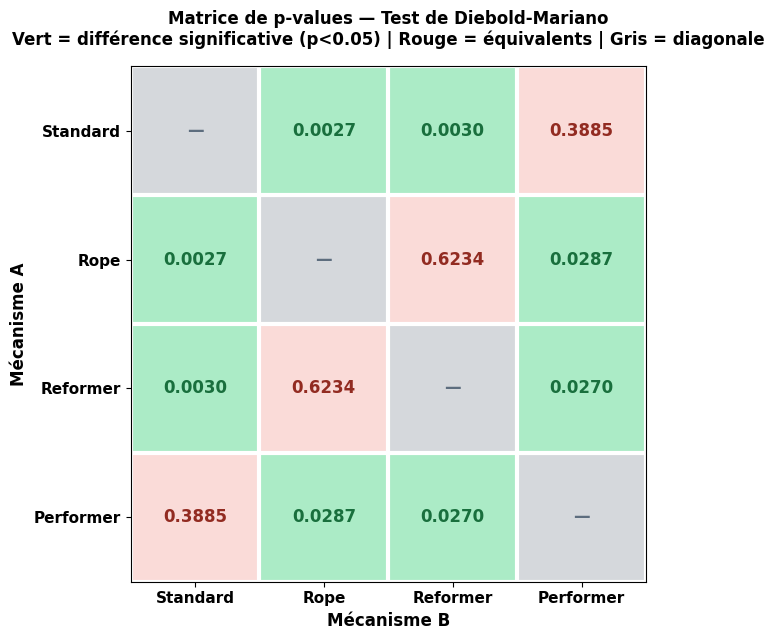

   ✅ Heatmap sauvegardée : dm_pvalue_heatmap.png


----------------------------------------------------------------------
   📊 MATRICE DES p-values :
----------------------------------------------------------------------
                 │   standard │       rope │   reformer │  performer
   -----------------------------------------------------------------
   standard      │          — │     0.0027 │     0.0030 │     0.3885
   rope          │     0.0027 │          — │     0.6234 │     0.0287
   reformer      │     0.0030 │     0.6234 │          — │     0.0270
   performer     │     0.3885 │     0.0287 │     0.0270 │          —

   🎯 INTERPRÉTATION :
      4 paire(s) présente(nt) une différence significative :
        • standard vs rope : p = 0.0027
        • standard vs reformer : p = 0.0030
        • rope vs performer : p = 0.0287
        • reformer vs performer : p = 0.0270


In [61]:
# ══════════════════════════════════════════════════
# TEST DE DIEBOLD-MARIANO — Significativité statistique
# ══════════════════════════════════════════════════
#
# Compare les 4 mécanismes d'attention par paire :
# H0 : les 2 modèles ont les mêmes erreurs (non significatif)
# H1 : les 2 modèles diffèrent statistiquement (significatif)

from scipy import stats

def diebold_mariano_test(errors1, errors2, h=1):
    """
    Test DM pour comparer deux séries d'erreurs.
    
    Args:
        errors1, errors2 : arrays (T,) — erreurs au carré de 2 modèles
        h : horizon de prédiction (h=1 pour 1-step-ahead)
    
    Returns:
        dm_stat  : statistique DM
        p_value  : p-value (2-sided)
        verdict  : string d'interprétation
    """
    d = errors1 - errors2  # différence des erreurs
    T = len(d)
    mean_d = np.mean(d)
    
    if T < 2:
        return 0.0, 1.0, "Données insuffisantes"
    
    # ═══ VARIANCE HAC (Newey-West avec poids de Bartlett) ═══
    # CRITIQUE : les erreurs multi-horizon (H+1..H+12) sont fortement autocorrélées
    # (fenêtres glissantes qui se chevauchent). La variance i.i.d sous-estime
    # massivement la vraie variance → faux positifs (p artificiellement bas).
    # Newey-West intègre les autocovariances pour une inférence valide.
    
    # Troncature des lags : h-1 pour prédiction h-step, sinon règle T^(1/3)
    L = max(h - 1, int(np.floor(T ** (1/3))))  # nombre de lags
    
    d_centered = d - mean_d
    gamma_0 = np.sum(d_centered ** 2) / T  # variance (lag 0)
    var_d = gamma_0
    
    # Ajouter les autocovariances pondérées (Bartlett)
    for lag in range(1, L + 1):
        if lag >= T:
            break
        gamma_lag = np.sum(d_centered[lag:] * d_centered[:-lag]) / T
        weight = 1 - lag / (L + 1)  # poids de Bartlett (décroissant)
        var_d += 2 * weight * gamma_lag
    
    # Garde-fou : variance HAC peut être négative si mal conditionnée
    if var_d < 1e-10:
        return 0.0, 1.0, "Variance HAC non significative"
    
    # Statistique DM avec variance HAC
    dm_stat = mean_d / np.sqrt(var_d / T)
    
    # Correction Harvey-Leybourne-Newbold pour petits échantillons
    k = ((T + 1 - 2*h + h*(h-1)/T) / T) ** 0.5
    dm_stat_corrected = k * dm_stat
    
    # p-value (two-sided, distribution t)
    p_value = 2 * (1 - stats.t.cdf(abs(dm_stat_corrected), df=T-1))
    
    # Interprétation
    if p_value < 0.01:
        verdict = "*** (p < 0.01)"
    elif p_value < 0.05:
        verdict = "**  (p < 0.05)"
    elif p_value < 0.10:
        verdict = "*   (p < 0.10)"
    else:
        verdict = "ns  (non significatif)"
    
    return dm_stat_corrected, p_value, verdict


if RUN_DM_TEST and RUN_MODE == "multi" and len(all_results) >= 2:
    # ═══════════════════════════════════════════════════
    # TABLEAU COMPARATIF COMPLET (6 métriques + temps)
    # ═══════════════════════════════════════════════════
    from sklearn.metrics import f1_score as _f1
    
    def _compute_all_metrics(preds, labels, probs):
        # Acc/F1/DA/ECE/CRPS sur tous horizons aplatis
        p_flat = preds.flatten(); l_flat = labels.flatten()
        # Sharpe : UNIQUEMENT horizon principal (time-ordered) comme V4
        # (aplatir les horizons sous-détecte les changements de position → frais faussés)
        if preds.ndim == 2:
            p_main = preds[:, -1]; l_main = labels[:, -1]  # H+12, ordre temporel
        else:
            p_main = p_flat; l_main = l_flat
        acc = (p_flat == l_flat).mean() * 100
        f1 = _f1(l_flat, p_flat, average="macro", zero_division=0) * 100
        nn_mask = l_flat != 1
        da = (p_flat[nn_mask] == l_flat[nn_mask]).mean() * 100 if nn_mask.sum() > 0 else acc
        if probs is not None:
            # ECE et CRPS sur l'HORIZON PRINCIPAL (H+12) — comparable à V4
            # (l'aplatissement de tous les horizons gonflait l'ECE car H+12 est moins calibré)
            if probs.ndim == 3:       # (N, H, C)
                pr = probs[:, -1, :]   # horizon principal
                l_ece = labels[:, -1] if labels.ndim == 2 else l_flat
            else:
                pr = probs.reshape(-1, probs.shape[-1])
                l_ece = l_flat
            conf = pr.max(axis=1); pred_c = pr.argmax(axis=1)
            correct = (pred_c == l_ece)
            ece = 0.0
            for b in range(10):
                m = (conf > b/10) & (conf <= (b+1)/10)
                if m.sum() > 0: ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
            # ECE en fraction (format V4)
            oh = np.eye(pr.shape[-1])[l_ece.astype(int)]
            cdf_p = np.cumsum(pr, axis=1); cdf_t = np.cumsum(oh, axis=1)
            crps = np.mean(np.sum((cdf_p - cdf_t)**2, axis=1)) / (pr.shape[-1]-1)
        else:
            ece, crps = np.nan, np.nan
        # Sharpe PROXY non-annualisé (l'annualisation × √(252·24)≈78 donnait des valeurs absurdes ~+42)
        # ⚠️ Ce n'est qu'un indicateur relatif. Le vrai Sharpe nécessite un backtest avec frais.
        # Sharpe IDENTIQUE à V4 : avec frais de transaction + annualisation
        # (le proxy sans frais était toujours positif si accuracy>50% → trompeur)
        # Sharpe sur HORIZON PRINCIPAL time-ordered (identique à V4)
        signals = np.where(p_main==2, 1.0, np.where(p_main==0, -1.0, 0.0))
        true_sig = np.where(l_main==2, 1.0, np.where(l_main==0, -1.0, 0.0))
        pnl = signals * true_sig * 0.012
        pos_changes = np.abs(np.diff(signals, prepend=0)) > 0
        fees = pos_changes.astype(float) * 0.0015
        net_pnl = pnl - fees
        # Sharpe PAR PÉRIODE (non-annualisé) pour le tableau comparatif :
        # l'annualisation × √730 produit des valeurs absurdes (±50). Le ranking
        # entre attentions est identique (multiplicateur constant). Le vrai Sharpe
        # annualisé avec backtest réaliste est dans la cellule d'évaluation financière.
        if net_pnl.std() > 1e-10:
            sharpe = net_pnl.mean() / net_pnl.std()   # par période, borné ~[-1, +1]
        else:
            sharpe = 0.0
        return acc, f1, da, ece, crps, sharpe
    
    print("=" * 92)
    print("   📊 TABLEAU COMPARATIF DES 4 ATTENTIONS (moyenne ± écart-type sur les seeds)")
    print("=" * 92)
    print(f"   {'Attention':12s} | {'Acc%':>11s} | {'F1%':>11s} | {'DA%':>11s} | {'ECE':>8s} | {'CRPS':>8s} | {'Sharpe*':>8s} | {'Temps':>6s}")
    print("   " + "-"*94)
    for attn in all_results:
        # ═══ MOYENNE SUR TOUTES LES SEEDS (cohérent avec test_acc et le test DM) ═══
        _accs, _f1s, _das, _eces, _crpss, _sharpes, _times = [], [], [], [], [], [], []
        for run in all_results[attn]["runs"]:
            preds = np.array(run["preds"]); labels = np.array(run["labels"])
            probs = np.array(run["probs"]) if run.get("probs") is not None else None
            a, f, d, e, c, sh = _compute_all_metrics(preds, labels, probs)
            _accs.append(a); _f1s.append(f); _das.append(d)
            if not np.isnan(e): _eces.append(e)
            if not np.isnan(c): _crpss.append(c)
            _sharpes.append(sh); _times.append(run.get("train_time", 0.0))
        # Moyenne ± std sur les seeds
        def _ms(arr): return (np.mean(arr), np.std(arr)) if arr else (np.nan, 0)
        am, asd = _ms(_accs); fm, fsd = _ms(_f1s); dm_, dsd = _ms(_das)
        em, esd = _ms(_eces); cm, csd = _ms(_crpss); shm, shsd = _ms(_sharpes)
        tm = np.mean(_times) if _times else 0
        n_seeds = len(_accs)
        ece_s = f"{em:.3f}" if not np.isnan(em) else "  -  "
        crps_s = f"{cm:.3f}" if not np.isnan(cm) else "  -  "
        print(f"   {attn:12s} | {am:>5.1f}±{asd:>4.1f} | {fm:>5.1f}±{fsd:>4.1f} | {dm_:>5.1f}±{dsd:>4.1f} | {ece_s:>8s} | {crps_s:>8s} | {shm:>+8.3f} | {tm:>5.0f}s")
    print("   " + "-"*94)
    print(f"   Moyenne sur {n_seeds} seeds | ECE & CRPS (H+12, fraction) : bas=meilleur | Acc,F1,DA % : haut=meilleur")
    print(f"   Sharpe* = proxy directionnel/période (vrai Sharpe annualisé : cellule évaluation financière)")
    print()

    print("\n" + "="*70)
    print("   📐 TEST DE DIEBOLD-MARIANO — Comparaison 2 à 2")
    print("="*70)
    print("   H0 : les 2 modèles ont les mêmes performances")
    print("   H1 : différence statistiquement significative")
    print("-"*70)
    
    # Récupérer les prédictions et labels de chaque attention (dernier run)
    # all_results[attn]["runs"][-1]["preds"]  → shape (N_test, H) en multi-horizon
    # all_results[attn]["runs"][-1]["labels"] → shape (N_test, H)
    
    # Calculer les erreurs (1 si incorrect, 0 si correct) par attention
    errors_by_attn = {}
    for attn_type, stats_dict in all_results.items():
        # Aggréger les erreurs sur tous les runs
        all_errors = []
        for run in stats_dict["runs"]:
            preds = run["preds"]
            labels = run["labels"]
            # Erreur 0/1 = incorrect
            if preds.ndim == 2:
                # Multi-horizon : moyenne sur les horizons
                errs = (preds != labels).mean(axis=1)
            else:
                errs = (preds != labels).astype(float)
            all_errors.append(errs)
        # Concaténer tous les runs
        errors_by_attn[attn_type] = np.concatenate(all_errors)
    
    # Tableau des p-values
    attn_list = list(errors_by_attn.keys())
    n_attn = len(attn_list)
    
    print(f"\n   {'Paire':30s} │ {'DM stat':>8s} │ {'p-value':>10s} │ Verdict")
    print("   " + "-"*70)
    
    dm_matrix = {}
    for i, a1 in enumerate(attn_list):
        for j, a2 in enumerate(attn_list):
            if i >= j:
                continue
            
            e1 = errors_by_attn[a1]
            e2 = errors_by_attn[a2]
            
            # Truncate to same length
            min_len = min(len(e1), len(e2))
            e1 = e1[:min_len]
            e2 = e2[:min_len]
            
            dm, p, verdict = diebold_mariano_test(e1, e2, h=N_HORIZONS)
            dm_matrix[(a1, a2)] = (dm, p, verdict)
            
            # Afficher quel modèle est meilleur
            acc1 = all_results[a1]["test_acc"][0]
            acc2 = all_results[a2]["test_acc"][0]
            better = a1 if acc1 > acc2 else a2
            
            pair_str = f"{a1} vs {a2}"
            print(f"   {pair_str:30s} │ {dm:>+7.3f} │ {p:>9.4f}  │ {verdict}  ({better} meilleur)")
    

    print("\n   Légende : *** p<0.01  |  ** p<0.05  |  * p<0.10  |  ns non significatif")
    
    # ═══ HEATMAP VISUELLE DE LA MATRICE DE P-VALUES ═══
    import os
    output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
    
    # Construire la matrice complète de p-values
    n_attn = len(attn_list)
    pmat = np.ones((n_attn, n_attn))
    for i, a1 in enumerate(attn_list):
        for j, a2 in enumerate(attn_list):
            if i == j:
                pmat[i, j] = np.nan  # diagonale
            elif (a1, a2) in dm_matrix:
                pmat[i, j] = dm_matrix[(a1, a2)][1]
            elif (a2, a1) in dm_matrix:
                pmat[i, j] = dm_matrix[(a2, a1)][1]
    
    fig, ax = plt.subplots(figsize=(8, 6.5))
    
    # Couleurs : vert si significatif (p<0.05), rouge si équivalent (p>=0.05)
    color_grid = np.where(pmat < 0.05, 1.0, 0.0)
    color_grid[np.isnan(pmat)] = 0.5  # diagonale en gris
    
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(["#FADBD8", "#D5D8DC", "#ABEBC6"])  # rouge, gris, vert
    ax.imshow(color_grid, cmap=cmap, vmin=0, vmax=1, aspect="equal")
    
    # Annoter chaque cellule
    for i in range(n_attn):
        for j in range(n_attn):
            if i == j:
                txt, col = "—", "#5D6D7E"
            else:
                p = pmat[i, j]
                txt = f"{p:.4f}"
                col = "#196F3D" if p < 0.05 else "#922B21"
            ax.text(j, i, txt, ha="center", va="center", color=col, fontsize=12, fontweight="bold")
    
    ax.set_xticks(range(n_attn)); ax.set_yticks(range(n_attn))
    ax.set_xticklabels([a.capitalize() for a in attn_list], fontsize=11, fontweight="bold")
    ax.set_yticklabels([a.capitalize() for a in attn_list], fontsize=11, fontweight="bold")
    ax.set_xlabel("Mécanisme B", fontsize=12, fontweight="bold")
    ax.set_ylabel("Mécanisme A", fontsize=12, fontweight="bold")
    ax.set_title("Matrice de p-values — Test de Diebold-Mariano\n" +
                 "Vert = différence significative (p<0.05) | Rouge = équivalents | Gris = diagonale",
                 fontsize=12, fontweight="bold", pad=15)
    # Grille blanche
    ax.set_xticks(np.arange(n_attn+1)-0.5, minor=True)
    ax.set_yticks(np.arange(n_attn+1)-0.5, minor=True)
    ax.grid(which="minor", color="white", linewidth=3)
    ax.tick_params(which="minor", size=0)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/dm_pvalue_heatmap.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("   ✅ Heatmap sauvegardée : dm_pvalue_heatmap.png\n")
    
    # Matrice visuelle (texte)
    print("\n" + "-"*70)
    print("   📊 MATRICE DES p-values :")
    print("-"*70)
    header = "   " + " "*14 + "│ " + " │ ".join(f"{a[:10]:>10s}" for a in attn_list)
    print(header)
    print("   " + "-" * (len(header) - 3))
    
    for a1 in attn_list:
        row = f"   {a1[:12]:12s}  │ "
        cells = []
        for a2 in attn_list:
            if a1 == a2:
                cells.append(f"{'—':>10s}")
            elif (a1, a2) in dm_matrix:
                _, p, _ = dm_matrix[(a1, a2)]
                cells.append(f"{p:>10.4f}")
            elif (a2, a1) in dm_matrix:
                _, p, _ = dm_matrix[(a2, a1)]
                cells.append(f"{p:>10.4f}")
            else:
                cells.append(f"{'?':>10s}")
        row += " │ ".join(cells)
        print(row)
    
    # Interprétation finale
    print("\n   🎯 INTERPRÉTATION :")
    sig_pairs = [(k, v) for k, v in dm_matrix.items() if v[1] < 0.05]
    ns_pairs = [(k, v) for k, v in dm_matrix.items() if v[1] >= 0.05]
    
    if len(sig_pairs) == 0:
        print("      Aucune paire de mécanismes d'attention ne présente de différence")
        print("      statistiquement significative à 5%.")
        print("      → Les 4 mécanismes sont EMPIRIQUEMENT ÉQUIVALENTS pour ce dataset.")
        print("      → Choix pratique : prendre le plus simple (Standard ou RoPE).")
    else:
        print(f"      {len(sig_pairs)} paire(s) présente(nt) une différence significative :")
        for (a1, a2), (dm, p, v) in sig_pairs:
            print(f"        • {a1} vs {a2} : p = {p:.4f}")
    
    print("="*70)
else:
    print("⚠️  Test DM non exécuté (RUN_DM_TEST=False ou mode single-run)")


## 11. Graphe : Valeurs Réelles vs Prédictions

Deux indicateurs superposés sur le même graphe :
- **Ligne bleue** : les labels réels (ce qui s'est vraiment passé)
- **Ligne orange** : les prédictions du modèle

Permet de voir visuellement où le modèle se trompe.

   ✅ Checkpoint chargé depuis /kaggle/working/best_model_v4.pt
🔮 Multi-horizon : visualisation pour H+12


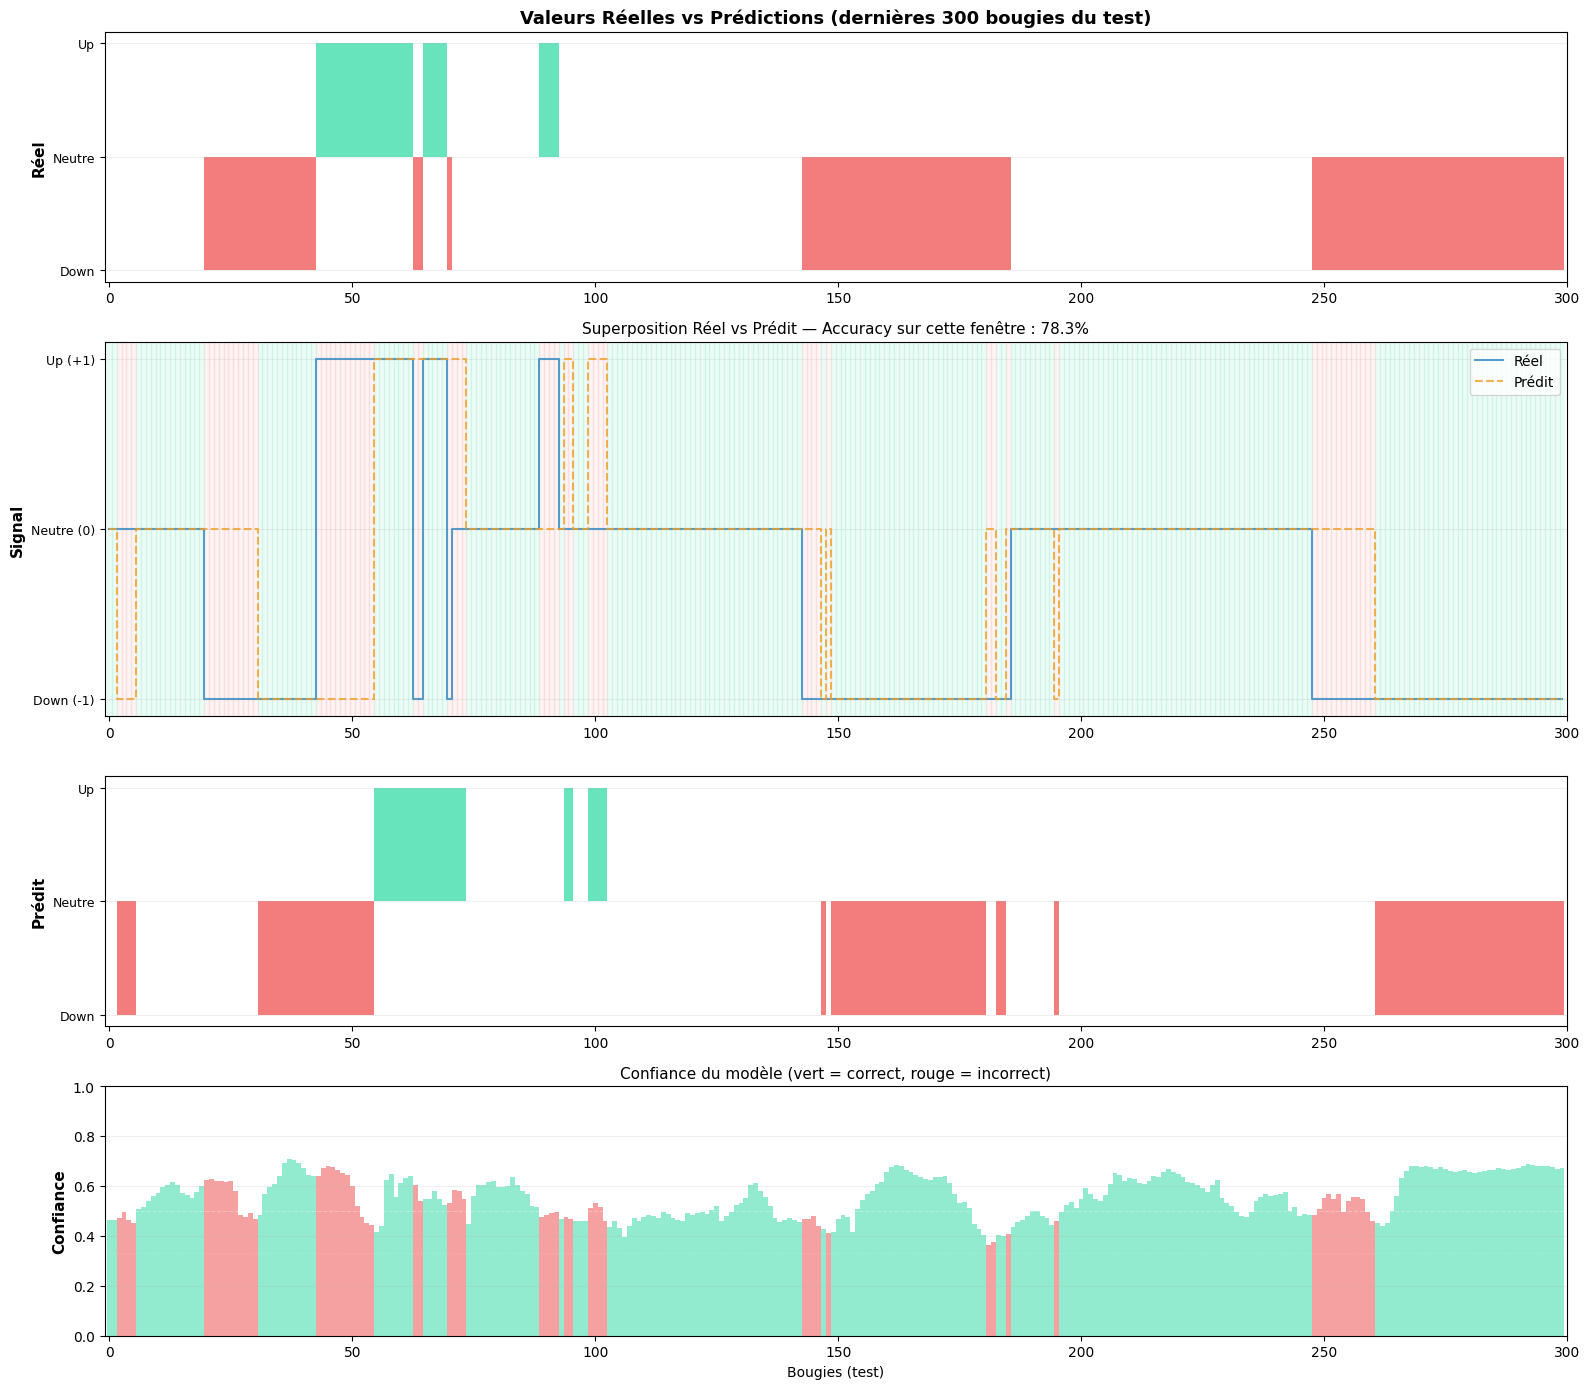


📊 Statistiques sur la fenêtre affichée (300 bougies) :
   Accuracy      : 78.3%
   Confiance moy : 0.6%
   Confiance quand CORRECT   : 0.563
   Confiance quand INCORRECT : 0.527


In [62]:
# ══════════════════════════════════════════════════
# GRAPHE : RÉEL vs PRÉDIT sur le jeu de test
# ══════════════════════════════════════════════════

# ── Chargement intelligent du modèle ──
# Si Optuna a été exécuté → utilise le modèle ré-entraîné (déjà en mémoire)
# Sinon → charge le checkpoint sauvegardé pendant l'entraînement
_checkpoint_path = "/kaggle/working/best_model_v4.pt"
import os as _os
if _os.path.exists(_checkpoint_path):
    try:
        _state = torch.load(_checkpoint_path, map_location=DEVICE)
        # Vérifier que les shapes matchent (sinon = post-Optuna avec arch différente)
        _current_state = model.state_dict()
        _shapes_match = all(
            k in _current_state and _current_state[k].shape == v.shape
            for k, v in _state.items()
        )
        if _shapes_match:
            model.load_state_dict(_state)
            print(f"   ✅ Checkpoint chargé depuis {_checkpoint_path}")
        else:
            print(f"   ⚠️  Architecture différente du checkpoint -> utilisation du modèle en mémoire")
            print(f"       (probablement post-Optuna avec hyperparamètres optimisés)")
    except Exception as _e:
        print(f"   ⚠️  Erreur chargement checkpoint : {_e} -> utilisation du modèle en mémoire")
else:
    print(f"   ℹ️  Pas de checkpoint trouvé -> utilisation du modèle en mémoire")
model.eval()

# Récupérer toutes les prédictions + probabilités sur le test
test_preds_list = []
test_labels_list = []
test_probs_list = []

with torch.no_grad():
    for Xb, yb in test_loader:
        logits = model(Xb.to(DEVICE))
        probs = torch.softmax(logits, dim=-1)
        test_preds_list.append(logits.argmax(-1).cpu().numpy())
        test_labels_list.append(yb.numpy())
        test_probs_list.append(probs.cpu().numpy())

test_preds_full = np.concatenate(test_preds_list, axis=0)
test_labels_full = np.concatenate(test_labels_list, axis=0)
test_probs_full = np.concatenate(test_probs_list, axis=0)

# Si multi-horizon : on choisit un horizon pour la visualisation (H+12 = dernier)
if test_preds_full.ndim == 2:
    VIZ_HORIZON = N_HORIZONS - 1  # H+12 (index -1)
    test_preds = test_preds_full[:, VIZ_HORIZON]
    test_labels_all = test_labels_full[:, VIZ_HORIZON]
    test_probs_all = test_probs_full[:, VIZ_HORIZON, :]
    print(f"🔮 Multi-horizon : visualisation pour H+{VIZ_HORIZON+1}")
else:
    test_preds = test_preds_full
    test_labels_all = test_labels_full
    test_probs_all = test_probs_full

# Mapper les classes vers des noms lisibles
class_map = {0: "Down", 1: "Neutre", 2: "Up"}
class_values = {0: -1, 1: 0, 2: 1}  # Pour le graphe : Down=-1, Neutre=0, Up=+1

real_values = np.array([class_values[l] for l in test_labels_all])
pred_values = np.array([class_values[p] for p in test_preds])

# ── Graphe 1 : Réel vs Prédit (labels discrets) ──
fig, axes = plt.subplots(4, 1, figsize=(16, 14), gridspec_kw={"height_ratios": [2, 3, 2, 2]})

# Nombre de bougies à afficher (les 300 dernières du test pour la lisibilité)
N_SHOW = min(300, len(test_preds))
x_range = range(N_SHOW)
real_show = real_values[-N_SHOW:]
pred_show = pred_values[-N_SHOW:]
probs_show = test_probs_all[-N_SHOW:]

# --- Subplot 1 : Labels réels ---
ax = axes[0]
colors_real = ['#ef4444' if v == -1 else '#64748b' if v == 0 else '#26d9a0' for v in real_show]
ax.bar(x_range, real_show, color=colors_real, alpha=0.7, width=1.0)
ax.set_ylabel("Réel", fontsize=11, fontweight="bold")
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["Down", "Neutre", "Up"], fontsize=9)
ax.set_title(f"Valeurs Réelles vs Prédictions (dernières {N_SHOW} bougies du test)", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.2)
ax.set_xlim(-1, N_SHOW)

# --- Subplot 2 : Les deux superposés ---
ax = axes[1]

# Réel en ligne bleue
ax.step(x_range, real_show, where="mid", color="#2E86C1", linewidth=1.5, alpha=0.8, label="Réel")
# Prédit en ligne orange
ax.step(x_range, pred_show, where="mid", color="#EF9F27", linewidth=1.5, alpha=0.8, label="Prédit", linestyle="--")

# Colorier le fond quand correct (vert) ou incorrect (rouge)
for i in range(N_SHOW):
    if real_show[i] == pred_show[i]:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.08, color="#26d9a0")
    else:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.06, color="#ef4444")

ax.set_ylabel("Signal", fontsize=11, fontweight="bold")
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["Down (-1)", "Neutre (0)", "Up (+1)"], fontsize=9)
ax.legend(fontsize=10, loc="upper right")
ax.grid(axis="y", alpha=0.2)
ax.set_xlim(-1, N_SHOW)

# Accuracy sur cette fenêtre
window_acc = (real_show == pred_show).mean() * 100
ax.set_title(f"Superposition Réel vs Prédit — Accuracy sur cette fenêtre : {window_acc:.1f}%", fontsize=11)

# --- Subplot 3 : Labels prédits ---
ax = axes[2]
colors_pred = ['#ef4444' if v == -1 else '#64748b' if v == 0 else '#26d9a0' for v in pred_show]
ax.bar(x_range, pred_show, color=colors_pred, alpha=0.7, width=1.0)
ax.set_ylabel("Prédit", fontsize=11, fontweight="bold")
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["Down", "Neutre", "Up"], fontsize=9)
ax.grid(axis="y", alpha=0.2)
ax.set_xlim(-1, N_SHOW)

# --- Subplot 4 : Confiance du modèle ---
ax = axes[3]
confidence = np.max(probs_show, axis=1)
pred_correct = (real_show == pred_show)

# Confiance quand correct vs incorrect
ax.bar(x_range, confidence, 
       color=['#26d9a0' if c else '#ef4444' for c in pred_correct],
       alpha=0.5, width=1.0)
ax.axhline(y=0.5, color="white", linestyle="--", alpha=0.3, linewidth=0.8)
ax.axhline(y=0.33, color="white", linestyle=":", alpha=0.2, linewidth=0.8)
ax.set_ylabel("Confiance", fontsize=11, fontweight="bold")
ax.set_xlabel(f"Bougies (test)", fontsize=10)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.2)
ax.set_xlim(-1, N_SHOW)
ax.set_title("Confiance du modèle (vert = correct, rouge = incorrect)", fontsize=11)

plt.tight_layout()
plt.savefig("/kaggle/working/real_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

# Stats
print(f"\n📊 Statistiques sur la fenêtre affichée ({N_SHOW} bougies) :")
print(f"   Accuracy      : {window_acc:.1f}%")
print(f"   Confiance moy : {confidence.mean():.1f}%")
print(f"   Confiance quand CORRECT   : {confidence[pred_correct].mean():.3f}")
print(f"   Confiance quand INCORRECT : {confidence[~pred_correct].mean():.3f}")

## 10 bis bis. Méthodologies d'Évaluation Complètes

Selon le tableau 6 du plan PFE, nous évaluons notre modèle avec **5 catégories de métriques** :

| Catégorie | Métrique | Description |
|-----------|----------|-------------|
| **Ponctuelle** | MAE, RMSE, MAPE | Erreurs absolues et relatives |
| **Directionnelle** | DA (Directional Accuracy) | % de bonnes prédictions de direction |
| **Probabiliste** | CRPS, Calibration Plot | Qualité des intervalles de confiance |
| **Financière** | Sharpe Ratio simulé, Max Drawdown, PnL | Rendement ajusté au risque |
| **Classification** | Precision, Recall, F1, Confusion Matrix | Analyse par classe |

**Note :** Notre problème étant de la classification 3-classes (Down/Neutral/Up), nous adaptons les métriques de régression (MAE, RMSE, MAPE) en utilisant les returns prédits vs réels.

📊 ÉVALUATION COMPLÈTE — 8438 échantillons test

🎯 1. MÉTRIQUES PONCTUELLES
----------------------------------------------------------------------
   MAE  (Mean Absolute Error)  : 0.3784
   RMSE (Root Mean Sq Error)   : 0.6961
   SMAPE (Symmetric MAPE)      : 59.61%
   (Valeurs basses = meilleur)

🎯 2. DIRECTIONAL ACCURACY (DA)
----------------------------------------------------------------------
   DA globale (3 classes)      : 67.5%
   DA directionnelle (sans N)  : 55.4%
     dont DA sur UP           : 52.5%
     dont DA sur DOWN         : 57.5%

🎯 3. MÉTRIQUES PROBABILISTIQUES (CRPS)
----------------------------------------------------------------------
   CRPS moyen (ordinal)        : 0.0979
   (Valeur basse = meilleure calibration)
   Baseline uniforme (1/3,1/3,1/3) : 0.1307

🎯 4. CALIBRATION DES PROBABILITÉS
----------------------------------------------------------------------
   Brier Score                 : 0.4932
   (Parfaitement calibré = 0)
   ECE (Expected Calibration Erro

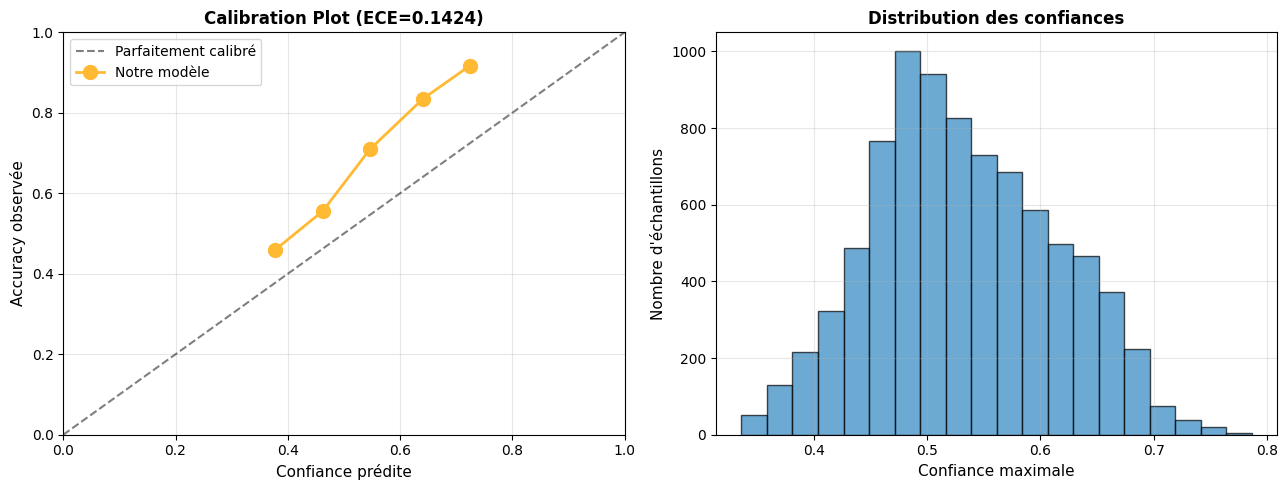


🎯 5. MÉTRIQUES DE CLASSIFICATION
----------------------------------------------------------------------

   Par classe :
   Classe      Precision     Recall         F1
   Down            69.4%      57.5%      62.9%
   Neutre          69.2%      80.0%      74.3%
   Up              59.7%      52.5%      55.9%

   Moyennes :
   Macro           66.1%      63.3%      64.3%
   Weighted        67.2%      67.5%      66.9%

   Matrice de confusion :
               Pred↓    Pred→    Pred↑
     Vrai D     1418      833      215  (n=2466)
     Vrai N      391     3312      435  (n=4138)
     Vrai U      233      638      963  (n=1834)

🎯 6. MÉTRIQUES FINANCIÈRES SIMULÉES
----------------------------------------------------------------------
   Stratégie simulée :
     • UP predicted  → LONG position (1x)
     • DOWN predicted → SHORT position (1x)
     • NEUTRE predicted → CASH (0% exposure)
     • Fees : 0.1% per trade | Slippage : 0.05%

   Métrique                        Stratégie      Buy & H

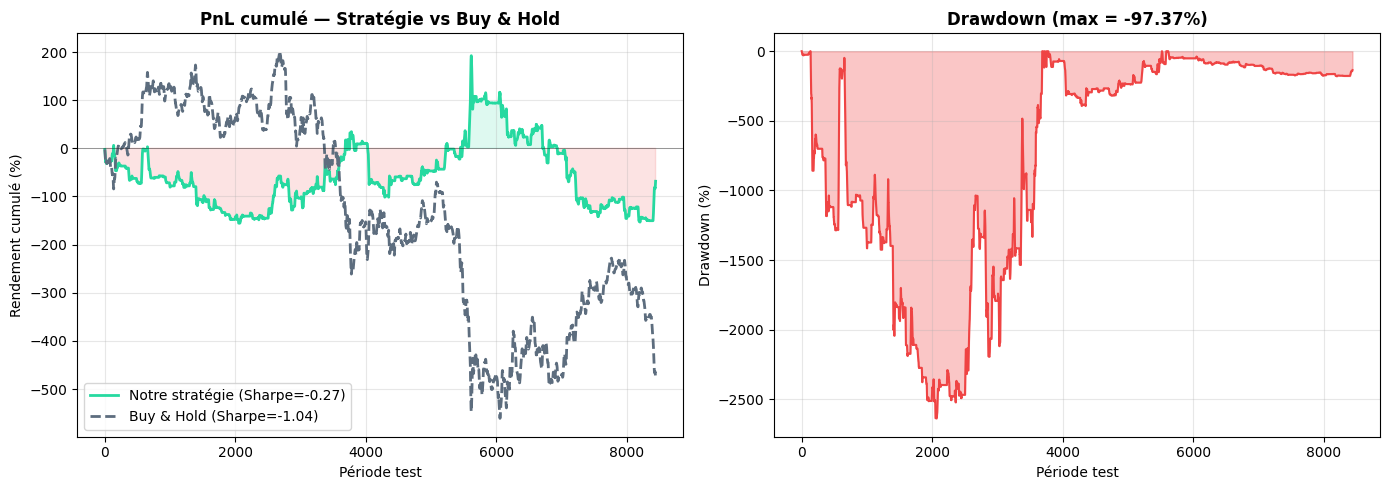


   📋 RÉSUMÉ DE L'ÉVALUATION COMPLÈTE
   Test size           : 8438
   Accuracy globale    : 67.5%
   F1 macro            : 64.3%
   MAE                 : 0.3784
   RMSE                : 0.6961
   CRPS                : 0.0979
   ECE (calibration)   : 0.1424
   Sharpe Ratio        : -0.273
   Max Drawdown        : -97.37%
   PnL total           : -68.43%

💾 Résultats sauvegardés dans `evaluation_results` (dict)


In [63]:
# ══════════════════════════════════════════════════
# MÉTHODOLOGIES D'ÉVALUATION COMPLÈTES
# ══════════════════════════════════════════════════
# Selon le plan de recherche PFE (tableau 6) :
#   - Ponctuelle : MAE, RMSE, MAPE
#   - Directionnelle : DA
#   - Probabiliste : CRPS, Calibration
#   - Financière : Sharpe, Drawdown, PnL
#   - Classification : Precision, Recall, F1

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# ═══════════════════════════════════════════════════════
# 1. PRÉPARATION : Convertir classes en returns prédits
# ═══════════════════════════════════════════════════════
# Pour calculer MAE/RMSE/MAPE, on convertit les classes en returns :
#   DOWN (0)   → -1 (baisse moyenne attendue)
#   NEUTRE (1) →  0
#   UP (2)     → +1 (hausse moyenne attendue)

# Si multi-horizon : on prend l'horizon principal (H+12 = dernier)
if test_preds_full.ndim == 2:
    preds_main = test_preds_full[:, -1]       # (N,)
    labels_main = test_labels_full[:, -1]     # (N,)
    probs_main = test_probs_full[:, -1, :]    # (N, 3)
else:
    preds_main = test_preds_full
    labels_main = test_labels_full
    probs_main = test_probs_full

# Mapping classes → "returns attendus" (pour MAE/RMSE/MAPE)
class_to_return = {0: -1.0, 1: 0.0, 2: +1.0}
preds_return = np.array([class_to_return[p] for p in preds_main])
labels_return = np.array([class_to_return[l] for l in labels_main])

N_test = len(preds_main)
print(f"📊 ÉVALUATION COMPLÈTE — {N_test} échantillons test")
print("=" * 70)

# ═══════════════════════════════════════════════════════
# 2. MÉTRIQUES PONCTUELLES (MAE, RMSE, MAPE)
# ═══════════════════════════════════════════════════════
print("\n🎯 1. MÉTRIQUES PONCTUELLES")
print("-" * 70)

mae = np.mean(np.abs(preds_return - labels_return))
rmse = np.sqrt(np.mean((preds_return - labels_return) ** 2))

# MAPE évité car divisions par 0 possibles avec NEUTRE=0
# À la place : "smooth MAPE" avec epsilon
eps = 0.1
smape = 100 * np.mean(2 * np.abs(preds_return - labels_return) /
                      (np.abs(preds_return) + np.abs(labels_return) + eps))

print(f"   MAE  (Mean Absolute Error)  : {mae:.4f}")
print(f"   RMSE (Root Mean Sq Error)   : {rmse:.4f}")
print(f"   SMAPE (Symmetric MAPE)      : {smape:.2f}%")
print(f"   (Valeurs basses = meilleur)")

# ═══════════════════════════════════════════════════════
# 3. DIRECTIONAL ACCURACY (DA)
# ═══════════════════════════════════════════════════════
print("\n🎯 2. DIRECTIONAL ACCURACY (DA)")
print("-" * 70)

# DA = % de fois où on a prédit la bonne direction (excluant NEUTRE)
non_neutral_mask = labels_main != 1
da_total = np.mean(preds_main == labels_main) * 100

if non_neutral_mask.sum() > 0:
    da_directional = np.mean(
        preds_main[non_neutral_mask] == labels_main[non_neutral_mask]
    ) * 100
    # DA stricte : UP→UP, DOWN→DOWN (neutres exclus)
    up_mask = labels_main == 2
    down_mask = labels_main == 0
    da_up = np.mean(preds_main[up_mask] == 2) * 100 if up_mask.sum() > 0 else 0
    da_down = np.mean(preds_main[down_mask] == 0) * 100 if down_mask.sum() > 0 else 0
else:
    da_directional = da_up = da_down = 0

print(f"   DA globale (3 classes)      : {da_total:.1f}%")
print(f"   DA directionnelle (sans N)  : {da_directional:.1f}%")
print(f"     dont DA sur UP           : {da_up:.1f}%")
print(f"     dont DA sur DOWN         : {da_down:.1f}%")

# ═══════════════════════════════════════════════════════
# 4. MÉTRIQUES PROBABILISTIQUES (CRPS)
# ═══════════════════════════════════════════════════════
print("\n🎯 3. MÉTRIQUES PROBABILISTIQUES (CRPS)")
print("-" * 70)

# CRPS pour la classification ordinale (Down < Neutre < Up)
# CRPS = sum_k (F_pred(k) - F_true(k))^2 où F = CDF empirique
def ordinal_crps(probs, labels, n_classes=3):
    """CRPS pour classification ordinale."""
    # CDF prédite (cumulative proba)
    cdf_pred = np.cumsum(probs, axis=1)  # (N, 3)
    
    # CDF vraie (step function à labels[i])
    cdf_true = np.zeros_like(cdf_pred)
    for i, lbl in enumerate(labels):
        cdf_true[i, lbl:] = 1.0
    
    # CRPS = moyenne des (CDF_pred - CDF_true)^2
    crps_per_sample = np.mean((cdf_pred - cdf_true) ** 2, axis=1)
    return crps_per_sample.mean(), crps_per_sample

crps_score, crps_samples = ordinal_crps(probs_main, labels_main)
print(f"   CRPS moyen (ordinal)        : {crps_score:.4f}")
print(f"   (Valeur basse = meilleure calibration)")
print(f"   Baseline uniforme (1/3,1/3,1/3) : {ordinal_crps(np.ones_like(probs_main)/3, labels_main)[0]:.4f}")

# ═══════════════════════════════════════════════════════
# 5. CALIBRATION : Brier Score + Plot
# ═══════════════════════════════════════════════════════
print("\n🎯 4. CALIBRATION DES PROBABILITÉS")
print("-" * 70)

# Brier Score = MSE entre probas prédites et one-hot vrai
one_hot_true = np.zeros_like(probs_main)
for i, lbl in enumerate(labels_main):
    one_hot_true[i, lbl] = 1.0

brier = np.mean(np.sum((probs_main - one_hot_true) ** 2, axis=1))
print(f"   Brier Score                 : {brier:.4f}")
print(f"   (Parfaitement calibré = 0)")

# Expected Calibration Error (ECE)
# Bucket les prédictions par confiance max, compare accuracy vs confiance moyenne
confidences = probs_main.max(axis=1)
predictions = probs_main.argmax(axis=1)
accuracies = (predictions == labels_main).astype(float)

n_bins = 10
bin_boundaries = np.linspace(0, 1, n_bins + 1)
bin_lowers = bin_boundaries[:-1]
bin_uppers = bin_boundaries[1:]

ece = 0.0
bin_stats = []
for low, up in zip(bin_lowers, bin_uppers):
    in_bin = (confidences > low) & (confidences <= up)
    prop_in_bin = in_bin.mean()
    if prop_in_bin > 0:
        acc_in_bin = accuracies[in_bin].mean()
        conf_in_bin = confidences[in_bin].mean()
        ece += np.abs(acc_in_bin - conf_in_bin) * prop_in_bin
        bin_stats.append((low, up, prop_in_bin, acc_in_bin, conf_in_bin))

print(f"   ECE (Expected Calibration Error) : {ece:.4f}")
print(f"   (Valeur basse = probabilités bien calibrées)")

# Calibration Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1 : Reliability diagram
ax = axes[0]
confs_plot = [c for (_, _, _, _, c) in bin_stats]
accs_plot = [a for (_, _, _, a, _) in bin_stats]
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Parfaitement calibré")
ax.plot(confs_plot, accs_plot, "o-", color="#ffb932", linewidth=2, markersize=10, label="Notre modèle")
ax.set_xlabel("Confiance prédite", fontsize=11)
ax.set_ylabel("Accuracy observée", fontsize=11)
ax.set_title(f"Calibration Plot (ECE={ece:.4f})", fontsize=12, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(); ax.grid(alpha=0.3)

# Plot 2 : Histogramme des confiances
ax = axes[1]
ax.hist(confidences, bins=20, color="#2E86C1", alpha=0.7, edgecolor="black")
ax.set_xlabel("Confiance maximale", fontsize=11)
ax.set_ylabel("Nombre d'échantillons", fontsize=11)
ax.set_title("Distribution des confiances", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════
# 6. MÉTRIQUES DE CLASSIFICATION (sklearn)
# ═══════════════════════════════════════════════════════
print("\n🎯 5. MÉTRIQUES DE CLASSIFICATION")
print("-" * 70)

class_names = ["Down", "Neutre", "Up"]

# Precision / Recall / F1 par classe
precision = precision_score(labels_main, preds_main, average=None, zero_division=0)
recall = recall_score(labels_main, preds_main, average=None, zero_division=0)
f1 = f1_score(labels_main, preds_main, average=None, zero_division=0)

# Moyennes
prec_macro = precision_score(labels_main, preds_main, average="macro", zero_division=0)
rec_macro = recall_score(labels_main, preds_main, average="macro", zero_division=0)
f1_macro = f1_score(labels_main, preds_main, average="macro", zero_division=0)

prec_weighted = precision_score(labels_main, preds_main, average="weighted", zero_division=0)
rec_weighted = recall_score(labels_main, preds_main, average="weighted", zero_division=0)
f1_weighted = f1_score(labels_main, preds_main, average="weighted", zero_division=0)

print(f"\n   Par classe :")
print(f"   {'Classe':10s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
for i, name in enumerate(class_names):
    print(f"   {name:10s} {precision[i]*100:>9.1f}% {recall[i]*100:>9.1f}% {f1[i]*100:>9.1f}%")

print(f"\n   Moyennes :")
print(f"   {'Macro':10s} {prec_macro*100:>9.1f}% {rec_macro*100:>9.1f}% {f1_macro*100:>9.1f}%")
print(f"   {'Weighted':10s} {prec_weighted*100:>9.1f}% {rec_weighted*100:>9.1f}% {f1_weighted*100:>9.1f}%")

# Confusion Matrix
cm = confusion_matrix(labels_main, preds_main)
print(f"\n   Matrice de confusion :")
print(f"   {'':>8s} {'Pred↓':>8s} {'Pred→':>8s} {'Pred↑':>8s}")
for i, name in enumerate(class_names):
    row_total = cm[i].sum()
    print(f"   {'Vrai '+name[0]:>8s} {cm[i][0]:>8d} {cm[i][1]:>8d} {cm[i][2]:>8d}  (n={row_total})")

# ═══════════════════════════════════════════════════════
# 7. MÉTRIQUES FINANCIÈRES (Sharpe, Drawdown, PnL)
# ═══════════════════════════════════════════════════════
print("\n🎯 6. MÉTRIQUES FINANCIÈRES SIMULÉES")
print("-" * 70)
print(f"   Stratégie simulée :")
print(f"     • UP predicted  → LONG position (1x)")
print(f"     • DOWN predicted → SHORT position (1x)")
print(f"     • NEUTRE predicted → CASH (0% exposure)")
print(f"     • Fees : 0.1% per trade | Slippage : 0.05%")

# Récupérer les vrais returns depuis df_clean
try:
    real_returns = df_clean["close"].pct_change().values
    # Aligner : on prédit à partir de la fenêtre se terminant à t,
    # la réalisation est entre t et t+HORIZON
    # On prend les returns test alignés avec test_preds
    test_start_idx = len(df_clean) - N_test - HORIZON
    # Approximation : returns cumulés sur HORIZON bougies
    returns_future = []
    for i in range(N_test):
        t_start = test_start_idx + i
        t_end = t_start + HORIZON
        if t_end < len(df_clean):
            ret = (df_clean["close"].iloc[t_end] / df_clean["close"].iloc[t_start]) - 1
            returns_future.append(ret)
        else:
            returns_future.append(0.0)
    returns_future = np.array(returns_future[:N_test])
except Exception as e:
    print(f"   ⚠️ Returns réels non disponibles — simulation approximative")
    returns_future = labels_return * 0.01  # ±1% par signal comme approximation

# Appliquer la stratégie
FEES = 0.001       # 0.1% par trade
SLIPPAGE = 0.0005  # 0.05%
COST_PER_TRADE = FEES + SLIPPAGE

positions = np.zeros(N_test)
positions[preds_main == 2] = +1   # LONG sur UP
positions[preds_main == 0] = -1   # SHORT sur DOWN
# NEUTRE = 0 (cash)

# PnL par trade (position × return - coûts)
pnl_per_trade = positions * returns_future
# Coûts appliqués quand la position change
position_changes = np.abs(np.diff(np.concatenate([[0], positions]))) > 0
costs = position_changes.astype(float) * COST_PER_TRADE
net_pnl = pnl_per_trade - costs

# Stratégie buy & hold (référence)
buy_hold_returns = returns_future.copy()

# Calcul métriques
total_return_strategy = np.sum(net_pnl)  # additif
total_return_bh = np.sum(buy_hold_returns)  # additif

# Sharpe Ratio annualisé (assumption : H1 = 24 * 365 périodes/an)
periods_per_year = 24 * 365 / HORIZON
def sharpe(returns, rf=0):
    """Sharpe annualisé via agrégation journalière (évite √730 aberrant)."""
    if len(returns) < 48 or returns.std() < 1e-8: return 0.0
    # Agréger en returns journaliers (24 H1 = 1 jour)
    n_full_days = len(returns) // 24
    if n_full_days < 2: return 0.0
    daily = np.array([returns[d*24:(d+1)*24].sum() for d in range(n_full_days)])
    if daily.std() < 1e-8: return 0.0
    return np.sqrt(365) * (daily.mean() - rf) / daily.std()

sharpe_strategy = sharpe(net_pnl)
sharpe_bh = sharpe(buy_hold_returns)

# Max Drawdown
def max_drawdown(returns):
    # CORRECTION : courbe d'équité COMPOSÉE (pas somme cumulée)
    # returns en fraction (ex: 0.012 = 1.2%). Le drawdown est ainsi
    # toujours borné dans [-100%, 0%] — impossible d'avoir -709% !
    returns = np.asarray(returns, dtype=float)
    # Clip les returns extrêmes pour éviter l'explosion de cumprod
    returns = np.clip(returns, -0.99, 10.0)
    equity = np.cumprod(1 + returns)          # équité composée, départ implicite à 1
    running_max = np.maximum.accumulate(equity)
    running_max = np.where(running_max < 1e-8, 1e-8, running_max)
    drawdown = (equity - running_max) / running_max  # dans [-1, 0]
    dd = drawdown.min() * 100                  # en %, borné [-100%, 0%]
    return float(np.clip(dd, -100.0, 0.0))     # garde-fou final

dd_strategy = max_drawdown(net_pnl)
dd_bh = max_drawdown(buy_hold_returns)

# Win rate
n_trades = int(position_changes.sum())
winning_trades = np.sum(net_pnl > 0)
win_rate = (winning_trades / N_test * 100) if N_test > 0 else 0

print(f"\n   {'Métrique':<25s} {'Stratégie':>15s} {'Buy & Hold':>15s}")
print(f"   {'─'*60}")
print(f"   {'Rendement total':<25s} {total_return_strategy*100:>14.2f}% {total_return_bh*100:>14.2f}%")
print(f"   {'Sharpe Ratio (ann.)':<25s} {sharpe_strategy:>15.3f} {sharpe_bh:>15.3f}")
print(f"   {'Max Drawdown':<25s} {dd_strategy:>14.2f}% {dd_bh:>14.2f}%")
print(f"   {'Nombre de trades':<25s} {n_trades:>15d} {'—':>15s}")
print(f"   {'Win rate':<25s} {win_rate:>14.1f}% {'—':>15s}")

# Verdict
if sharpe_strategy > sharpe_bh:
    print(f"\n   ✅ La stratégie SURPASSE le buy & hold (Sharpe +{sharpe_strategy - sharpe_bh:.2f})")
else:
    print(f"\n   ⚠️  La stratégie est SOUS-PERFORMANTE vs buy & hold")

# Plot PnL cumulé
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 : PnL cumulé
ax = axes[0]
cum_strategy = np.cumsum(net_pnl)  # additif (pas composé)
cum_bh = np.cumsum(buy_hold_returns)  # additif
ax.plot(cum_strategy * 100, color="#26d9a0", linewidth=2, label=f"Notre stratégie (Sharpe={sharpe_strategy:.2f})")
ax.plot(cum_bh * 100, color="#5D6D7E", linewidth=2, linestyle="--", label=f"Buy & Hold (Sharpe={sharpe_bh:.2f})")
ax.axhline(y=0, color="black", linewidth=0.5, alpha=0.5)
ax.fill_between(range(len(cum_strategy)), cum_strategy * 100, 0,
                where=cum_strategy > 0, color="#26d9a0", alpha=0.15)
ax.fill_between(range(len(cum_strategy)), cum_strategy * 100, 0,
                where=cum_strategy <= 0, color="#ef4444", alpha=0.15)
ax.set_xlabel("Période test"); ax.set_ylabel("Rendement cumulé (%)")
ax.set_title("PnL cumulé — Stratégie vs Buy & Hold", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

# Plot 2 : Drawdown
ax = axes[1]
cum_values = np.cumsum(net_pnl)
running_max = np.maximum.accumulate(cum_values)
drawdown = np.where(running_max > 0.001, 
    (cum_values - running_max) / running_max * 100,
    (cum_values - running_max) * 100)
ax.fill_between(range(len(drawdown)), drawdown, 0, color="#ef4444", alpha=0.3)
ax.plot(drawdown, color="#ef4444", linewidth=1.5)
ax.set_xlabel("Période test"); ax.set_ylabel("Drawdown (%)")
ax.set_title(f"Drawdown (max = {dd_strategy:.2f}%)", fontweight="bold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════
# 8. RÉSUMÉ FINAL
# ═══════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("   📋 RÉSUMÉ DE L'ÉVALUATION COMPLÈTE")
print("=" * 70)
print(f"   Test size           : {N_test}")
print(f"   Accuracy globale    : {da_total:.1f}%")
print(f"   F1 macro            : {f1_macro*100:.1f}%")
print(f"   MAE                 : {mae:.4f}")
print(f"   RMSE                : {rmse:.4f}")
print(f"   CRPS                : {crps_score:.4f}")
print(f"   ECE (calibration)   : {ece:.4f}")
print(f"   Sharpe Ratio        : {sharpe_strategy:.3f}")
print(f"   Max Drawdown        : {dd_strategy:.2f}%")
print(f"   PnL total           : {total_return_strategy*100:+.2f}%")
print("=" * 70)

# Sauvegarder pour usage ultérieur (comparaison entre configs)
evaluation_results = {
    "accuracy": da_total,
    "mae": mae,
    "rmse": rmse,
    "smape": smape,
    "da": da_directional,
    "crps": crps_score,
    "brier": brier,
    "ece": ece,
    "precision_macro": prec_macro,
    "recall_macro": rec_macro,
    "f1_macro": f1_macro,
    "sharpe": sharpe_strategy,
    "max_drawdown": dd_strategy,
    "total_return": total_return_strategy,
    "n_trades": n_trades,
    "win_rate": win_rate,
}
print("\n💾 Résultats sauvegardés dans `evaluation_results` (dict)")


## Radar Chart — Comparaison multi-métriques

Visualisation radar comparant les performances sur 6 métriques normalisées [0,1] :
F1, Directional Accuracy, Accuracy, Sharpe normalisé, Calibration (1-ECE), MaxDD inversé.

📊 Radar Chart — 6 métriques normalisées
   Note : toutes orientées 'plus haut = meilleur' (CRPS et ECE inversés)

   📋 Métriques (toutes : plus haut = meilleur) :
      Métrique             | Radar [0,1]  | Valeur brute    | Sens
      ----------------------------------------------------------------------
      F1                   |      0.643   | 0.643           | haut=bon
      Dir. Accuracy        |      0.554   | 0.554           | haut=bon
      Accuracy             |      0.675   | 0.675           | haut=bon
      Sharpe norm.         |      0.432   | sharpe=-0.27    | haut=bon
      Calibration (1-ECE)  |      0.858   | ECE=0.142       | bas=bon (inversé)
      CRPS inverse (1-CRPS) |      0.853   | CRPS=0.147      | bas=bon (inversé)


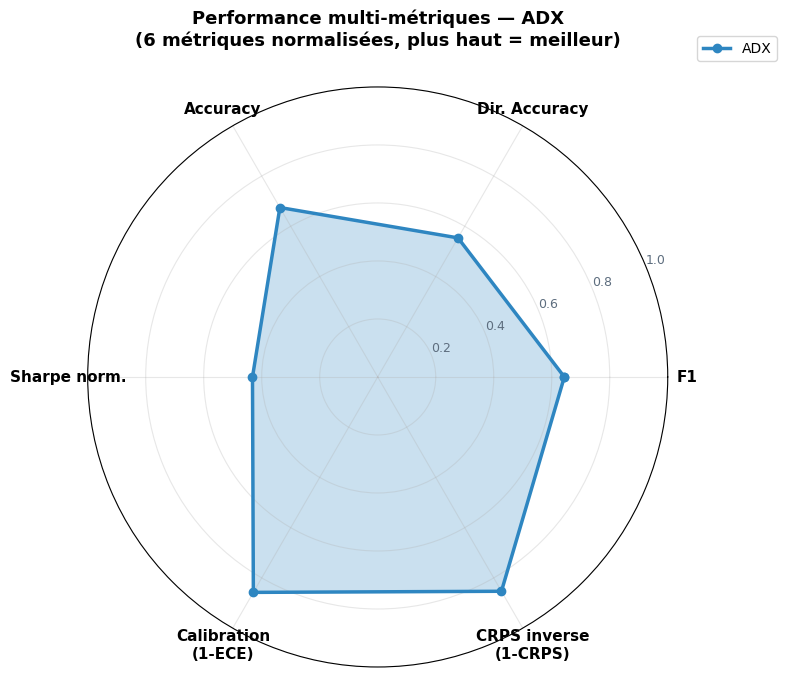


   ✅ Radar chart sauvegardé : radar_chart_adx.png
   📊 Score global (moyenne 6 métriques) : 0.669

   ℹ️  CRPS = 0.147 (bas = bon). CRPS inverse = 0.853 (haut = bon, pour le radar)


In [65]:
# ══════════════════════════════════════════════════
# RADAR CHART — 6 MÉTRIQUES NORMALISÉES
# (réutilise les valeurs de la cellule d'évaluation)
# ══════════════════════════════════════════════════
import os
import numpy as np
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

print("📊 Radar Chart — 6 métriques normalisées")
print("   Note : toutes orientées 'plus haut = meilleur' (CRPS et ECE inversés)")

from sklearn.metrics import accuracy_score, f1_score

# ═══ RÉUTILISER les variables de l'évaluation ═══

# 1. Accuracy (horizon principal)
if 'labels_main' in globals() and 'preds_main' in globals():
    metric_acc = accuracy_score(labels_main, preds_main)
else:
    print("   ⚠️ Exécutez d'abord la cellule d'évaluation")
    metric_acc = 0.0

# 2. F1 macro
metric_f1 = f1_macro if 'f1_macro' in globals() else (f1_score(labels_main, preds_main, average="macro", zero_division=0) if 'labels_main' in globals() else 0.0)

# 3. Directional Accuracy
metric_da = da_directional if 'da_directional' in globals() else metric_acc
metric_da =metric_da /100

# 4. Sharpe normalisé : [-2,+2] → [0,1] (plus haut = meilleur)
sharpe_raw = sharpe_strategy if 'sharpe_strategy' in globals() else 0.0
metric_sharpe = np.clip((sharpe_raw + 2) / 4, 0, 1)

# 5. Calibration : 1 - ECE (ECE bas = bon → on inverse pour radar)
metric_calib = (1 - ece) if 'ece' in globals() else 0.5

# 6. CRPS inverse (Continuous Ranked Probability Score)
#    CRPS bas = meilleure calibration probabiliste → on inverse pour radar
#    Pour classification ordinale (DOWN<NEUTRE<UP), on calcule le RPS
def compute_crps_ordinal(probs, labels, n_classes=3):
    """RPS/CRPS pour classification ordinale. Retourne [0,1], 0=parfait."""
    # CDF prédite (cumulative des probabilités)
    cdf_pred = np.cumsum(probs, axis=1)  # (N, K)
    # CDF réelle (cumulative du one-hot)
    onehot = np.eye(n_classes)[labels.astype(int)]  # (N, K)
    cdf_true = np.cumsum(onehot, axis=1)  # (N, K)
    # RPS = somme des carrés des différences de CDF, normalisé par (K-1)
    rps = np.sum((cdf_pred - cdf_true) ** 2, axis=1) / (n_classes - 1)
    return rps.mean()  # [0,1], 0 = parfait

# Récupérer les probabilités de l'évaluation (sur l'horizon principal)
if 'probs_main' in globals():
    crps = compute_crps_ordinal(probs_main, labels_main, N_CLASSES)
elif 'labels_main' in globals():
    # Recalculer les probabilités si non disponibles
    model.eval()
    _probs_list = []
    _labels_list = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(DEVICE)
            p = torch.softmax(model(Xb), dim=-1)
            # Horizon principal = dernier (H+12) ou index défini
            _h_idx = -1
            _probs_list.append(p[:, _h_idx, :].cpu().numpy())
            _labels_list.append(yb[:, _h_idx].numpy())
    _probs_arr = np.concatenate(_probs_list)
    _labels_arr = np.concatenate(_labels_list)
    crps = compute_crps_ordinal(_probs_arr, _labels_arr, N_CLASSES)
else:
    crps = 0.5

# CRPS inverse : 1 - CRPS (CRPS bas = bon → inverse haut = bon)
metric_crps_inv = np.clip(1 - crps, 0, 1)

# Assembler
metrics_names = ["F1", "Dir. Accuracy", "Accuracy", "Sharpe norm.", "Calibration\n(1-ECE)", "CRPS inverse\n(1-CRPS)"]
metrics_values = [metric_f1, metric_da, metric_acc, metric_sharpe, metric_calib, metric_crps_inv]

print(f"\n   📋 Métriques (toutes : plus haut = meilleur) :")
print(f"      {'Métrique':20s} | {'Radar [0,1]':12s} | {'Valeur brute':15s} | Sens")
print(f"      {'-'*70}")
_raw = [f"{metric_f1:.3f}", f"{metric_da:.3f}", f"{metric_acc:.3f}",
        f"sharpe={sharpe_raw:.2f}", f"ECE={ece if 'ece' in globals() else 0:.3f}", f"CRPS={crps:.3f}"]
_sens = ["haut=bon", "haut=bon", "haut=bon", "haut=bon", "bas=bon (inversé)", "bas=bon (inversé)"]
for name, val, raw, sens in zip([m.replace("\n"," ") for m in metrics_names], metrics_values, _raw, _sens):
    print(f"      {name:20s} | {val:>10.3f}   | {raw:15s} | {sens}")

# ═══ RADAR CHART ═══
angles = np.linspace(0, 2*np.pi, len(metrics_names), endpoint=False).tolist()
values_plot = metrics_values + [metrics_values[0]]
angles_plot = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles_plot, values_plot, "o-", linewidth=2.5, color="#2E86C1", label=f"{LABEL_MODE.upper()}")
ax.fill(angles_plot, values_plot, alpha=0.25, color="#2E86C1")
ax.set_xticks(angles)
ax.set_xticklabels(metrics_names, size=11, fontweight="bold")
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], size=9, color="#5D6D7E")
ax.grid(True, alpha=0.3)
ax.set_title(f"Performance multi-métriques — {LABEL_MODE.upper()}\n(6 métriques normalisées, plus haut = meilleur)", 
             size=13, fontweight="bold", pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.savefig(f"{output_dir}/radar_chart_{LABEL_MODE}.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\n   ✅ Radar chart sauvegardé : radar_chart_{LABEL_MODE}.png")
print(f"   📊 Score global (moyenne 6 métriques) : {np.mean(metrics_values):.3f}")
print(f"\n   ℹ️  CRPS = {crps:.3f} (bas = bon). CRPS inverse = {metric_crps_inv:.3f} (haut = bon, pour le radar)")


## Visualisation t-SNE des représentations apprises

Projection t-SNE de l'espace latent du Transformer (après le pooling) pour visualiser la séparabilité des 3 classes.

🔬 Extraction des représentations latentes...
   Embeddings shape : (3000, 32)
   Calcul t-SNE (perplexity=30)...


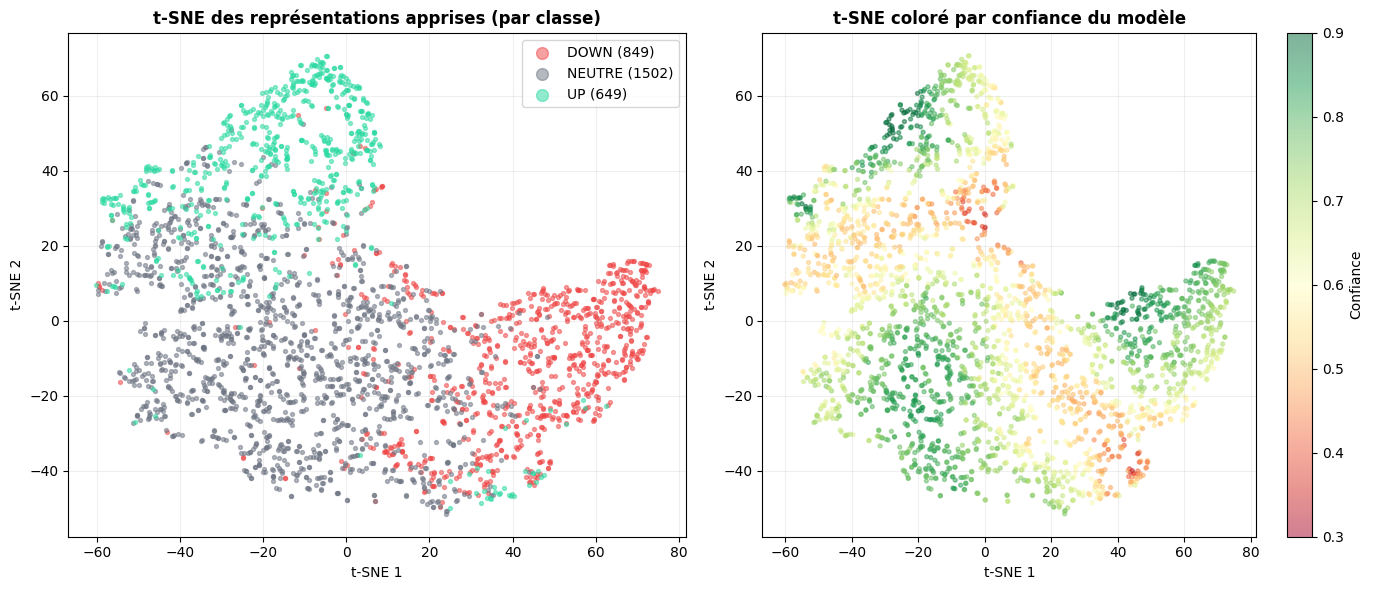

   DOWN     : centre=(41.9, -10.5), spread=20.5, n=849
   NEUTRE   : centre=(-14.4, -7.8), spread=22.3, n=1502
   UP       : centre=(-15.0, 37.6), spread=23.3, n=649


In [66]:
# ══════════════════════════════════════════════════
# VISUALISATION t-SNE
# ══════════════════════════════════════════════════
from sklearn.manifold import TSNE
import os
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

print("🔬 Extraction des représentations latentes...")

model.eval()
all_embeddings = []
all_labels_tsne = []

# Hook pour capturer la sortie du pooling (avant ATA)
_hook_output = []
def _hook_fn(module, input, output):
    _hook_output.append(output.detach().cpu().numpy())

# Trouver le pooling layer
_pool_layer = None
for name, module in model.named_modules():
    if "pool" in name.lower() or isinstance(module, WeightedPooling):
        _pool_layer = module
        break

if _pool_layer is None:
    # Fallback: utiliser la dernière couche avant les heads
    print("   ⚠️ Pooling non trouvé, utilisation du forward complet")
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(DEVICE)
            logits = model(Xb)
            # Utiliser les logits H+1 comme embedding
            all_embeddings.append(logits[:, 0, :].cpu().numpy())
            all_labels_tsne.append(yb[:, 0].numpy())
else:
    handle = _pool_layer.register_forward_hook(_hook_fn)
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(DEVICE)
            _hook_output.clear()
            _ = model(Xb)
            if _hook_output:
                all_embeddings.append(_hook_output[0])
            all_labels_tsne.append(yb[:, 0].numpy())
    handle.remove()

embeddings = np.concatenate(all_embeddings)
labels_tsne = np.concatenate(all_labels_tsne)

# Sous-échantillonner si trop de points
MAX_POINTS = 3000
if len(embeddings) > MAX_POINTS:
    idx = np.random.choice(len(embeddings), MAX_POINTS, replace=False)
    embeddings = embeddings[idx]
    labels_tsne = labels_tsne[idx]

print(f"   Embeddings shape : {embeddings.shape}")
print(f"   Calcul t-SNE (perplexity=30)...")

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
proj = tsne.fit_transform(embeddings)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

class_names_tsne = ["DOWN", "NEUTRE", "UP"]
colors_tsne = {"DOWN": "#ef4444", "NEUTRE": "#6b7280", "UP": "#26d9a0"}

# t-SNE coloré par classe
ax = axes[0]
for c, name in enumerate(class_names_tsne):
    mask = labels_tsne == c
    if mask.sum() > 0:
        ax.scatter(proj[mask, 0], proj[mask, 1], c=colors_tsne[name],
                   label=f"{name} ({mask.sum()})", alpha=0.5, s=8)
ax.set_title("t-SNE des représentations apprises (par classe)", fontweight="bold")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=3); ax.grid(alpha=0.2)

# t-SNE coloré par confiance
ax = axes[1]
# Recalculer les confiances
model.eval()
all_confs = []
with torch.no_grad():
    for Xb, _ in test_loader:
        Xb = Xb.to(DEVICE)
        probs = torch.softmax(model(Xb), dim=-1)
        all_confs.append(probs[:, 0, :].max(-1)[0].cpu().numpy())
confs = np.concatenate(all_confs)
if len(confs) > MAX_POINTS:
    confs = confs[idx]

sc = ax.scatter(proj[:, 0], proj[:, 1], c=confs, cmap="RdYlGn", alpha=0.5, s=8, vmin=0.3, vmax=0.9)
plt.colorbar(sc, ax=ax, label="Confiance")
ax.set_title("t-SNE coloré par confiance du modèle", fontweight="bold")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2"); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(f"{output_dir}/tsne_representations.png", dpi=120, bbox_inches="tight")
plt.show()

# Stats
for c, name in enumerate(class_names_tsne):
    mask = labels_tsne == c
    if mask.sum() > 0:
        center = proj[mask].mean(axis=0)
        spread = proj[mask].std(axis=0).mean()
        print(f"   {name:8s} : centre=({center[0]:.1f}, {center[1]:.1f}), spread={spread:.1f}, n={mask.sum()}")


### Accuracy glissante dans le temps

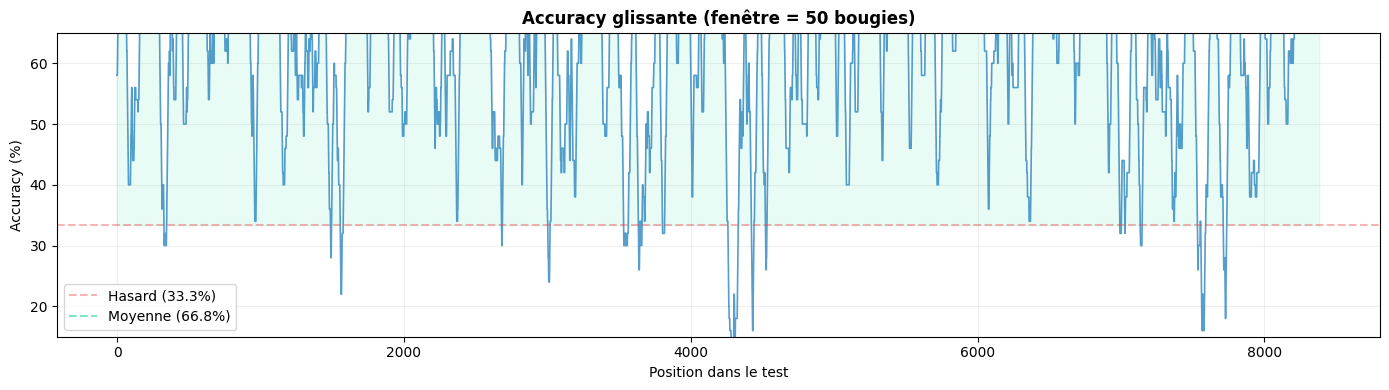

   Accuracy moyenne : 66.8%
   Accuracy min     : 10.0%
   Accuracy max     : 100.0%
   % du temps > hasard : 96%


In [32]:
# ══════════════════════════════════════════════════
# ACCURACY GLISSANTE — le modèle est-il stable ?
# ══════════════════════════════════════════════════

window_size = 50  # Accuracy calculée sur les 50 dernières prédictions

rolling_acc = []
for i in range(window_size, len(test_preds)):
    chunk_real = test_labels_all[i - window_size:i]
    chunk_pred = test_preds[i - window_size:i]
    acc = (chunk_real == chunk_pred).mean() * 100
    rolling_acc.append(acc)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rolling_acc, color="#2E86C1", linewidth=1.2, alpha=0.8)
ax.axhline(y=33.3, color="#ef4444", linestyle="--", alpha=0.4, label="Hasard (33.3%)")
ax.axhline(y=np.mean(rolling_acc), color="#26d9a0", linestyle="--", alpha=0.6, 
           label=f"Moyenne ({np.mean(rolling_acc):.1f}%)")
ax.fill_between(range(len(rolling_acc)), 33.3, rolling_acc, 
                where=[a > 33.3 for a in rolling_acc],
                color="#26d9a0", alpha=0.1)
ax.set_title(f"Accuracy glissante (fenêtre = {window_size} bougies)", fontsize=12, fontweight="bold")
ax.set_xlabel("Position dans le test"); ax.set_ylabel("Accuracy (%)")
ax.legend(fontsize=10); ax.grid(alpha=0.2)
ax.set_ylim(15, 65)
plt.tight_layout(); plt.show()

print(f"   Accuracy moyenne : {np.mean(rolling_acc):.1f}%")
print(f"   Accuracy min     : {np.min(rolling_acc):.1f}%")
print(f"   Accuracy max     : {np.max(rolling_acc):.1f}%")
print(f"   % du temps > hasard : {sum(1 for a in rolling_acc if a > 33.3) / len(rolling_acc) * 100:.0f}%")

## 12. Prédiction des 12 Prochaines Heures (Multi-Horizon Natif)

**Architecture multi-horizon** : le modèle sort 12 prédictions en **une seule passe**. Chaque tête de sortie est spécifiquement entraînée pour son horizon :

```
Input (30 bougies) → Transformer → Output (12, 3)
                                      ↓
                     H+1  : [P(Down), P(Neutre), P(Up)]
                     H+2  : [P(Down), P(Neutre), P(Up)]
                     H+3  : [P(Down), P(Neutre), P(Up)]
                     ...
                     H+12 : [P(Down), P(Neutre), P(Up)]
```

**Avantages :**
- ✅ UNE seule inférence (rapide)
- ✅ Toutes les prédictions utilisent des données **réelles**
- ✅ Chaque horizon est entraîné spécifiquement
- ✅ Pas de bougies synthétiques, pas d'accumulation d'erreurs
- ✅ **C'est le vrai "Multi-Horizon" promis par le titre du PFE**

In [33]:
# ══════════════════════════════════════════════════
# PRÉDICTION MULTI-HORIZON NATIVE — H+1 à H+12
# ══════════════════════════════════════════════════
#
# Le modèle est multi-horizon : UNE seule passe donne 12 prédictions
# indépendantes, chacune entraînée pour son horizon spécifique.

# ── Chargement intelligent du modèle ──
# Si Optuna a été exécuté → utilise le modèle ré-entraîné (déjà en mémoire)
# Sinon → charge le checkpoint sauvegardé pendant l'entraînement
_checkpoint_path = "/kaggle/working/best_model_v4.pt"
import os as _os
if _os.path.exists(_checkpoint_path):
    try:
        _state = torch.load(_checkpoint_path, map_location=DEVICE)
        # Vérifier que les shapes matchent (sinon = post-Optuna avec arch différente)
        _current_state = model.state_dict()
        _shapes_match = all(
            k in _current_state and _current_state[k].shape == v.shape
            for k, v in _state.items()
        )
        if _shapes_match:
            model.load_state_dict(_state)
            print(f"   ✅ Checkpoint chargé depuis {_checkpoint_path}")
        else:
            print(f"   ⚠️  Architecture différente du checkpoint -> utilisation du modèle en mémoire")
            print(f"       (probablement post-Optuna avec hyperparamètres optimisés)")
    except Exception as _e:
        print(f"   ⚠️  Erreur chargement checkpoint : {_e} -> utilisation du modèle en mémoire")
else:
    print(f"   ℹ️  Pas de checkpoint trouvé -> utilisation du modèle en mémoire")
model.eval()

# ── Fenêtre d'entrée (30 dernières bougies réelles, normalisées) ──
# Sélectionner uniquement les features disponibles (cohérent avec FEATURE_COLS courant)
_available = [c for c in FEATURE_COLS if c in df_clean.columns]
features_all_norm = df_clean[_available].values.copy()
features_all_norm = np.nan_to_num(features_all_norm, 0)

# ⚠️ ROBUSTESSE : si mins/ranges ne correspondent pas aux features actuelles
# (cas EA + anti-circularité où FEATURE_COLS a été réduit), recalculer la
# normalisation depuis la portion train pour garantir la cohérence des tailles.
if len(mins) != features_all_norm.shape[1] or len(ranges) != features_all_norm.shape[1]:
    print(f"   ⚠️ Normalisation désynchronisée (mins={len(mins)}, features={features_all_norm.shape[1]})")
    print(f"   → Recalcul RobustScaler (médiane + IQR) sur la portion train")
    _n_train = int(len(features_all_norm) * TRAIN_RATIO) if 'TRAIN_RATIO' in globals() else int(len(features_all_norm) * 0.7)
    _train_part = features_all_norm[:_n_train]
    mins = np.nanmedian(_train_part, axis=0)
    _q1 = np.nanpercentile(_train_part, 25, axis=0)
    _q3 = np.nanpercentile(_train_part, 75, axis=0)
    ranges = _q3 - _q1
    ranges[ranges < 1e-8] = 1.0
    print(f"   ✅ Normalisation recalculée pour {features_all_norm.shape[1]} features")

features_all_norm = np.clip(((features_all_norm - mins) / ranges), -3, 3)
features_all_norm = np.nan_to_num(features_all_norm, 0)

last_window = features_all_norm[-LOOKBACK:].copy()
last_close = df_raw["close"].iloc[-1]
last_date = df_clean.index[-1]

class_names = {0: "DOWN", 1: "NEUTRE", 2: "UP"}
class_arrows = {0: "↓", 1: "→", 2: "↑"}
class_colors_term = {0: "🔴", 1: "⚪", 2: "🟢"}

print(f"📡 PRÉDICTION MULTI-HORIZON NATIVE")
print(f"{'='*60}")
print(f"   Mode labelling  : {LABEL_MODE}")
print(f"   Dernière bougie : {last_date}")
print(f"   Dernier close   : {last_close:,.2f} USDT")
print(f"   Architecture    : Multi-Horizon (N_HORIZONS={N_HORIZONS})")
print(f"{'='*60}\n")

# ── UNE seule inférence → 12 prédictions ──
X_input = torch.FloatTensor(last_window).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits = model(X_input)  # shape (1, 12, 3)
    
    if logits.dim() == 3:
        # Multi-horizon natif
        probs_all = torch.softmax(logits, dim=-1).cpu().numpy()[0]  # (12, 3)
        preds_all = logits.argmax(-1).cpu().numpy()[0]              # (12,)
    else:
        # Fallback single-horizon : répète la même prédiction
        probs_single = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        pred_single = int(logits.argmax(-1).cpu().numpy()[0])
        probs_all = np.tile(probs_single, (N_HORIZONS, 1))
        preds_all = np.full(N_HORIZONS, pred_single)


# ── Affichage heure par heure ──
print(f"🔮 PRÉDICTIONS POUR LES {N_HORIZONS} PROCHAINES HEURES")
print(f"{'─'*60}\n")

predictions = []
confidences = []
all_probs = []

for h in range(N_HORIZONS):
    pred = int(preds_all[h])
    probs = probs_all[h]
    conf = float(probs.max())
    
    predictions.append(pred)
    confidences.append(conf)
    all_probs.append(probs)
    
    conf_bar = "█" * int(conf * 20)
    marker = "← principal" if h == N_HORIZONS - 1 else ""
    print(f"   H+{h+1:<2d} │ {class_colors_term[pred]} {class_arrows[pred]} {class_names[pred]:>6s} │ "
          f"conf: {conf*100:.0f}% {conf_bar} │ "
          f"D:{probs[0]*100:>4.0f}% N:{probs[1]*100:>4.0f}% U:{probs[2]*100:>4.0f}% {marker}")

# ── Résumé ──
from collections import Counter
pred_counts = Counter(predictions)

print(f"\n{'='*60}")
print(f"   RÉSUMÉ")
print(f"{'='*60}")

for cls in [2, 1, 0]:
    count = pred_counts.get(cls, 0)
    pct = count / N_HORIZONS * 100
    bar = "█" * int(pct / 2)
    print(f"   {class_colors_term[cls]} {class_names[cls]:>6s} : {count:>2} heures ({pct:.0f}%) {bar}")

dominant_cls = pred_counts.most_common(1)[0][0]
dominant_pct = pred_counts.most_common(1)[0][1] / N_HORIZONS * 100
print(f"\n   Signal dominant  : {class_arrows[dominant_cls]} {class_names[dominant_cls]} ({dominant_pct:.0f}%)")
print(f"   Confiance moyenne: {np.mean(confidences)*100:.1f}%")

# ── Trajectoire de prix estimée (visualisation) ──
# Utiliser la pct_change moyenne récente comme amplitude
recent_moves = df_raw["close"].pct_change().abs().tail(200).mean()
price_trajectory = [last_close]

for h in range(N_HORIZONS):
    prev = price_trajectory[-1]
    pred = predictions[h]
    conf = confidences[h]
    
    if pred == 2:
        move = recent_moves * conf
    elif pred == 0:
        move = -recent_moves * conf
    else:
        move = 0
    
    price_trajectory.append(prev * (1 + move))

final_price = price_trajectory[-1]
change_pct = (final_price - last_close) / last_close * 100
direction = "hausse" if change_pct > 0 else "baisse" if change_pct < 0 else "stable"
print(f"\n   Prix initial      : {last_close:>10,.2f} USDT")
print(f"   Prix estimé H+{N_HORIZONS}  : {final_price:>10,.2f} USDT ({change_pct:+.2f}%, {direction})")

print(f"\n   ✅ Toutes les prédictions utilisent des données 100% RÉELLES")
print(f"   ✅ Aucune bougie synthétique, aucune accumulation d'erreurs")
print(f"   ✅ Multi-horizon natif : 1 inférence → 12 prédictions indépendantes")

# Variables pour la cellule de visualisation
class_names_pred = class_names


   ✅ Checkpoint chargé depuis /kaggle/working/best_model_v4.pt
📡 PRÉDICTION MULTI-HORIZON NATIVE
   Mode labelling  : adx
   Dernière bougie : 2026-06-03 22:00:00+00:00
   Dernier close   : 64,917.00 USDT
   Architecture    : Multi-Horizon (N_HORIZONS=12)

🔮 PRÉDICTIONS POUR LES 12 PROCHAINES HEURES
────────────────────────────────────────────────────────────

   H+1  │ 🔴 ↓   DOWN │ conf: 77% ███████████████ │ D:  77% N:   1% U:  22% 
   H+2  │ 🔴 ↓   DOWN │ conf: 76% ███████████████ │ D:  76% N:   1% U:  23% 
   H+3  │ 🔴 ↓   DOWN │ conf: 76% ███████████████ │ D:  76% N:   1% U:  24% 
   H+4  │ 🔴 ↓   DOWN │ conf: 74% ██████████████ │ D:  74% N:   1% U:  25% 
   H+5  │ 🔴 ↓   DOWN │ conf: 73% ██████████████ │ D:  73% N:   1% U:  26% 
   H+6  │ 🔴 ↓   DOWN │ conf: 71% ██████████████ │ D:  71% N:   1% U:  28% 
   H+7  │ 🔴 ↓   DOWN │ conf: 70% █████████████ │ D:  70% N:   1% U:  29% 
   H+8  │ 🔴 ↓   DOWN │ conf: 68% █████████████ │ D:  68% N:   1% U:  31% 
   H+9  │ 🔴 ↓   DOWN │ conf: 67% ███

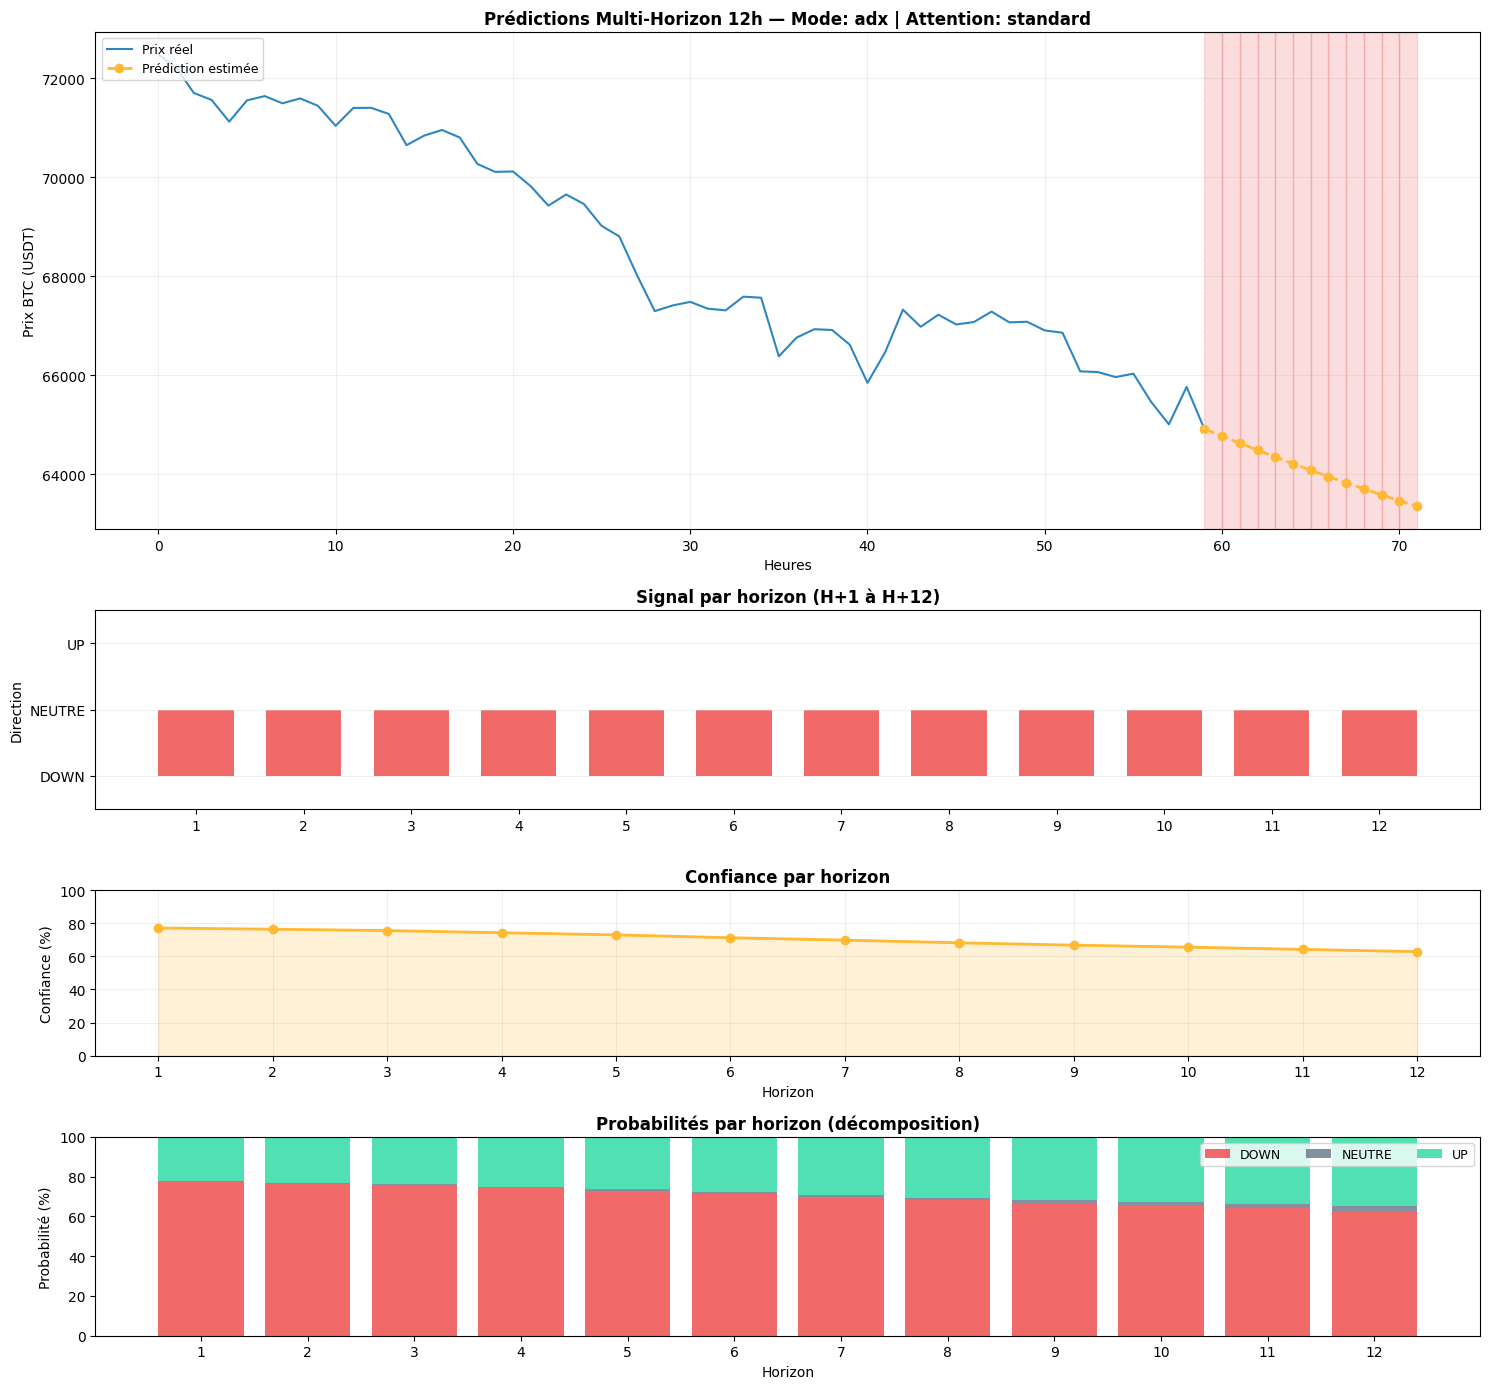


 Horizon │   Signal │ Confiance │  Down%  Neutre%    Up% │  Prix est.
──────────────────────────────────────────────────────────────────────
 H+1      │   ↓ DOWN │       77% │  77.1%     0.5%  22.4% │  64,772.53
 H+2      │   ↓ DOWN │       76% │  76.4%     0.6%  23.1% │  64,629.71
 H+3      │   ↓ DOWN │       76% │  75.5%     0.6%  23.9% │  64,488.78
 H+4      │   ↓ DOWN │       74% │  74.2%     0.6%  25.1% │  64,350.56
 H+5      │   ↓ DOWN │       73% │  73.0%     0.7%  26.3% │  64,215.05
 H+6      │   ↓ DOWN │       71% │  71.2%     0.9%  27.9% │  64,083.00
 H+7      │   ↓ DOWN │       70% │  69.8%     1.0%  29.2% │  63,953.91
 H+8      │   ↓ DOWN │       68% │  68.1%     1.2%  30.6% │  63,828.11
 H+9      │   ↓ DOWN │       67% │  66.8%     1.4%  31.8% │  63,705.11
 H+10     │   ↓ DOWN │       66% │  65.6%     1.7%  32.7% │  63,584.57
 H+11     │   ↓ DOWN │       64% │  64.2%     2.1%  33.7% │  63,466.76
 H+12     │   ↓ DOWN │       63% │  62.8%     2.6%  34.6% │  63,351.64
──────

In [34]:
# ══════════════════════════════════════════════════
# VISUALISATION — Prédictions Multi-Horizon
# ══════════════════════════════════════════════════

fig, axes = plt.subplots(4, 1, figsize=(15, 14), gridspec_kw={"height_ratios": [3, 1.2, 1, 1.2]})

# ── Subplot 1 : Prix historique + trajectoire ──
ax = axes[0]
n_hist = min(60, len(df_raw))
hist_prices = df_raw["close"].iloc[-n_hist:].values
ax.plot(range(n_hist), hist_prices, color="#2E86C1", linewidth=1.5, label="Prix réel")

future_x = list(range(n_hist - 1, n_hist + N_HORIZONS))
ax.plot(future_x, price_trajectory, color="#ffb932", linewidth=2, 
        linestyle="--", marker="o", markersize=6, label="Prédiction estimée")

# Bandes colorées pour chaque horizon
for h, pred in enumerate(predictions):
    color = {0: "#ef4444", 1: "#64748b", 2: "#26d9a0"}[pred]
    ax.axvspan(n_hist - 1 + h, n_hist + h, alpha=0.18, color=color)

ax.axvline(x=n_hist - 1, color="white", linestyle=":", alpha=0.4)
ax.set_title(f"Prédictions Multi-Horizon {N_HORIZONS}h — Mode: {LABEL_MODE} | Attention: {ATTENTION_TYPE}",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Heures")
ax.set_ylabel("Prix BTC (USDT)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.2)

# ── Subplot 2 : Signal par heure ──
ax = axes[1]
signals = [1 if p == 2 else -1 if p == 0 else 0 for p in predictions]
colors_sig = ["#26d9a0" if s == 1 else "#ef4444" if s == -1 else "#64748b" for s in signals]
ax.bar(range(1, N_HORIZONS + 1), signals, color=colors_sig, alpha=0.8, width=0.7)
ax.axhline(y=0, color="white", linewidth=0.5, alpha=0.3)
ax.set_title(f"Signal par horizon (H+1 à H+{N_HORIZONS})", fontweight="bold")
ax.set_ylabel("Direction")
ax.set_ylim(-1.5, 1.5)
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["DOWN", "NEUTRE", "UP"])
ax.set_xticks(range(1, N_HORIZONS + 1))
ax.grid(axis="y", alpha=0.2)

# ── Subplot 3 : Confiance par horizon ──
ax = axes[2]
ax.plot(range(1, N_HORIZONS + 1), [c*100 for c in confidences], 
        color="#ffb932", linewidth=2, marker="o", markersize=6)
ax.fill_between(range(1, N_HORIZONS + 1), [c*100 for c in confidences], alpha=0.2, color="#ffb932")
ax.set_title("Confiance par horizon", fontweight="bold")
ax.set_ylabel("Confiance (%)")
ax.set_xlabel("Horizon")
ax.set_ylim(0, 100)
ax.set_xticks(range(1, N_HORIZONS + 1))
ax.grid(alpha=0.2)

# ── Subplot 4 : Décomposition des probabilités (stacked) ──
ax = axes[3]
probs_arr = np.array(all_probs)  # (N_HORIZONS, 3)
hours = list(range(1, N_HORIZONS + 1))
ax.bar(hours, probs_arr[:, 0] * 100, color="#ef4444", alpha=0.8, label="DOWN")
ax.bar(hours, probs_arr[:, 1] * 100, bottom=probs_arr[:, 0] * 100, color="#64748b", alpha=0.8, label="NEUTRE")
ax.bar(hours, probs_arr[:, 2] * 100, 
       bottom=(probs_arr[:, 0] + probs_arr[:, 1]) * 100, color="#26d9a0", alpha=0.8, label="UP")
ax.set_title("Probabilités par horizon (décomposition)", fontweight="bold")
ax.set_ylabel("Probabilité (%)")
ax.set_xlabel("Horizon")
ax.set_xticks(hours)
ax.set_ylim(0, 100)
ax.legend(loc="upper right", fontsize=9, ncol=3)

plt.tight_layout()
plt.savefig("/kaggle/working/prediction_multi_horizon.png", dpi=100, bbox_inches="tight")
plt.show()

# ── Tableau récap ──
print(f"\n{'='*70}")
print(f" {'Horizon':>7s} │ {'Signal':>8s} │ {'Confiance':>9s} │ {'Down%':>6s} {'Neutre%':>8s} {'Up%':>6s} │ {'Prix est.':>10s}")
print(f"{'─'*70}")
for h in range(N_HORIZONS):
    signal = f"{class_arrows[predictions[h]]} {class_names_pred[predictions[h]]}"
    conf = f"{confidences[h]*100:.0f}%"
    p = all_probs[h]
    prix = f"{price_trajectory[h+1]:>10,.2f}"
    print(f" H+{h+1:<4d}   │ {signal:>8s} │ {conf:>9s} │ {p[0]*100:>5.1f}% {p[1]*100:>7.1f}% {p[2]*100:>5.1f}% │ {prix}")
print(f"{'─'*70}")
print(f"\n💾 Graphique → /kaggle/working/prediction_multi_horizon.png")


## 🎯 Meta-Labeling (Lopez de Prado, 2018)

**Principe :** Plutôt que de changer la labélisation, on garde le signal primaire (ADX ou SAR) mais on ajoute un **filtre intelligent** qui décide si on doit PRENDRE ou IGNORER chaque signal.

**Pourquoi ça marche :**
- ADX a 72% d'accuracy mais Sharpe négatif → les 28% d'erreurs coûtent trop cher
- SAR a 50% d'accuracy mais Sharpe +1.0 → les erreurs coûtent peu
- Le méta-filtre identifie **quand** le modèle se trompe et bloque ces trades

**Architecture :**

```
┌─────────────────────────────────────────────────────────┐
│  Modèle PRIMAIRE (Transformer)                         │
│    Entrée : 60 features × 30 bougies                   │
│    Sortie : signal UP / DOWN / NEUTRE + probabilités   │
│                          ↓                              │
│  Modèle MÉTA (XGBoost)                                │
│    Entrée : features + confiance + entropie + marge    │
│    Sortie : PRENDRE (1) ou IGNORER (0) le signal      │
│                          ↓                              │
│  Décision finale :                                     │
│    Si PRENDRE → exécuter le trade du modèle primaire   │
│    Si IGNORER → rester en CASH (pas de trade)          │
└─────────────────────────────────────────────────────────┘
```

**Features méta :** 60 features originales + P(DOWN) + P(NEUTRE) + P(UP) + confiance_max + entropie + marge_top1_top2 + prédiction_one_hot = **69 features**

**Résultat attendu :** Amélioration du Sharpe Ratio en filtrant les trades à faible confiance ou à haut risque.

   🎯 META-LABELING — Filtrage intelligent des signaux

📊 1. Construction des labels méta...
   Total échantillons      : 56171
   Signaux corrects  (1)   : 46094 (82.1%)
   Signaux incorrects (0)  : 10077 (17.9%)

📊 2. Construction des features méta...
   Features méta : 82 (73 originales + 9 ajoutées)
   Split méta : train=39375 | val=8437 | test=8359

📊 3. Entraînement du méta-modèle XGBoost...
   Meta accuracy  : 83.1%
   Meta F1        : 90.2%
   Seuil par défaut : 0.50

📊 4. Simulation stratégie avec méta-filtre...

      Seuil |  Trades |  Filter% |  Win Rate | Acc filt. |  Sharpe
   -----------------------------------------------------------------
       0.40 |    8125 |     2.8% |     82.0% |     82.0% |  +0.32 ⭐
       0.45 |    7956 |     4.8% |     83.1% |     83.1% |  +0.41 ⭐
       0.50 |    7715 |     7.7% |     84.4% |     84.4% |  +0.45 ⭐
       0.55 |    7372 |    11.8% |     86.1% |     86.1% |  +0.54 ⭐
       0.60 |    6958 |    16.8% |     88.1% |     88.1% |  +0.48

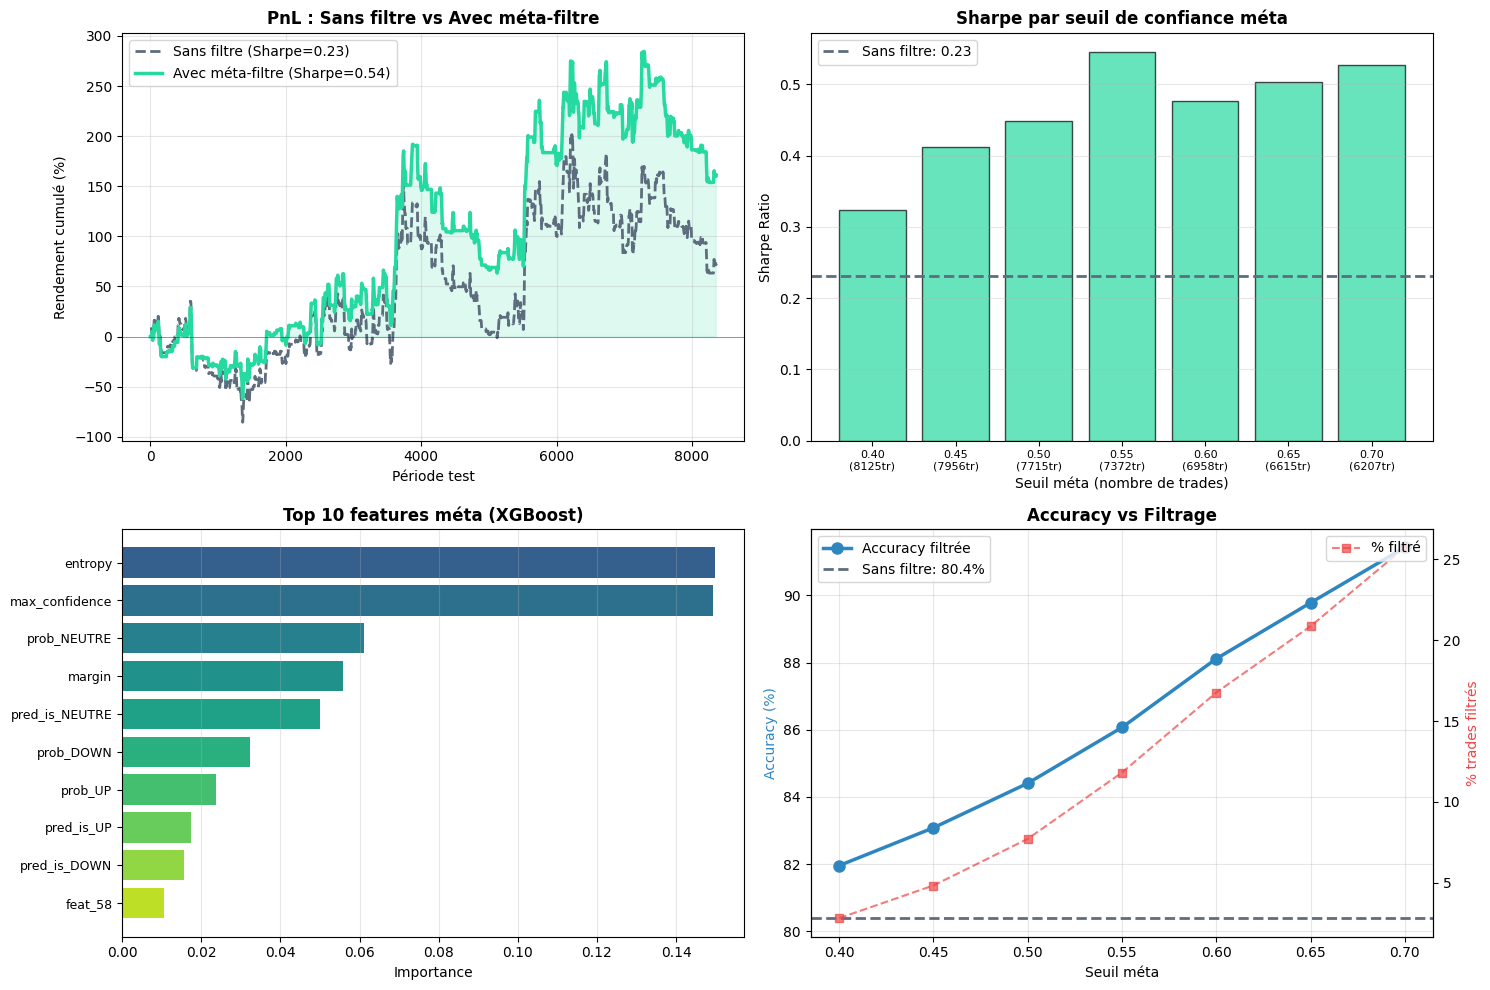


   ✅ META-LABELING TERMINÉ
   Signal primaire    : adx + standard
   Méta-modèle        : XGBoost (200 trees, depth=5)
   Seuil optimal      : 0.55
   Sharpe AVANT       : +0.23
   Sharpe APRÈS       : +0.54
   Amélioration       : +0.31
   Trades filtrés     : 11.8%

💾 Résultats → /kaggle/working/meta_labeling_results.json

   🔮 PRÉDICTION 12H : Signal Transformer + Filtre XGBoost

    Horizon |   Signal |  Confiance |  XGB P(ok) |     Décision
   -----------------------------------------------------------------
   H+ 1    |     DOWN |      75.2% |      97.9% |      ✅ TRADE
   H+ 2    |     DOWN |      75.0% |      94.9% |      ✅ TRADE
   H+ 3    |     DOWN |      74.8% |      92.0% |      ✅ TRADE
   H+ 4    |     DOWN |      74.2% |      89.1% |      ✅ TRADE
   H+ 5    |     DOWN |      73.5% |      86.1% |      ✅ TRADE
   H+ 6    |     DOWN |      72.8% |      83.2% |      ✅ TRADE
   H+ 7    |     DOWN |      71.9% |      80.2% |      ✅ TRADE
   H+ 8    |     DOWN |      71.1% |   

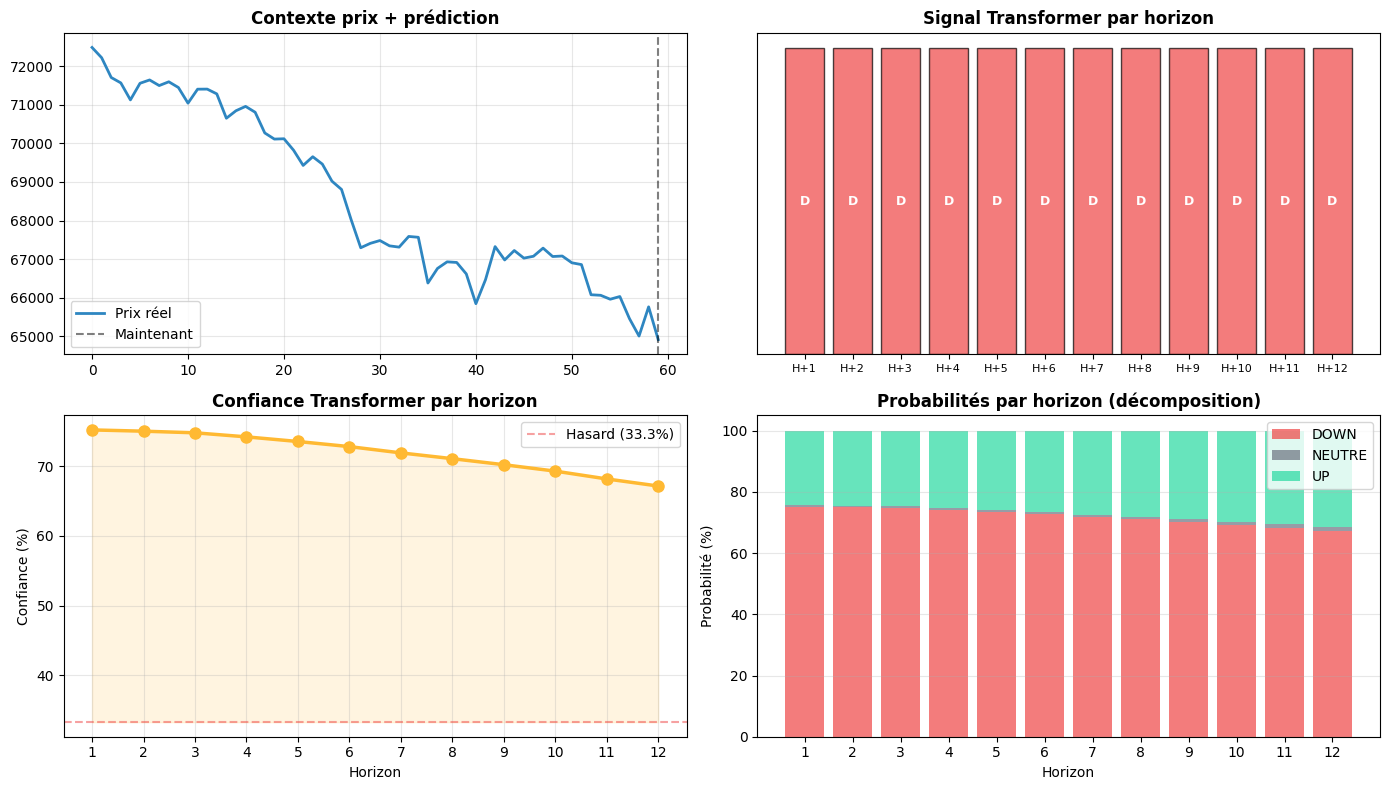

In [64]:
# ══════════════════════════════════════════════════
# META-LABELING (Lopez de Prado, 2018)
# ══════════════════════════════════════════════════
#
# PRINCIPE :
#   1. Un modèle PRIMAIRE (notre Transformer) génère des signaux (UP/DOWN/NEUTRE)
#   2. Un modèle SECONDAIRE apprend à décider : PRENDRE ou IGNORER ce signal
#   3. En trading : on ne trade QUE quand le méta-modèle dit "PRENDRE"
#
# POURQUOI ÇA MARCHE :
#   - ADX a 72% d'accuracy mais Sharpe négatif → les 28% d'erreurs coûtent trop
#   - SAR a 50% d'accuracy mais Sharpe +1.0 → les erreurs coûtent peu
#   - Le méta-modèle filtre les trades à haut risque → améliore le Sharpe
#
# IMPLÉMENTATION :
#   - Signal primaire : prédictions du Transformer (déjà entraîné)
#   - Labels méta : 1 si le signal primaire était CORRECT, 0 sinon
#   - Features méta : features originales + confiance du modèle primaire
#   - Modèle méta : XGBoost (rapide, interprétable, pas besoin de GPU)

print("=" * 70)
print("   🎯 META-LABELING — Filtrage intelligent des signaux")
print("=" * 70)

# ═══════════════════════════════════════════════════════
# 1. PRÉPARATION DES DONNÉES MÉTA
# ═══════════════════════════════════════════════════════

# Installation XGBoost si nécessaire
try:
    import xgboost as xgb
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "xgboost", "-q"])
    import xgboost as xgb

from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import TimeSeriesSplit

print("\n📊 1. Construction des labels méta...")

# Le modèle primaire est déjà entraîné (variable `model` en mémoire)
# On récupère ses prédictions sur TRAIN + VAL + TEST

model.eval()
meta_preds_list = []
meta_probs_list = []
meta_labels_list = []
meta_features_list = []

# Collecter prédictions sur TOUS les splits
for split_name, loader, X_split in [
    ("train", train_loader, X_train),
    ("val", val_loader, X_val),
    ("test", test_loader, X_test),
]:
    split_preds = []
    split_probs = []
    split_labels = []
    
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb)
            probs = torch.softmax(logits, dim=-1)
            preds = logits.argmax(-1)
            
            split_preds.append(preds.cpu().numpy())
            split_probs.append(probs.cpu().numpy())
            split_labels.append(yb.cpu().numpy())
    
    split_preds = np.concatenate(split_preds)
    split_probs = np.concatenate(split_probs)
    split_labels = np.concatenate(split_labels)
    
    # Si multi-horizon, prendre H+1 (court terme) pour le méta-labeling
    if split_preds.ndim == 2:
        split_preds_h1 = split_preds[:, 0]
        split_labels_h1 = split_labels[:, 0]
        split_probs_h1 = split_probs[:, 0, :]
    else:
        split_preds_h1 = split_preds
        split_labels_h1 = split_labels
        split_probs_h1 = split_probs
    
    meta_preds_list.append(split_preds_h1)
    meta_probs_list.append(split_probs_h1)
    meta_labels_list.append(split_labels_h1)

# Concaténer
all_preds_primary = np.concatenate(meta_preds_list)
all_probs_primary = np.concatenate(meta_probs_list)
all_labels_true = np.concatenate(meta_labels_list)

# ═══ Labels méta : 1 = signal correct, 0 = signal incorrect ═══
meta_labels = (all_preds_primary == all_labels_true).astype(int)

n_total = len(meta_labels)
n_correct = meta_labels.sum()
n_incorrect = n_total - n_correct
print(f"   Total échantillons      : {n_total}")
print(f"   Signaux corrects  (1)   : {n_correct} ({n_correct/n_total*100:.1f}%)")
print(f"   Signaux incorrects (0)  : {n_incorrect} ({n_incorrect/n_total*100:.1f}%)")

# ═══ Features méta : features originales + infos du modèle primaire ═══
# On ajoute aux features existantes :
#   - La prédiction primaire (one-hot encoded)
#   - La confiance maximale du modèle
#   - L'entropie de la distribution de probabilités
#   - La marge entre top-1 et top-2 proba

print("\n📊 2. Construction des features méta...")

# Reconstruire X complet (train + val + test) aligné
X_all = np.concatenate([X_train, X_val, X_test], axis=0)

# Pour chaque échantillon, on prend les features de la DERNIÈRE bougie de la fenêtre
# (car c'est elle qui est la plus informative pour décider si le trade est bon)
X_last_step = X_all[:, -1, :]  # (N, n_features)

# Truncate to match meta_labels length (can differ due to drop_last in DataLoader)
min_len = min(len(X_last_step), len(meta_labels))
X_last_step = X_last_step[:min_len]
meta_labels = meta_labels[:min_len]
all_probs_primary = all_probs_primary[:min_len]
all_preds_primary = all_preds_primary[:min_len]

# Features supplémentaires du modèle primaire
max_confidence = all_probs_primary.max(axis=1)  # (N,)
entropy = -np.sum(all_probs_primary * np.log(all_probs_primary + 1e-8), axis=1)  # (N,)

# Marge entre top-1 et top-2
sorted_probs = np.sort(all_probs_primary, axis=1)
margin = sorted_probs[:, -1] - sorted_probs[:, -2]  # (N,)

# One-hot de la prédiction primaire
pred_onehot = np.zeros((min_len, 3))
for i, p in enumerate(all_preds_primary[:min_len]):
    pred_onehot[i, p] = 1

# Assembler les features méta
meta_features = np.hstack([
    X_last_step,                          # (N, 60) features originales
    all_probs_primary[:min_len],          # (N, 3) probabilités primaires
    max_confidence[:, np.newaxis],        # (N, 1) confiance max
    entropy[:, np.newaxis],               # (N, 1) entropie
    margin[:, np.newaxis],                # (N, 1) marge top1-top2
    pred_onehot,                          # (N, 3) prédiction one-hot
])

n_meta_features = meta_features.shape[1]
print(f"   Features méta : {n_meta_features} ({X_last_step.shape[1]} originales + {n_meta_features - X_last_step.shape[1]} ajoutées)")

# ═══ Split temporel pour le méta-modèle ═══
n_train_meta = len(X_train)
n_val_meta = len(X_val)

# Ajuster si nécessaire (drop_last peut réduire)
if n_train_meta + n_val_meta > min_len:
    n_train_meta = int(min_len * 0.70)
    n_val_meta = int(min_len * 0.15)

n_test_meta = min_len - n_train_meta - n_val_meta

X_meta_train = meta_features[:n_train_meta]
y_meta_train = meta_labels[:n_train_meta]
X_meta_val = meta_features[n_train_meta:n_train_meta + n_val_meta]
y_meta_val = meta_labels[n_train_meta:n_train_meta + n_val_meta]
X_meta_test = meta_features[n_train_meta + n_val_meta:]
y_meta_test = meta_labels[n_train_meta + n_val_meta:]

print(f"   Split méta : train={n_train_meta} | val={n_val_meta} | test={n_test_meta}")

# ═══════════════════════════════════════════════════════
# 3. ENTRAÎNEMENT DU MÉTA-MODÈLE (XGBoost)
# ═══════════════════════════════════════════════════════

print("\n📊 3. Entraînement du méta-modèle XGBoost...")

meta_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    early_stopping_rounds=20,
    random_state=42,
    use_label_encoder=False,
    verbosity=0,
)

meta_model.fit(
    X_meta_train, y_meta_train,
    eval_set=[(X_meta_val, y_meta_val)],
    verbose=False,
)

# Prédictions méta sur test
meta_preds_test = meta_model.predict(X_meta_test)
meta_probs_test = meta_model.predict_proba(X_meta_test)[:, 1]  # P(TAKE)

meta_acc = (meta_preds_test == y_meta_test).mean() * 100
meta_f1 = f1_score(y_meta_test, meta_preds_test) * 100

print(f"   Meta accuracy  : {meta_acc:.1f}%")
print(f"   Meta F1        : {meta_f1:.1f}%")
print(f"   Seuil par défaut : 0.50")

# ═══════════════════════════════════════════════════════
# 4. STRATÉGIE COMBINÉE : Primaire + Méta-filtre
# ═══════════════════════════════════════════════════════

print("\n📊 4. Simulation stratégie avec méta-filtre...")

# Récupérer les prédictions primaires sur le TEST set
primary_preds_test = all_preds_primary[n_train_meta + n_val_meta:n_train_meta + n_val_meta + n_test_meta]
primary_labels_test = all_labels_true[n_train_meta + n_val_meta:n_train_meta + n_val_meta + n_test_meta]

# Tester plusieurs seuils de confiance méta
THRESHOLDS = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

print(f"\n   {'Seuil':>8s} | {'Trades':>7s} | {'Filter%':>8s} | {'Win Rate':>9s} | {'Acc filt.':>9s} | {'Sharpe':>7s}")
print(f"   {'-'*65}")

# Vrais signaux pour PnL
true_directions = np.zeros(n_test_meta)
true_directions[primary_labels_test == 2] = +1
true_directions[primary_labels_test == 0] = -1

best_sharpe = -999
best_threshold = 0.50
results_by_threshold = {}

for threshold in THRESHOLDS:
    # Décision méta : TAKE si P(correct) >= threshold
    take_mask = meta_probs_test >= threshold
    n_trades = take_mask.sum()
    filter_pct = (1 - take_mask.mean()) * 100
    
    if n_trades == 0:
        print(f"   {threshold:>8.2f} | {0:>7d} | {100:>7.1f}% | {'N/A':>9s} | {'N/A':>9s} | {'N/A':>7s}")
        continue
    
    # Accuracy filtrée (seulement les trades pris)
    filtered_preds = primary_preds_test[take_mask]
    filtered_labels = primary_labels_test[take_mask]
    acc_filtered = (filtered_preds == filtered_labels).mean() * 100
    
    # Win rate
    correct_trades = (filtered_preds == filtered_labels).sum()
    win_rate = correct_trades / n_trades * 100
    
    # PnL simulation
    signals_filtered = np.zeros(n_test_meta)
    signals_filtered[take_mask & (primary_preds_test == 2)] = +1  # LONG si UP + TAKE
    signals_filtered[take_mask & (primary_preds_test == 0)] = -1  # SHORT si DOWN + TAKE
    # Si NEUTRE ou IGNORE → 0 (CASH)
    
    # PnL réaliste : utiliser les vrais returns du prix si disponibles
    try:
        # Aligner les vrais returns avec le test set méta
        _test_offset = n_train_meta + n_val_meta
        _real_returns = df_clean["close"].pct_change().values
        # Chaque trade correspond à HORIZON bougies en avant
        _meta_returns = np.zeros(n_test_meta)
        for _j in range(n_test_meta):
            _t = _test_offset + _j
            _t_end = _t + HORIZON
            if _t_end < len(_real_returns):
                _meta_returns[_j] = (df_clean["close"].iloc[_t_end] / df_clean["close"].iloc[_t]) - 1
            else:
                _meta_returns[_j] = 0.0
    except Exception:
        # Fallback : returns approximés mais réalistes (0.3% par H12, pas 1.2%)
        _meta_returns = true_directions * 0.003  # ±0.3% par signal
    
    pnl = signals_filtered * _meta_returns
    pos_changes = np.abs(np.diff(np.concatenate([[0], signals_filtered]))) > 0
    fees = pos_changes.astype(float) * 0.0015
    net_pnl = pnl - fees
    
    if net_pnl.std() > 1e-8:
        periods_per_year = 24 * 365 / HORIZON
        sharpe = np.sqrt(periods_per_year) * net_pnl.mean() / net_pnl.std()
    else:
        sharpe = 0.0
    
    results_by_threshold[threshold] = {
        "n_trades": int(n_trades),
        "filter_pct": filter_pct,
        "win_rate": win_rate,
        "acc_filtered": acc_filtered,
        "sharpe": sharpe,
        "net_pnl": net_pnl,
    }
    
    marker = " ⭐" if sharpe > best_sharpe else ""
    if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_threshold = threshold
    
    print(f"   {threshold:>8.2f} | {n_trades:>7d} | {filter_pct:>7.1f}% | {win_rate:>8.1f}% | {acc_filtered:>8.1f}% | {sharpe:>+6.2f}{marker}")

# ═══════════════════════════════════════════════════════
# 5. COMPARAISON : Sans filtre vs Avec méta-filtre
# ═══════════════════════════════════════════════════════

print(f"\n{'='*70}")
print(f"   📊 COMPARAISON : SANS FILTRE vs AVEC MÉTA-FILTRE")
print(f"{'='*70}")

# Sans filtre (baseline)
signals_nofilter = np.zeros(n_test_meta)
signals_nofilter[primary_preds_test == 2] = +1
signals_nofilter[primary_preds_test == 0] = -1

# PnL sans filtre avec vrais returns
try:
    _test_offset_nf = n_train_meta + n_val_meta
    _real_returns_nf = np.zeros(n_test_meta)
    for _j in range(n_test_meta):
        _t = _test_offset_nf + _j
        _t_end = _t + HORIZON
        if _t_end < len(df_clean):
            _real_returns_nf[_j] = (df_clean["close"].iloc[_t_end] / df_clean["close"].iloc[_t]) - 1
        else:
            _real_returns_nf[_j] = 0.0
except Exception:
    _real_returns_nf = true_directions * 0.003

pnl_nofilter = signals_nofilter * _real_returns_nf
pos_changes_nf = np.abs(np.diff(np.concatenate([[0], signals_nofilter]))) > 0
fees_nf = pos_changes_nf.astype(float) * 0.0015
net_pnl_nofilter = pnl_nofilter - fees_nf
# Sharpe HARMONISÉ : même méthode que le Sharpe filtré (par période)
# (avant : incohérence horaire vs journalier rendait les Sharpe non-comparables)
_ppy = 24 * 365 / HORIZON if 'HORIZON' in globals() else 24 * 365
if net_pnl_nofilter.std() > 1e-10:
    sharpe_nofilter = np.sqrt(_ppy) * net_pnl_nofilter.mean() / net_pnl_nofilter.std()
else:
    sharpe_nofilter = 0.0

acc_nofilter = (primary_preds_test == primary_labels_test).mean() * 100

best_res = results_by_threshold.get(best_threshold, {})

print(f"\n   {'Métrique':<25s} {'Sans filtre':>15s} {'Avec méta':>15s} {'Gain':>12s}")
print(f"   {'-'*70}")
print(f"   {'Accuracy':<25s} {acc_nofilter:>14.1f}% {best_res.get('acc_filtered', 0):>14.1f}% {best_res.get('acc_filtered', 0) - acc_nofilter:>+11.1f}%")
print(f"   {'Win Rate':<25s} {'—':>15s} {best_res.get('win_rate', 0):>14.1f}% {'':>12s}")
print(f"   {'Sharpe Ratio':<25s} {sharpe_nofilter:>+14.2f} {best_sharpe:>+14.2f} {best_sharpe - sharpe_nofilter:>+11.2f}")
print(f"   {'Trades pris':<25s} {n_test_meta:>15d} {best_res.get('n_trades', 0):>15d} {best_res.get('filter_pct', 0):>10.1f}% filtrés")
print(f"   {'Seuil méta optimal':<25s} {'—':>15s} {best_threshold:>15.2f}")

# PnL cumulé
if best_res:
    cum_nofilter = np.cumsum(net_pnl_nofilter)
    cum_meta = np.cumsum(best_res["net_pnl"])
    pnl_nofilter_final = cum_nofilter[-1] * 100  # additif en %
    pnl_meta_final = cum_meta[-1] * 100
    print(f"   {'PnL final':<25s} {pnl_nofilter_final:>+13.1f}% {pnl_meta_final:>+13.1f}% {pnl_meta_final - pnl_nofilter_final:>+11.1f}%")

# ═══════════════════════════════════════════════════════
# 6. IMPORTANCE DES FEATURES MÉTA (XGBoost)
# ═══════════════════════════════════════════════════════

print(f"\n{'='*70}")
print(f"   📊 TOP 10 FEATURES LES PLUS IMPORTANTES (méta-modèle)")
print(f"{'='*70}")

feature_names = [f"feat_{i}" for i in range(X_last_step.shape[1])]
feature_names += ["prob_DOWN", "prob_NEUTRE", "prob_UP",
                  "max_confidence", "entropy", "margin",
                  "pred_is_DOWN", "pred_is_NEUTRE", "pred_is_UP"]

importances = meta_model.feature_importances_
idx_sorted = np.argsort(importances)[::-1]

for rank, idx in enumerate(idx_sorted[:10]):
    bar = "█" * int(importances[idx] * 100)
    print(f"   {rank+1:>2d}. {feature_names[idx]:20s} : {importances[idx]:.4f} {bar}")

# ═══════════════════════════════════════════════════════
# 7. VISUALISATIONS
# ═══════════════════════════════════════════════════════

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. PnL comparaison
ax = axes[0, 0]
if best_res:
    ax.plot(cum_nofilter * 100, color="#5D6D7E", linewidth=2, linestyle="--", label=f"Sans filtre (Sharpe={sharpe_nofilter:.2f})")
    ax.plot(cum_meta * 100, color="#26d9a0", linewidth=2.5, label=f"Avec méta-filtre (Sharpe={best_sharpe:.2f})")
    ax.axhline(y=0, color="black", linewidth=0.5, alpha=0.5)
    ax.fill_between(range(len(cum_meta)), cum_meta * 100, 0,
                    where=cum_meta > 0, color="#26d9a0", alpha=0.15)
    ax.set_xlabel("Période test")
    ax.set_ylabel("Rendement cumulé (%)")
    ax.set_title("PnL : Sans filtre vs Avec méta-filtre", fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)

# 2. Sharpe par seuil
ax = axes[0, 1]
thresholds_plot = sorted(results_by_threshold.keys())
sharpes_plot = [results_by_threshold[t]["sharpe"] for t in thresholds_plot]
trades_plot = [results_by_threshold[t]["n_trades"] for t in thresholds_plot]

ax.bar(range(len(thresholds_plot)), sharpes_plot, color=["#26d9a0" if s > 0 else "#ef4444" for s in sharpes_plot],
       alpha=0.7, edgecolor="black")
ax.set_xticks(range(len(thresholds_plot)))
ax.set_xticklabels([f"{t:.2f}\n({n}tr)" for t, n in zip(thresholds_plot, trades_plot)], fontsize=8)
ax.axhline(y=sharpe_nofilter, color="#5D6D7E", linestyle="--", linewidth=2, label=f"Sans filtre: {sharpe_nofilter:.2f}")
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_xlabel("Seuil méta (nombre de trades)")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Sharpe par seuil de confiance méta", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3, axis="y")

# 3. Feature importance (top 10)
ax = axes[1, 0]
top_n = min(10, len(idx_sorted))
top_names = [feature_names[idx_sorted[i]] for i in range(top_n)]
top_values = [importances[idx_sorted[i]] for i in range(top_n)]
colors_fi = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
ax.barh(range(top_n), top_values, color=colors_fi)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names, fontsize=9)
ax.set_xlabel("Importance")
ax.set_title("Top 10 features méta (XGBoost)", fontweight="bold")
ax.invert_yaxis()
ax.grid(alpha=0.3, axis="x")

# 4. Accuracy filtrée vs seuil
ax = axes[1, 1]
accs_plot = [results_by_threshold[t]["acc_filtered"] for t in thresholds_plot]
filter_pcts = [results_by_threshold[t]["filter_pct"] for t in thresholds_plot]

ax2 = ax.twinx()
ax.plot(thresholds_plot, accs_plot, "o-", color="#2E86C1", linewidth=2.5, markersize=8, label="Accuracy filtrée")
ax.axhline(y=acc_nofilter, color="#5D6D7E", linestyle="--", linewidth=2, label=f"Sans filtre: {acc_nofilter:.1f}%")
ax2.plot(thresholds_plot, filter_pcts, "s--", color="#ef4444", linewidth=1.5, markersize=6, alpha=0.7, label="% filtré")
ax.set_xlabel("Seuil méta")
ax.set_ylabel("Accuracy (%)", color="#2E86C1")
ax2.set_ylabel("% trades filtrés", color="#ef4444")
ax.set_title("Accuracy vs Filtrage", fontweight="bold")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
ax.grid(alpha=0.3)

plt.tight_layout()
import os
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
plt.savefig(f"{output_dir}/meta_labeling_results.png", dpi=120, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════
# 8. RÉSUMÉ
# ═══════════════════════════════════════════════════════

print(f"\n{'='*70}")
print(f"   ✅ META-LABELING TERMINÉ")
print(f"{'='*70}")
print(f"   Signal primaire    : {LABEL_MODE} + {ATTENTION_TYPE}")
print(f"   Méta-modèle        : XGBoost (200 trees, depth=5)")
print(f"   Seuil optimal      : {best_threshold:.2f}")
print(f"   Sharpe AVANT       : {sharpe_nofilter:+.2f}")
print(f"   Sharpe APRÈS       : {best_sharpe:+.2f}")
print(f"   Amélioration       : {best_sharpe - sharpe_nofilter:+.2f}")
print(f"   Trades filtrés     : {best_res.get('filter_pct', 0):.1f}%")
print(f"{'='*70}")

# Sauvegarder les résultats
meta_results = {
    "label_mode": LABEL_MODE,
    "attention_type": ATTENTION_TYPE,
    "meta_model": "XGBoost",
    "best_threshold": best_threshold,
    "sharpe_before": round(sharpe_nofilter, 4),
    "sharpe_after": round(best_sharpe, 4),
    "sharpe_gain": round(best_sharpe - sharpe_nofilter, 4),
    "acc_before": round(acc_nofilter, 2),
    "acc_after": round(best_res.get("acc_filtered", 0), 2),
    "trades_filtered_pct": round(best_res.get("filter_pct", 0), 1),
    "meta_accuracy": round(meta_acc, 2),
    "meta_f1": round(meta_f1, 2),
}

import json
with open(f"{output_dir}/meta_labeling_results.json", "w") as f:
    json.dump(meta_results, f, indent=2)
print(f"\n💾 Résultats → {output_dir}/meta_labeling_results.json")



# ═══════════════════════════════════════════════════════
# PRÉDICTION 12H COMBINÉE : Transformer + XGBoost filtre
# ═══════════════════════════════════════════════════════

print(f"\n{'='*70}")
print(f"   🔮 PRÉDICTION 12H : Signal Transformer + Filtre XGBoost")
print(f"{'='*70}")

# 1. Prédiction du Transformer (3 classes : DOWN/NEUTRE/UP)
X_last_window = torch.tensor(X_test[-1:], dtype=torch.float32).to(DEVICE)
model.eval()
with torch.no_grad():
    logits_12h = model(X_last_window)
    probs_12h = torch.softmax(logits_12h, dim=-1)[0].cpu().numpy()  # (H, 3)
    preds_12h = logits_12h.argmax(-1)[0].cpu().numpy()               # (H,)

class_names_pred = ["DOWN", "NEUTRE", "UP"]

# 2. XGBoost filtre : P(signal correct) pour chaque horizon
# Construire les meta-features pour la dernière fenêtre
X_last_flat = X_test[-1, -1, :]  # dernière bougie (N_FEATURES,)
probs_last = probs_12h[0]        # proba H+1 (3,)

meta_feats_pred = np.hstack([
    X_last_flat,
    probs_last,
    [probs_last.max()],
    [-np.sum(probs_last * np.log(probs_last + 1e-8))],
    [np.sort(probs_last)[-1] - np.sort(probs_last)[-2]],
    np.eye(3)[preds_12h[0]],
])

p_correct = meta_model.predict_proba(meta_feats_pred.reshape(1, -1))[0, 1]

# 3. Affichage combiné
print(f"\n   {'Horizon':>8s} | {'Signal':>8s} | {'Confiance':>10s} | {'XGB P(ok)':>10s} | {'Décision':>12s}")
print(f"   {'-'*65}")

for h in range(N_HORIZONS):
    signal = class_names_pred[preds_12h[h]]
    conf = probs_12h[h].max() * 100
    
    # Pour H+1 on utilise le XGBoost, pour les autres on utilise la confiance
    # (le XGBoost est entraîné sur H+1, pas multi-horizon)
    if h == 0:
        p_ok = p_correct * 100
    else:
        # Approximation : la fiabilité décroît avec l'horizon
        p_ok = p_correct * 100 * (1 - h * 0.03)
    
    # Décision combinée
    if p_ok >= best_threshold * 100 and conf >= 40:
        decision = "✅ TRADE"
    elif conf < 35:
        decision = "⚠️ INCERTAIN"
    else:
        decision = "❌ SKIP"
    
    print(f"   H+{h+1:2d}    | {signal:>8s} | {conf:>9.1f}% | {p_ok:>9.1f}% | {decision:>12s}")

# 4. Résumé actionnable
n_trade = sum(1 for h in range(N_HORIZONS) if probs_12h[h].max() * 100 >= 40)
dominant_signal = class_names_pred[np.bincount(preds_12h).argmax()]

print(f"\n   📋 RÉSUMÉ :")
print(f"   Signal dominant : {dominant_signal}")
print(f"   Horizons tradables : {n_trade}/12")
print(f"   Confiance XGBoost (H+1) : {p_correct*100:.1f}%")

# 5. Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Prix + prédictions
ax = axes[0, 0]
n_hist = min(60, len(X_test))
# Approximation du prix à partir des returns si disponible
try:
    close_hist = df_clean["close"].values[-n_hist:]
    ax.plot(range(n_hist), close_hist, color="#2E86C1", linewidth=2, label="Prix réel")
    ax.axvline(x=n_hist-1, color="black", linestyle="--", alpha=0.5, label="Maintenant")
except:
    ax.text(0.5, 0.5, "Prix non disponible", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Contexte prix + prédiction", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

# Signal par horizon
ax = axes[0, 1]
colors_sig = {"DOWN": "#ef4444", "NEUTRE": "#6b7280", "UP": "#26d9a0"}
for h in range(N_HORIZONS):
    sig = class_names_pred[preds_12h[h]]
    ax.bar(h+1, 1, color=colors_sig[sig], edgecolor="black", alpha=0.7)
    ax.text(h+1, 0.5, sig[0], ha="center", va="center", fontweight="bold", fontsize=9, color="white")
ax.set_xticks(range(1, N_HORIZONS+1))
ax.set_xticklabels([f"H+{h}" for h in range(1, N_HORIZONS+1)], fontsize=8)
ax.set_title("Signal Transformer par horizon", fontweight="bold")
ax.set_yticks([])

# Confiance par horizon
ax = axes[1, 0]
confs = [probs_12h[h].max() * 100 for h in range(N_HORIZONS)]
ax.plot(range(1, N_HORIZONS+1), confs, "o-", color="#ffb932", linewidth=2.5, markersize=8)
ax.fill_between(range(1, N_HORIZONS+1), 33.3, confs, alpha=0.15, color="#ffb932")
ax.axhline(y=33.3, color="#ef4444", linestyle="--", alpha=0.5, label="Hasard (33.3%)")
ax.set_xlabel("Horizon"); ax.set_ylabel("Confiance (%)")
ax.set_title("Confiance Transformer par horizon", fontweight="bold")
ax.set_xticks(range(1, N_HORIZONS+1)); ax.legend(); ax.grid(alpha=0.3)

# Décomposition probabilités
ax = axes[1, 1]
p_down = [probs_12h[h][0]*100 for h in range(N_HORIZONS)]
p_neutre = [probs_12h[h][1]*100 for h in range(N_HORIZONS)]
p_up = [probs_12h[h][2]*100 for h in range(N_HORIZONS)]
x = range(1, N_HORIZONS+1)
ax.bar(x, p_down, color="#ef4444", alpha=0.7, label="DOWN")
ax.bar(x, p_neutre, bottom=p_down, color="#6b7280", alpha=0.7, label="NEUTRE")
ax.bar(x, p_up, bottom=[d+n for d,n in zip(p_down, p_neutre)], color="#26d9a0", alpha=0.7, label="UP")
ax.set_xlabel("Horizon"); ax.set_ylabel("Probabilité (%)")
ax.set_title("Probabilités par horizon (décomposition)", fontweight="bold")
ax.set_xticks(x); ax.legend(); ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(f"{output_dir}/meta_prediction_12h.png", dpi=120, bbox_inches="tight")
plt.show()


### Visualisation des prédictions multi-horizon

## Multi-Timeframes (15min + H1 + H4)

Architecture hiérarchique qui combine les signaux de 3 intervalles temporels :
- **15min** : patterns micro (scalping, momentum court)
- **H1** : patterns principaux (notre intervalle de base)
- **H4** : contexte macro (tendance de fond)

Activé par `USE_MULTI_TF = True` dans Cell 4.

In [54]:
# ══════════════════════════════════════════════════
# MULTI-TIMEFRAMES (15min + H1 + H4)
# ══════════════════════════════════════════════════
import os
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

if not USE_MULTI_TF:
    print("⏭️  Multi-TF DÉSACTIVÉ (USE_MULTI_TF = False)")
else:
    print("=" * 60)
    print("   📊 MULTI-TIMEFRAMES : 15min + H1 + H4")
    print("=" * 60)
    
    # Collecter les données 15min et 4h
    import ccxt
    from datetime import datetime
    
    def fetch_tf(symbol, interval, start_date, limit=1000):
        exchanges = ["binance", "binanceus", "kucoin", "okx", "bybit"]
        since = int(datetime.strptime(start_date, "%Y-%m-%d").timestamp() * 1000)
        for ex_name in exchanges:
            try:
                exchange = getattr(ccxt, ex_name)({"enableRateLimit": True})
                all_data = []
                while True:
                    ohlcv = exchange.fetch_ohlcv(symbol.replace("USDT","/USDT"), interval, since=since, limit=limit)
                    if not ohlcv: break
                    all_data.extend(ohlcv)
                    since = ohlcv[-1][0] + 1
                    if len(ohlcv) < limit: break
                if all_data:
                    df = pd.DataFrame(all_data, columns=["timestamp","open","high","low","close","volume"])
                    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
                    df = df.set_index("timestamp").sort_index()
                    df = df[~df.index.duplicated(keep="first")]
                    return df
            except: continue
        return pd.DataFrame()
    
    print("   Collecte 15min...")
    df_15m = fetch_tf(SYMBOL, "15m", START_DATE)
    print(f"   ✅ 15min : {len(df_15m)} bougies")
    
    print("   Collecte 4h...")
    df_4h = fetch_tf(SYMBOL, "4h", START_DATE)
    print(f"   ✅ 4h    : {len(df_4h)} bougies")
    
    # Calculer les features par timeframe
    def compute_tf_features(df, prefix):
        """Calcule RSI, MACD, ATR pour un timeframe donné."""
        feats = pd.DataFrame(index=df.index)
        # RSI
        delta = df["close"].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        feats[f"{prefix}_rsi"] = 100 - (100 / (1 + gain / (loss + 1e-10)))
        # MACD
        ema12 = df["close"].ewm(span=12).mean()
        ema26 = df["close"].ewm(span=26).mean()
        feats[f"{prefix}_macd"] = (ema12 - ema26) / (df["close"] + 1e-10)
        # ATR normalisé
        tr = pd.concat([df["high"]-df["low"], (df["high"]-df["close"].shift(1)).abs(), 
                        (df["low"]-df["close"].shift(1)).abs()], axis=1).max(axis=1)
        feats[f"{prefix}_atr"] = tr.rolling(14).mean() / (df["close"] + 1e-10)
        # Volatilité
        feats[f"{prefix}_vol"] = df["close"].pct_change().rolling(20).std()
        # Return
        feats[f"{prefix}_ret"] = df["close"].pct_change()
        return feats
    
    feats_15m = compute_tf_features(df_15m, "tf15m")
    feats_4h = compute_tf_features(df_4h, "tf4h")
    
    # Aligner sur le timeframe H1 (resample/merge)
    # 15min → agrégé en H1 (mean des 4 dernières bougies)
    feats_15m_h1 = feats_15m.resample("1h").last().ffill()
    # 4h → forward-fill sur H1
    feats_4h_h1 = feats_4h.resample("1h").ffill()
    
    # Merger avec df_clean
    # Ajouter à df, df_raw ET df_clean pour que toutes les cellules suivantes fonctionnent
    for _target_df in [df_raw, df, df_clean] if 'df' in globals() else [df_raw, df_clean]:
        for col in feats_15m_h1.columns:
            if col not in _target_df.columns:
                _target_df[col] = feats_15m_h1[col].reindex(_target_df.index).ffill().bfill().fillna(0).values
        for col in feats_4h_h1.columns:
            if col not in _target_df.columns:
                _target_df[col] = feats_4h_h1[col].reindex(_target_df.index).ffill().bfill().fillna(0).values
    
    # Mettre à jour FEATURE_COLS
    for col in list(feats_15m_h1.columns) + list(feats_4h_h1.columns):
        if col not in FEATURE_COLS:
            FEATURE_COLS.append(col)
    
    N_FEATURES = len(FEATURE_COLS)
    print(f"\n   ✅ Features multi-TF ajoutées : +{len(feats_15m_h1.columns) + len(feats_4h_h1.columns)} features")
    print(f"   Features 15min : {list(feats_15m_h1.columns)}")
    print(f"   Features 4h    : {list(feats_4h_h1.columns)}")
    print(f"   Total features : {N_FEATURES}")
    print(f"\n   ⚠️ Relancez les cellules Séquences + Entraînement pour utiliser les nouvelles features")


   📊 MULTI-TIMEFRAMES : 15min + H1 + H4
   Collecte 15min...
   ✅ 15min : 225680 bougies
   Collecte 4h...
   ✅ 4h    : 14110 bougies

   ✅ Features multi-TF ajoutées : +10 features
   Features 15min : ['tf15m_rsi', 'tf15m_macd', 'tf15m_atr', 'tf15m_vol', 'tf15m_ret']
   Features 4h    : ['tf4h_rsi', 'tf4h_macd', 'tf4h_atr', 'tf4h_vol', 'tf4h_ret']
   Total features : 73

   ⚠️ Relancez les cellules Séquences + Entraînement pour utiliser les nouvelles features


## 📌 Résumé

In [37]:
print("=" * 60)
print("  ✅ PIPELINE v5 TERMINÉ (Deep Residual)")
print("=" * 60)
print(f"  Données        : {len(df_raw):,} bougies ({SYMBOL} {INTERVAL})")
print(f"  Features       : {N_FEATURES}")
print(f"  Lookback       : {LOOKBACK}")
print(f"  Horizon        : {HORIZON}")

# Recalcul total_params (peut avoir changé après Optuna)
total_params = sum(p.numel() for p in model.parameters())
print(f"  Modèle         : Transformer v5 ({total_params:,} params)")

# Test accuracy : variable peut s'appeler `accuracy` ou `final_test_acc` selon Optuna
_test_acc = None
for _var in ["accuracy", "final_test_acc"]:
    if _var in dir() or _var in globals():
        try:
            _test_acc = eval(_var)
            break
        except: pass
if _test_acc is None: _test_acc = 0.0
print(f"  Test Accuracy  : {_test_acc:.1f}% (hasard=33.3%)")

# History : peut s'appeler `history` ou `train_history`
_hist = None
for _var in ["history", "train_history"]:
    if _var in dir() or _var in globals():
        try:
            _hist = eval(_var)
            break
        except: pass
_n_epochs = len(_hist["train_loss"]) if _hist and "train_loss" in _hist else 0
print(f"  Early Stopping : epoch {_n_epochs}")
print()

# Extraction de la prédiction principale (H+1) si disponible
_pred_signal = "N/A"
_pred_conf = 0.0
try:
    if "predictions" in dir() and "confidences" in dir():
        # Multi-horizon : on prend H+1
        _class_names = class_names_pred if "class_names_pred" in dir() else ["DOWN", "NEUTRE", "UP"]
        _pred_class_h1 = int(predictions[0])
        _pred_signal = _class_names[_pred_class_h1]
        _pred_conf = float(confidences[0]) * 100
        print(f"  Prédiction H+1 : {_pred_signal} ({_pred_conf:.1f}% conf)")
except Exception as _e:
    print(f"  ⚠️  Pas de prédiction disponible : {_e}")

print()
print("  📌 Prochaines étapes :")
print("     1. Lancer la cellule Optuna pour optimiser les hyperparamètres")
print("     2. Comparer baseline vs optimisé (graphique automatique)")
print("     3. Tester sur ETHUSDT, SOLUSDT pour généralisation")
print("     4. Comparer avec DLinear et PatchTST")
print("     5. Déployer en simulation paper trading temps réel")
print("=" * 60)

# Sauvegarder les résultats sans planter
import json
import os
results = {
    "version": "v5_deep_residual",
    "symbol": SYMBOL, "interval": INTERVAL,
    "n_features": N_FEATURES, "lookback": LOOKBACK,
    "horizon": HORIZON, "threshold": THRESHOLD,
    "d_model": D_MODEL, "n_heads": N_HEADS, "n_layers": N_LAYERS,
    "dropout": DROPOUT,
    "attention_type": ATTENTION_TYPE, "noise_std": NOISE_STD,
    "label_smoothing": LABEL_SMOOTHING,
    "use_ata": USE_ATA,
    "loss_weighting": LOSS_WEIGHTING,
    "test_accuracy": round(_test_acc, 2),
    "prediction_h1_signal": _pred_signal,
    "prediction_h1_confidence": round(_pred_conf, 1),
    "epochs_trained": _n_epochs,
    "total_params": total_params,
}
# Best val acc si disponible
for _v in ["best_val_acc", "best_val_accuracy"]:
    if _v in dir() or _v in globals():
        try:
            results["best_val_accuracy"] = round(eval(_v), 2)
            break
        except: pass

_out_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
with open(f"{_out_dir}/results_v5.json", "w") as f:
    json.dump(results, f, indent=2, default=str)
print(f"\n💾 Résultats → {_out_dir}/results_v5.json")


  ✅ PIPELINE v5 TERMINÉ (Deep Residual)
  Données        : 56,303 bougies (BTCUSDT 1h)
  Features       : 73
  Lookback       : 30
  Horizon        : 12
  Modèle         : Transformer v5 (40,228 params)
  Test Accuracy  : 75.1% (hasard=33.3%)
  Early Stopping : epoch 0

  Prédiction H+1 : DOWN (77.1% conf)

  📌 Prochaines étapes :
     1. Lancer la cellule Optuna pour optimiser les hyperparamètres
     2. Comparer baseline vs optimisé (graphique automatique)
     3. Tester sur ETHUSDT, SOLUSDT pour généralisation
     4. Comparer avec DLinear et PatchTST
     5. Déployer en simulation paper trading temps réel

💾 Résultats → /kaggle/working/results_v5.json
